In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

In [2]:
sim_df = pd.read_csv("batch_simulation_results_vote_buying_only_1M.csv")
sim_df

,RunId,iteration,Step,num_voters,num_candidates,influence,Turnout Percentage,Plurality Winner,IRV Winner,Approval Winner,...,Voter Approval Scores,Voter Ranked Vote,Voter Initial Approval Scores,Voter Score Change,Region,Gender,Age Group,Education,Income Group,Urban/Rural
0,0,0,1,1000,4,0.0,83.8,c1,c1,c1,...,"{'c2': 0.7513990112980551, 'c1': 0.75375847449...","['c1', 'c2', 'c0', 'c3']","{'c2': 0.7513990112980551, 'c1': 0.75375847449...","{'c2': 0.0, 'c1': 0.0, 'c3': 0.0, 'c0': 0.0}",CALABARZON,m,<19,high_school,middle_income,rural
1,0,0,1,1000,4,0.0,83.8,c1,c1,c1,...,"{'c2': 0.574617449749005, 'c1': 0.813507360118...","['c1', 'c3', 'c0', 'c2']","{'c2': 0.574617449749005, 'c1': 0.813507360118...","{'c2': 0.0, 'c1': 0.0, 'c3': 0.0, 'c0': 0.0}",R8,m,<19,high_school,middle_income,rural
2,0,0,1,1000,4,0.0,83.8,c1,c1,c1,...,"{'c2': 0.7771582916386557, 'c1': 0.74624462692...","['c0', 'c2', 'c1', 'c3']","{'c2': 0.7771582916386557, 'c1': 0.74624462692...","{'c2': 0.0, 'c1': 0.0, 'c3': 0.0, 'c0': 0.0}",R12,m,20-29,elementary,high_income,urban
3,0,0,1,1000,4,0.0,83.8,c1,c1,c1,...,"{'c2': 0.6242070120986071, 'c1': 0.79479355377...","['c1', 'c3', 'c2', 'c0']","{'c2': 0.6242070120986071, 'c1': 0.79479355377...","{'c2': 0.0, 'c1': 0.0, 'c3': 0.0, 'c0': 0.0}",CALABARZON,f,20-29,high_school,middle_income,urban
4,0,0,1,1000,4,0.0,83.8,c1,c1,c1,...,"{'c2': 0.5888041414657843, 'c1': 0.81502890278...","['c1', 'c0', 'c3', 'c2']","{'c2': 0.5888041414657843, 'c1': 0.81502890278...","{'c2': 0.0, 'c1': 0.0, 'c3': 0.0, 'c0': 0.0}",R12,m,30-39,no_education,below_poverty_line,rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019995,4999,999,1,1000,4,2.0,83.0,c0,c0,c3,...,"{'c3': 0.6868017461828962, 'c2': 0.53907239316...","['c1', 'c3', 'c0', 'c2']","{'c3': 0.6868017461828962, 'c2': 0.53907239316...","{'c3': 0.0, 'c2': 0.0, 'c0': 0.0, 'c1': 0.0}",R3,m,>70,high_school,middle_income,urban
5019996,4999,999,1,1000,4,2.0,83.0,c0,c0,c3,...,"{'c3': 0.6315215686993533, 'c2': 0.73229397941...","['c0', 'c2', 'c1', 'c3']","{'c3': 0.6315215686993533, 'c2': 0.73229397941...","{'c3': 0.0, 'c2': 0.0, 'c0': 0.0, 'c1': 0.0}",R1,m,40-49,high_school,middle_income,urban
5019997,4999,999,1,1000,4,2.0,83.0,c0,c0,c3,...,"{'c3': 0.7658404218361708, 'c2': np.float64(0....","['c2', 'c3', 'c1', 'c0']","{'c3': 0.7658404218361708, 'c2': 0.59515141500...","{'c3': 0.0, 'c2': np.float64(0.183542317065830...",NCR,f,30-39,college,middle_income,urban
5019998,4999,999,1,1000,4,2.0,83.0,c0,c0,c3,...,"{'c3': 0.8348449910153971, 'c2': 0.57448891801...","['c3', 'c0', 'c1', 'c2']","{'c3': 0.8348449910153971, 'c2': 0.57448891801...","{'c3': 0.0, 'c2': 0.0, 'c0': 0.0, 'c1': 0.0}",R6,f,<19,high_school,middle_income,rural


In [3]:
sim_df.columns

Index(['RunId', 'iteration', 'Step', 'num_voters', 'num_candidates',
       'influence', 'Turnout Percentage', 'Plurality Winner', 'IRV Winner',
       'Approval Winner', 'Borda Winner', 'Condorcet Winner', 'Borda Scores',
       'Plurality Satisfaction', 'IRV Satisfaction', 'Approval Satisfaction',
       'Borda Satisfaction', 'Condorcet Satisfaction', 'Plurality Distance',
       'IRV Distance', 'Approval Distance', 'Borda Distance',
       'Condorcet Distance', 'Avg Vote Buying Susceptibility',
       'Avg Voter Issue Stances', 'Avg Candidate Issue Stances',
       'Total Candidates Engaged in Vote Buying',
       'Vote Buying Engagement Rate', 'Avg Candidate Propensity',
       'Avg Propensity (Engaged)', 'Avg Propensity (Not Engaged)',
       'Plurality Winner Vote Buying', 'IRV Winner Vote Buying',
       'Approval Winner Vote Buying', 'Borda Winner Vote Buying',
       'Condorcet Winner Vote Buying', 'Plurality Winner Type',
       'IRV Winner Type', 'Approval Winner Type', 'Bor

C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3291513694.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vb_winners_df[system] = sim_df.groupby('Propensity_Bin')[col_name].mean() * 100
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3291513694.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vb_winners_df[system] = sim_df.groupby('Propensity_Bin')[col_name].mean() * 100
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3291513694.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

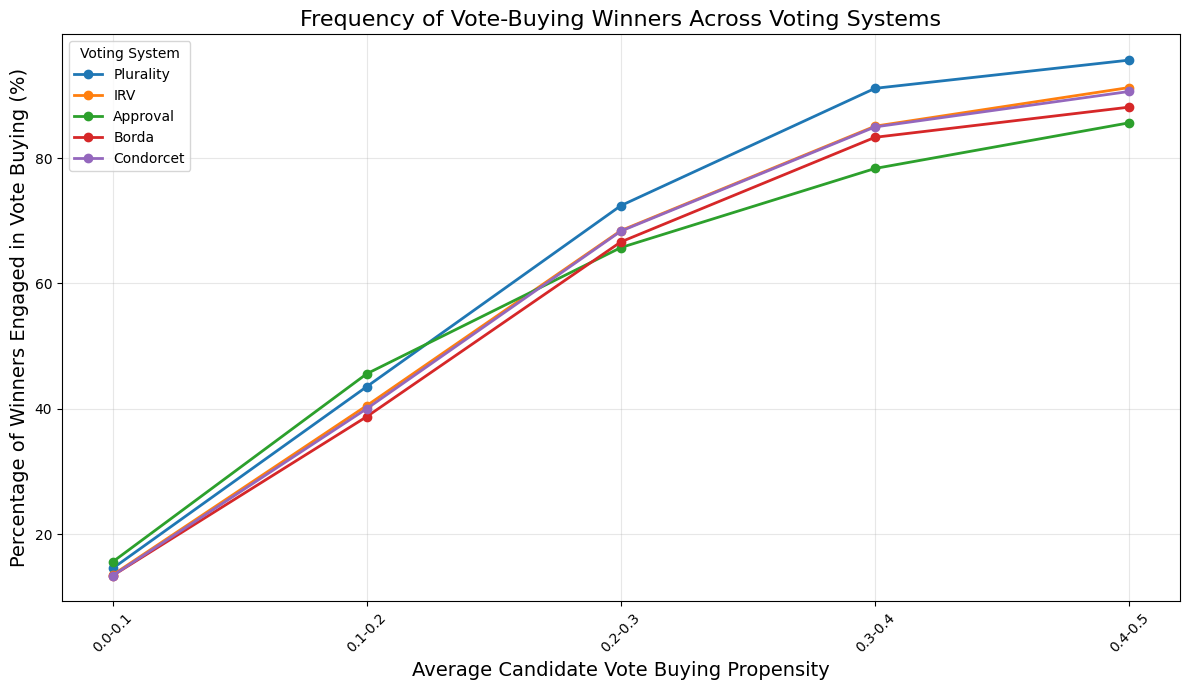

In [23]:
# Group data by vote buying propensity ranges
# Create bins for average candidate propensity
propensity_bins = np.linspace(0, 1, 11)  # 0 to 1 in 10 steps
bin_labels = [f"{round(propensity_bins[i],1)}-{round(propensity_bins[i+1],1)}" for i in range(len(propensity_bins)-1)]

# Group data and calculate the percentage of vote buying winners for each system
sim_df['Propensity_Bin'] = pd.cut(sim_df['Avg Candidate Propensity'], bins=propensity_bins, labels=bin_labels)

# Initialize a DataFrame to store percentages
vb_winners_df = pd.DataFrame(index=bin_labels)

# Calculate percentage of vote buying winners for each system in each bin
voting_systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
for system in voting_systems:
    col_name = f"{system} Winner Vote Buying"
    vb_winners_df[system] = sim_df.groupby('Propensity_Bin')[col_name].mean() * 100

# Create the line plot
plt.figure(figsize=(12, 7))
for system in voting_systems:
    plt.plot(vb_winners_df.index, vb_winners_df[system], marker='o', linewidth=2, label=system)

plt.title('Frequency of Vote-Buying Winners Across Voting Systems', fontsize=16)
plt.xlabel('Average Candidate Vote Buying Propensity', fontsize=14)
plt.ylabel('Percentage of Winners Engaged in Vote Buying (%)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Voting System')
plt.tight_layout()
plt.show()

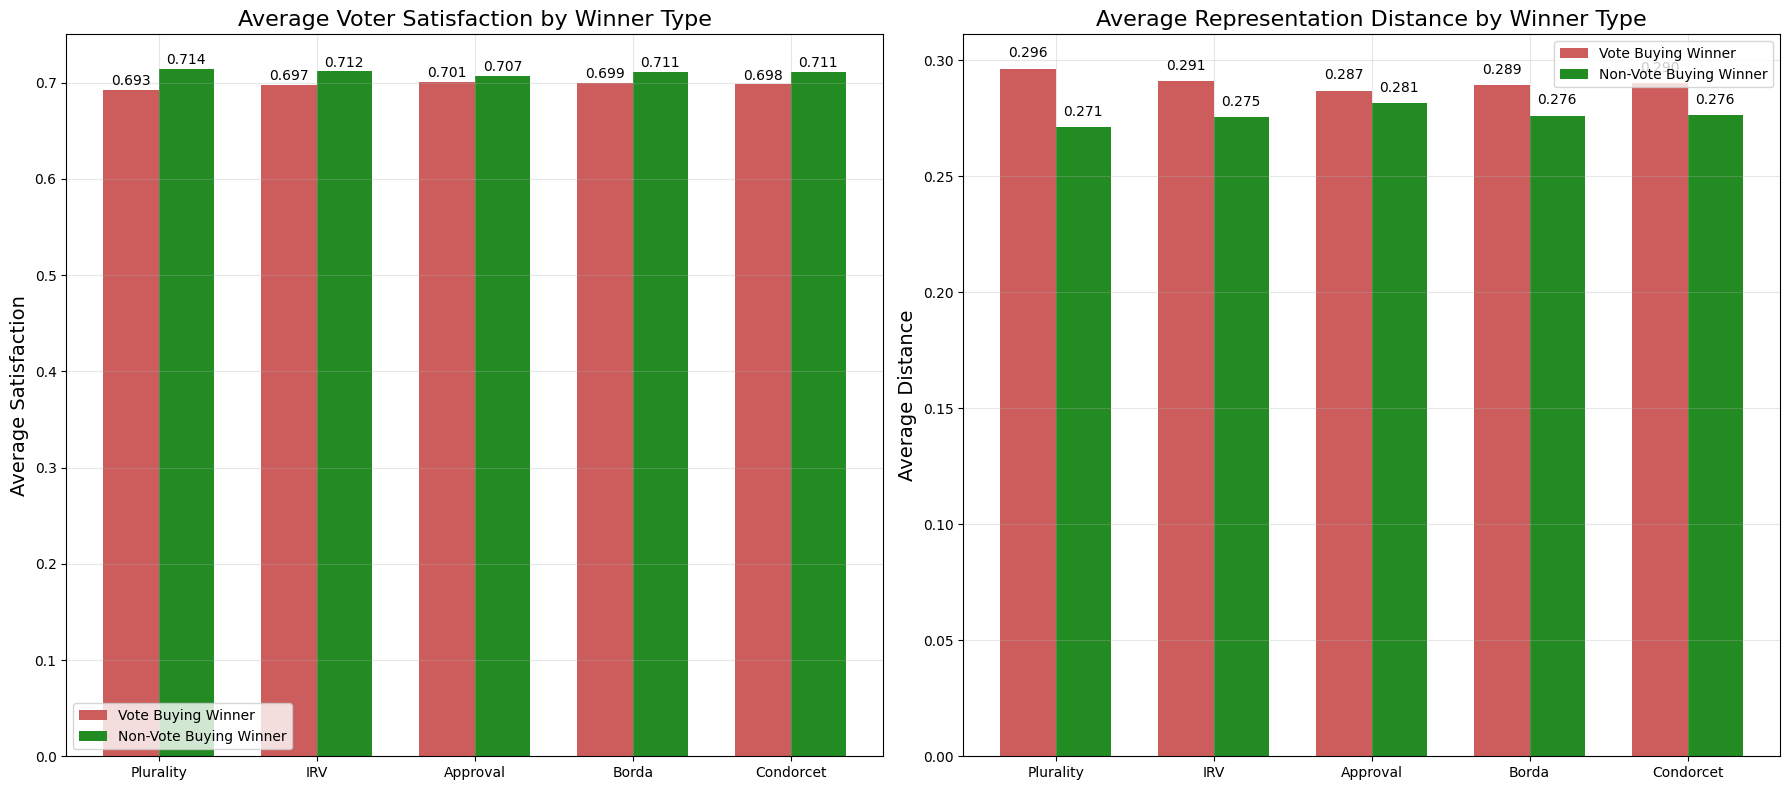

In [126]:
# Filter data for influence level 1.0 only
influence_1_df = sim_df[sim_df['influence'] == 2.0]

# Calculate metrics for each voting system
results = []
for system in voting_systems:
    vb_data = influence_1_df[influence_1_df[f'{system} Winner Vote Buying'] == True]
    non_vb_data = influence_1_df[influence_1_df[f'{system} Winner Vote Buying'] == False]
    
    # Calculate average satisfaction and distance
    results.append({
        'System': system,
        'Satisfaction (VB)': vb_data[f'{system} Satisfaction'].mean(),
        'Satisfaction (Non-VB)': non_vb_data[f'{system} Satisfaction'].mean(),
        'Distance (VB)': vb_data[f'{system} Distance'].mean(),
        'Distance (Non-VB)': non_vb_data[f'{system} Distance'].mean(),
    })

results_df = pd.DataFrame(results)

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Bar width
bar_width = 0.35
index = np.arange(len(voting_systems))

# Plot satisfaction data
satisfaction_vb = ax1.bar(index - bar_width/2, results_df['Satisfaction (VB)'], bar_width, 
                         label='Vote Buying Winner', color='indianred')
satisfaction_non_vb = ax1.bar(index + bar_width/2, results_df['Satisfaction (Non-VB)'], bar_width, 
                             label='Non-Vote Buying Winner', color='forestgreen')

# Add value labels
for i, v in enumerate(results_df['Satisfaction (VB)']):
    ax1.text(i - bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(results_df['Satisfaction (Non-VB)']):
    ax1.text(i + bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

ax1.set_title('Average Voter Satisfaction by Winner Type', fontsize=16)
ax1.set_ylabel('Average Satisfaction', fontsize=14)
ax1.set_xticks(index)
ax1.set_xticklabels(voting_systems)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot distance data
distance_vb = ax2.bar(index - bar_width/2, results_df['Distance (VB)'], bar_width, 
                     label='Vote Buying Winner', color='indianred')
distance_non_vb = ax2.bar(index + bar_width/2, results_df['Distance (Non-VB)'], bar_width, 
                         label='Non-Vote Buying Winner', color='forestgreen')

# Add value labels
for i, v in enumerate(results_df['Distance (VB)']):
    ax2.text(i - bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(results_df['Distance (Non-VB)']):
    ax2.text(i + bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

ax2.set_title('Average Representation Distance by Winner Type', fontsize=16)
ax2.set_ylabel('Average Distance', fontsize=14)
ax2.set_xticks(index)
ax2.set_xticklabels(voting_systems)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

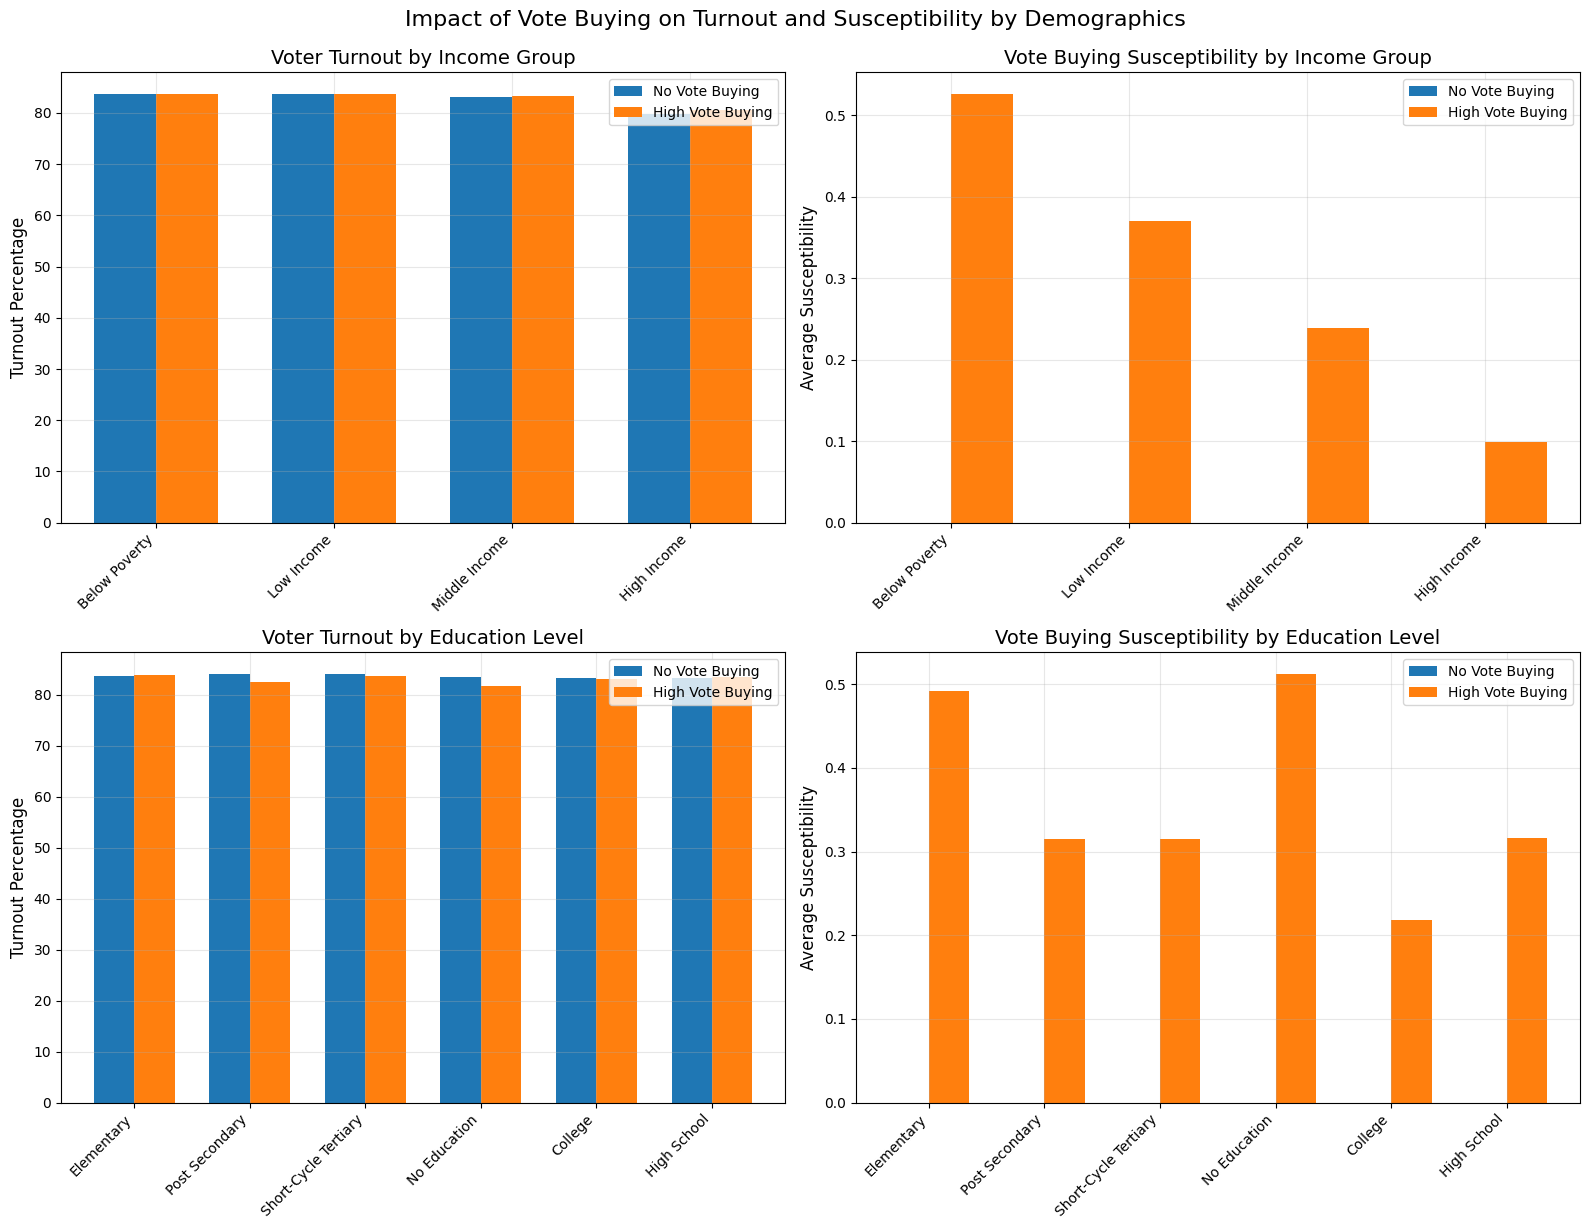

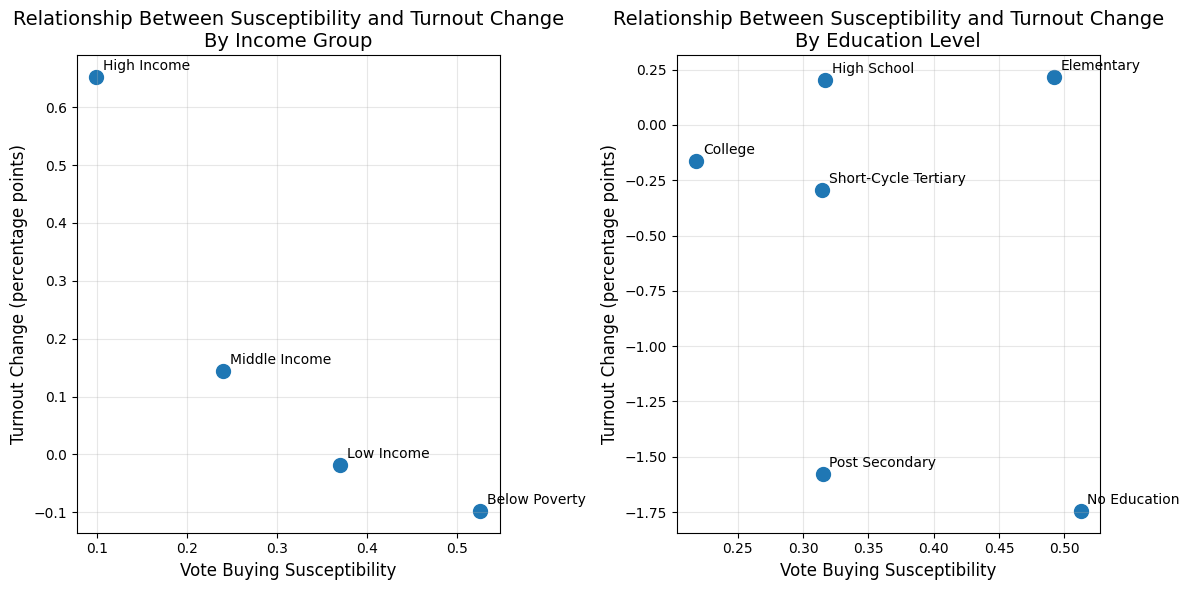

In [25]:
# Import required libraries if not already imported
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Extract data from dictionaries for income and education
# First, let's filter the data to include only influence=0 (no vote buying) and influence=2.0 (high vote buying)
no_vb_df = sim_df[sim_df['influence'] == 0.0].drop_duplicates(['RunId', 'iteration']).reset_index(drop=True)
high_vb_df = sim_df[sim_df['influence'] == 2.0].drop_duplicates(['RunId', 'iteration']).reset_index(drop=True)

# Parse turnout by income dictionaries
income_groups = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
turnout_by_income_no_vb = {}
turnout_by_income_high_vb = {}
suscept_by_income_no_vb = {}
suscept_by_income_high_vb = {}

# Process income data
for group in income_groups:
    # Extract turnout data from dictionaries
    turnout_by_income_no_vb[group] = [eval(row.replace('np.float64', 'float'))[group] 
                                     for row in no_vb_df['Turnout by Income'].iloc[:100]]  # Sample 100 runs
    turnout_by_income_high_vb[group] = [eval(row.replace('np.float64', 'float'))[group] 
                                       for row in high_vb_df['Turnout by Income'].iloc[:100]]
    
    # Extract susceptibility data from dictionaries
    suscept_by_income_no_vb[group] = [eval(row.replace('np.float64', 'float'))[group] 
                                     for row in no_vb_df['Avg Susceptibility by Income'].iloc[:100]]
    suscept_by_income_high_vb[group] = [eval(row.replace('np.float64', 'float'))[group] 
                                       for row in high_vb_df['Avg Susceptibility by Income'].iloc[:100]]

# Process education data
# Extract education groups dynamically from the data
# Make sure we only use education groups that exist across all rows
turnout_by_edu_no_vb = {}
turnout_by_edu_high_vb = {}
suscept_by_edu_no_vb = {}
suscept_by_edu_high_vb = {}

# Find the common education groups that exist in all rows we'll process
sample_size = min(100, len(no_vb_df), len(high_vb_df))
common_edu_keys = None

for i in range(sample_size):
    # Get education keys from all data sources
    no_vb_turnout_keys = set(eval(no_vb_df['Turnout by Education'].iloc[i].replace('np.float64', 'float')).keys())
    no_vb_suscept_keys = set(eval(no_vb_df['Avg Susceptibility by Education'].iloc[i].replace('np.float64', 'float')).keys())
    high_vb_turnout_keys = set(eval(high_vb_df['Turnout by Education'].iloc[i].replace('np.float64', 'float')).keys())
    high_vb_suscept_keys = set(eval(high_vb_df['Avg Susceptibility by Education'].iloc[i].replace('np.float64', 'float')).keys())
    
    # Find intersection of all keys
    row_keys = no_vb_turnout_keys & no_vb_suscept_keys & high_vb_turnout_keys & high_vb_suscept_keys
    
    if common_edu_keys is None:
        common_edu_keys = row_keys
    else:
        common_edu_keys &= row_keys  # Keep only keys that appear in all rows

edu_groups = list(common_edu_keys)

# Now process using only the common education groups
for group in edu_groups:
    turnout_by_edu_no_vb[group] = []
    turnout_by_edu_high_vb[group] = []
    suscept_by_edu_no_vb[group] = []
    suscept_by_edu_high_vb[group] = []
    
    for i in range(sample_size):
        no_vb_turnout = eval(no_vb_df['Turnout by Education'].iloc[i].replace('np.float64', 'float'))
        high_vb_turnout = eval(high_vb_df['Turnout by Education'].iloc[i].replace('np.float64', 'float'))
        no_vb_suscept = eval(no_vb_df['Avg Susceptibility by Education'].iloc[i].replace('np.float64', 'float'))
        high_vb_suscept = eval(high_vb_df['Avg Susceptibility by Education'].iloc[i].replace('np.float64', 'float'))
        
        turnout_by_edu_no_vb[group].append(no_vb_turnout[group])
        turnout_by_edu_high_vb[group].append(high_vb_turnout[group])
        suscept_by_edu_no_vb[group].append(no_vb_suscept[group])
        suscept_by_edu_high_vb[group].append(high_vb_suscept[group])

# Calculate averages
turnout_income_avg_no_vb = {k: np.mean(v) for k, v in turnout_by_income_no_vb.items()}
turnout_income_avg_high_vb = {k: np.mean(v) for k, v in turnout_by_income_high_vb.items()}
suscept_income_avg_no_vb = {k: np.mean(v) for k, v in suscept_by_income_no_vb.items()}
suscept_income_avg_high_vb = {k: np.mean(v) for k, v in suscept_by_income_high_vb.items()}

turnout_edu_avg_no_vb = {k: np.mean(v) for k, v in turnout_by_edu_no_vb.items()}
turnout_edu_avg_high_vb = {k: np.mean(v) for k, v in turnout_by_edu_high_vb.items()}
suscept_edu_avg_no_vb = {k: np.mean(v) for k, v in suscept_by_edu_no_vb.items()}
suscept_edu_avg_high_vb = {k: np.mean(v) for k, v in suscept_by_edu_high_vb.items()}

# Pretty labels for display
income_labels = ['Below Poverty', 'Low Income', 'Middle Income', 'High Income']
# Adjust education labels based on the actual groups in the data
if len(edu_groups) == 7:
    edu_labels = ['None', 'Early Childhood', 'Primary', 'Lower Secondary', 'Upper Secondary', 'Post-Secondary', 'College']
else:
    # Create generic labels if the number of education groups is different
    edu_labels = [group.replace('_', ' ').title() for group in edu_groups]

# Plot 1: Turnout by Income
x = np.arange(len(income_groups))
width = 0.35
axs[0, 0].bar(x - width/2, [turnout_income_avg_no_vb[g] for g in income_groups], width, label='No Vote Buying')
axs[0, 0].bar(x + width/2, [turnout_income_avg_high_vb[g] for g in income_groups], width, label='High Vote Buying')
axs[0, 0].set_title('Voter Turnout by Income Group', fontsize=14)
axs[0, 0].set_ylabel('Turnout Percentage', fontsize=12)
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(income_labels, rotation=45, ha='right')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# Plot 2: Susceptibility by Income
axs[0, 1].bar(x - width/2, [suscept_income_avg_no_vb[g] for g in income_groups], width, label='No Vote Buying')
axs[0, 1].bar(x + width/2, [suscept_income_avg_high_vb[g] for g in income_groups], width, label='High Vote Buying')
axs[0, 1].set_title('Vote Buying Susceptibility by Income Group', fontsize=14)
axs[0, 1].set_ylabel('Average Susceptibility', fontsize=12)
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(income_labels, rotation=45, ha='right')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

# Plot 3: Turnout by Education
x = np.arange(len(edu_groups))
axs[1, 0].bar(x - width/2, [turnout_edu_avg_no_vb[g] for g in edu_groups], width, label='No Vote Buying')
axs[1, 0].bar(x + width/2, [turnout_edu_avg_high_vb[g] for g in edu_groups], width, label='High Vote Buying')
axs[1, 0].set_title('Voter Turnout by Education Level', fontsize=14)
axs[1, 0].set_ylabel('Turnout Percentage', fontsize=12)
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(edu_labels, rotation=45, ha='right')
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# Plot 4: Susceptibility by Education
axs[1, 1].bar(x - width/2, [suscept_edu_avg_no_vb[g] for g in edu_groups], width, label='No Vote Buying')
axs[1, 1].bar(x + width/2, [suscept_edu_avg_high_vb[g] for g in edu_groups], width, label='High Vote Buying')
axs[1, 1].set_title('Vote Buying Susceptibility by Education Level', fontsize=14)
axs[1, 1].set_ylabel('Average Susceptibility', fontsize=12)
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(edu_labels, rotation=45, ha='right')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Impact of Vote Buying on Turnout and Susceptibility by Demographics', fontsize=16, y=1.02)
plt.show()

# Let's also analyze correlation between susceptibility and turnout change
# Calculate turnout change with vs without vote buying
turnout_income_change = {k: turnout_income_avg_high_vb[k] - turnout_income_avg_no_vb[k] for k in income_groups}
suscept_income = {k: suscept_income_avg_high_vb[k] for k in income_groups}

turnout_edu_change = {k: turnout_edu_avg_high_vb[k] - turnout_edu_avg_no_vb[k] for k in edu_groups}
suscept_edu = {k: suscept_edu_avg_high_vb[k] for k in edu_groups}

# Plot the relationship between susceptibility and turnout change
plt.figure(figsize=(12, 6))

# Income groups
plt.subplot(1, 2, 1)
plt.scatter([suscept_income[k] for k in income_groups], [turnout_income_change[k] for k in income_groups], s=100)
for i, txt in enumerate(income_labels):
    plt.annotate(txt, (list(suscept_income.values())[i], list(turnout_income_change.values())[i]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel('Vote Buying Susceptibility', fontsize=12)
plt.ylabel('Turnout Change (percentage points)', fontsize=12)
plt.title('Relationship Between Susceptibility and Turnout Change\nBy Income Group', fontsize=14)
plt.grid(alpha=0.3)

# Education groups
plt.subplot(1, 2, 2)
plt.scatter([suscept_edu[k] for k in edu_groups], [turnout_edu_change[k] for k in edu_groups], s=100)
for i, txt in enumerate(edu_labels):
    plt.annotate(txt, (list(suscept_edu.values())[i], list(turnout_edu_change.values())[i]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel('Vote Buying Susceptibility', fontsize=12)
plt.ylabel('Turnout Change (percentage points)', fontsize=12)
plt.title('Relationship Between Susceptibility and Turnout Change\nBy Education Level', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2582275405.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_by_propensity[system] = sim_df.groupby('Propensity_Bin_Detailed')[f'{system} Satisfaction'].mean()
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2582275405.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_by_propensity[system] = sim_df.groupby('Propensity_Bin_Detailed')[f'{system} Satisfaction'].mean()
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2582275405.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futu

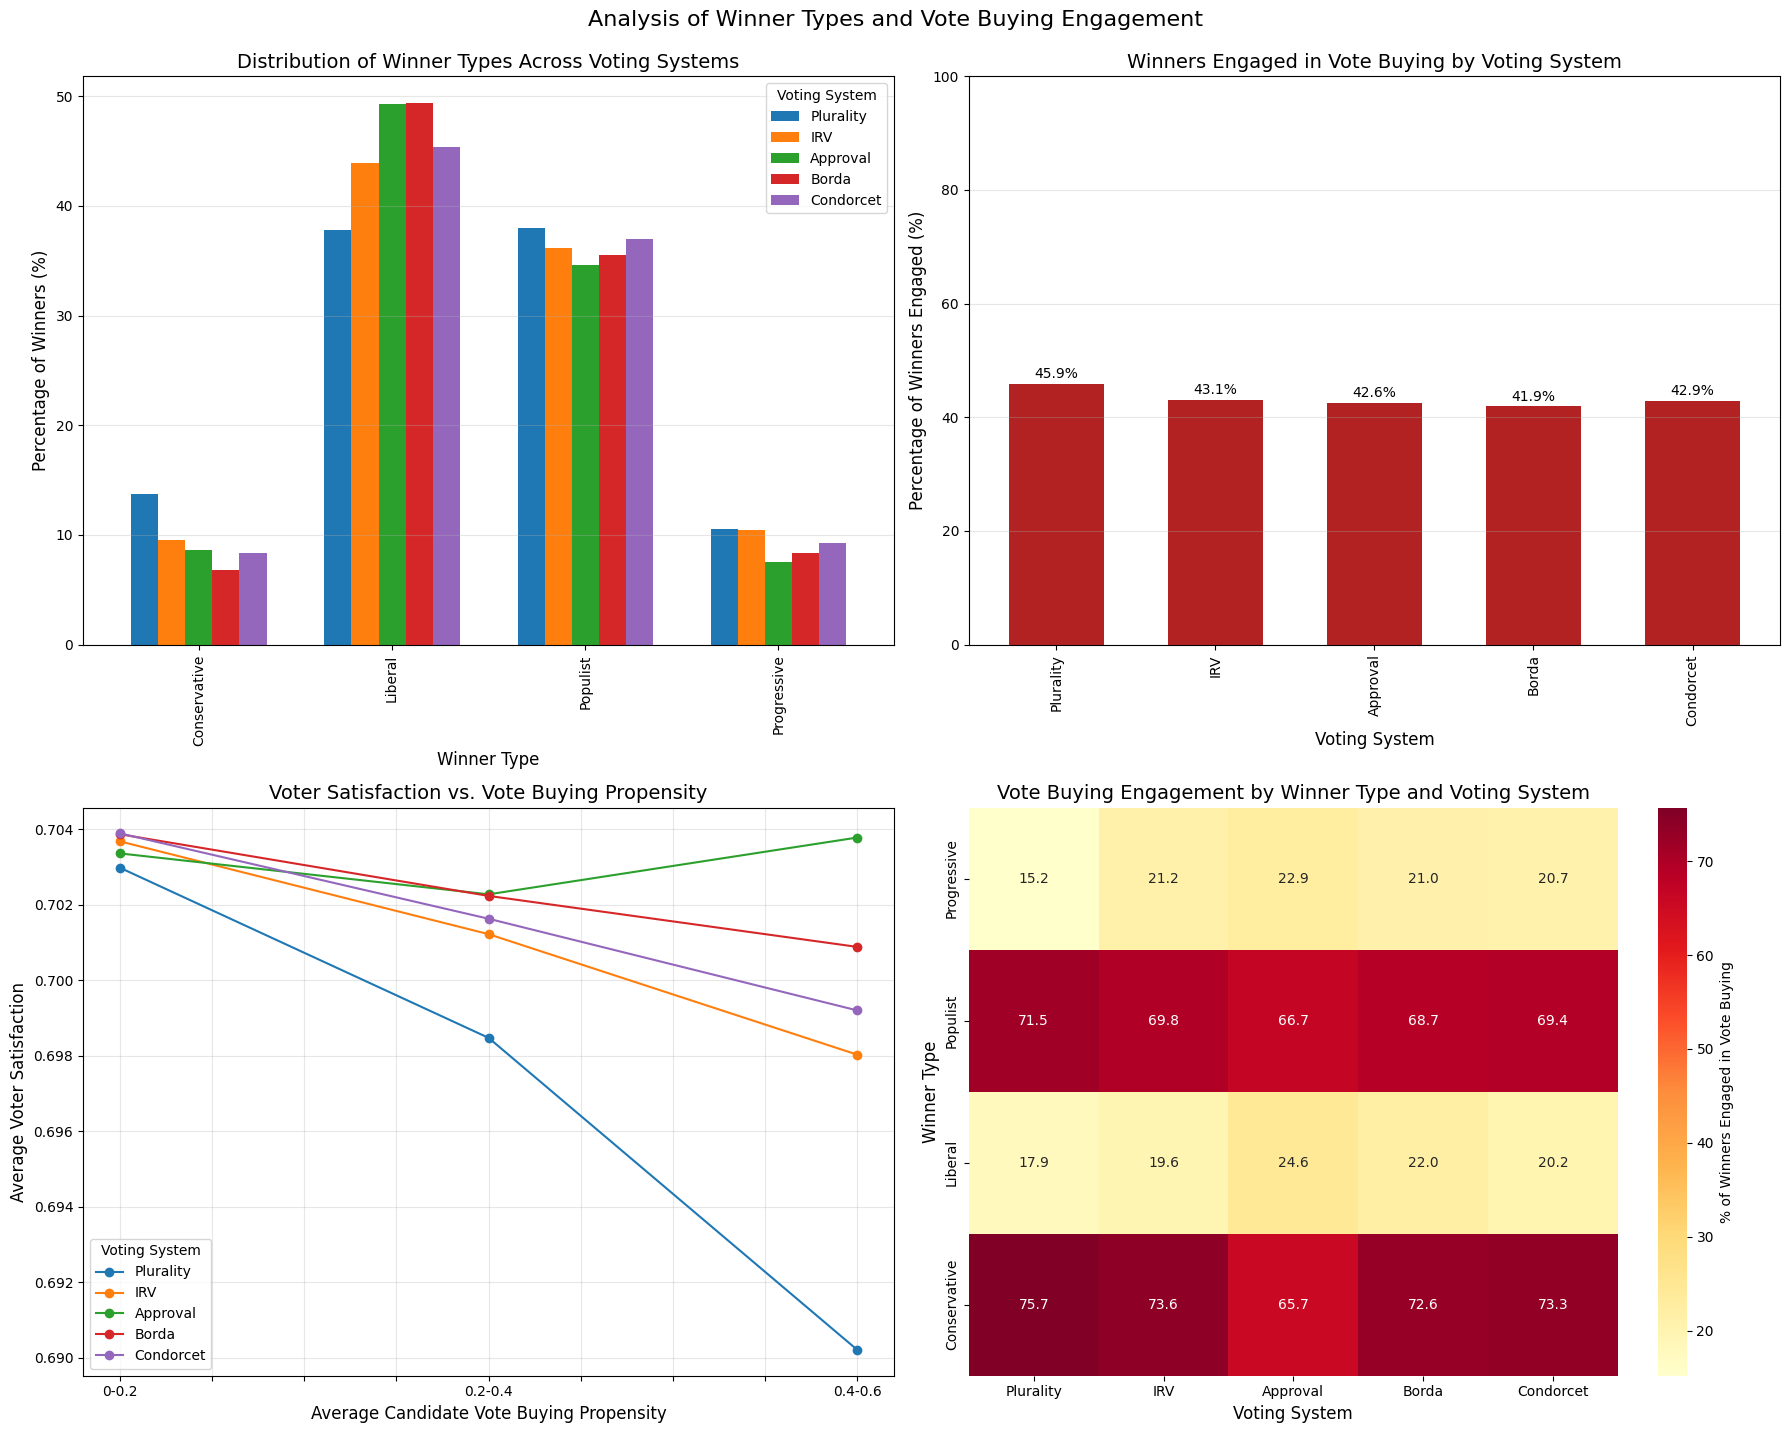

<Figure size 1000x600 with 0 Axes>

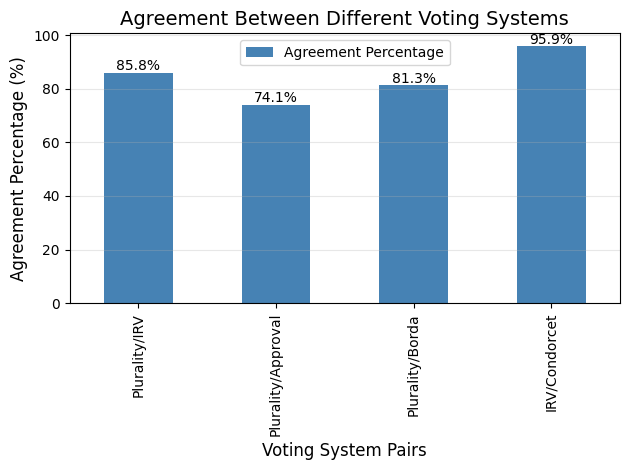

In [26]:
# Create a comprehensive visualization to analyze winner types and vote-buying engagement

# Set up figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# 1. Distribution of winner types across voting systems
winner_type_counts = {}
for system in voting_systems:
    col_name = f'{system} Winner Type'
    winner_type_counts[system] = sim_df[col_name].value_counts(normalize=True) * 100

winner_types_df = pd.DataFrame(winner_type_counts)

# Plot stacked bar chart for winner types
winner_types_df.plot(kind='bar', stacked=False, ax=axs[0, 0], width=0.7)
axs[0, 0].set_title('Distribution of Winner Types Across Voting Systems', fontsize=14)
axs[0, 0].set_ylabel('Percentage of Winners (%)', fontsize=12)
axs[0, 0].set_xlabel('Winner Type', fontsize=12)
axs[0, 0].grid(axis='y', alpha=0.3)
axs[0, 0].legend(title='Voting System')

# 2. Vote buying engagement among winners across voting systems
vb_engagement = pd.DataFrame()
for system in voting_systems:
    vb_col = f'{system} Winner Vote Buying'
    vb_engagement[system] = sim_df[vb_col].value_counts(normalize=True) * 100

# Plot vote buying engagement
vb_engagement.loc[True].plot(kind='bar', ax=axs[0, 1], color='firebrick', width=0.6)
axs[0, 1].set_title('Winners Engaged in Vote Buying by Voting System', fontsize=14)
axs[0, 1].set_ylabel('Percentage of Winners Engaged (%)', fontsize=12)
axs[0, 1].set_xlabel('Voting System', fontsize=12)
axs[0, 1].grid(axis='y', alpha=0.3)
axs[0, 1].set_ylim(0, 100)

# Add values on top of bars
for i, v in enumerate(vb_engagement.loc[True]):
    axs[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# 3. Relationship between vote buying propensity and satisfaction
# Create bins for vote buying propensity
propensity_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bin_labels = [f"{i}-{j}" for i, j in zip(propensity_bins[:-1], propensity_bins[1:])]

sim_df['Propensity_Bin_Detailed'] = pd.cut(sim_df['Avg Candidate Propensity'], 
                                          bins=propensity_bins, 
                                          labels=bin_labels, 
                                          include_lowest=True)

# Calculate average satisfaction for each voting system by propensity bin
satisfaction_by_propensity = pd.DataFrame()
for system in voting_systems:
    satisfaction_by_propensity[system] = sim_df.groupby('Propensity_Bin_Detailed')[f'{system} Satisfaction'].mean()

satisfaction_by_propensity.plot(marker='o', ax=axs[1, 0])
axs[1, 0].set_title('Voter Satisfaction vs. Vote Buying Propensity', fontsize=14)
axs[1, 0].set_ylabel('Average Voter Satisfaction', fontsize=12)
axs[1, 0].set_xlabel('Average Candidate Vote Buying Propensity', fontsize=12)
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend(title='Voting System')

# 4. Vote buying winners by winner type
# We'll create a heatmap showing % of vote buying winners for each winner type and voting system
vote_buying_by_type = {}

# First, get all unique winner types
all_winner_types = set()
for system in voting_systems:
    all_winner_types.update(sim_df[f'{system} Winner Type'].unique())

# Calculate percentage of vote buying winners for each type and system
for system in voting_systems:
    vote_buying_by_type[system] = {}
    for winner_type in all_winner_types:
        type_subset = sim_df[sim_df[f'{system} Winner Type'] == winner_type]
        if len(type_subset) > 0:
            vb_percentage = (type_subset[f'{system} Winner Vote Buying'].mean() * 100)
            vote_buying_by_type[system][winner_type] = vb_percentage
        else:
            vote_buying_by_type[system][winner_type] = 0

# Convert to DataFrame for heatmap
vb_by_type_df = pd.DataFrame(vote_buying_by_type)

# Create heatmap
sns.heatmap(vb_by_type_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=axs[1, 1], cbar_kws={'label': '% of Winners Engaged in Vote Buying'})
axs[1, 1].set_title('Vote Buying Engagement by Winner Type and Voting System', fontsize=14)
axs[1, 1].set_ylabel('Winner Type', fontsize=12)
axs[1, 1].set_xlabel('Voting System', fontsize=12)

plt.tight_layout()
plt.suptitle('Analysis of Winner Types and Vote Buying Engagement', fontsize=16, y=1.02)
plt.show()

# Additional analysis: Agreement between voting systems and vote buying outcomes
agreement_df = pd.DataFrame({
    'Plurality/IRV': sim_df['Winner Agreement (Plurality/IRV)'].mean() * 100,
    'Plurality/Approval': sim_df['Winner Agreement (Plurality/Approval)'].mean() * 100,
    'Plurality/Borda': sim_df['Winner Agreement (Plurality/Borda)'].mean() * 100,
    'IRV/Condorcet': sim_df['Winner Agreement (IRV/Condorcet)'].mean() * 100
}, index=['Agreement Percentage'])

# Plot the agreement percentages
plt.figure(figsize=(10, 6))
agreement_df.T.plot(kind='bar', color='steelblue')
plt.title('Agreement Between Different Voting Systems', fontsize=14)
plt.ylabel('Agreement Percentage (%)', fontsize=12)
plt.xlabel('Voting System Pairs', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for i, v in enumerate(agreement_df.loc['Agreement Percentage']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()

plt.show()

KeyboardInterrupt: 

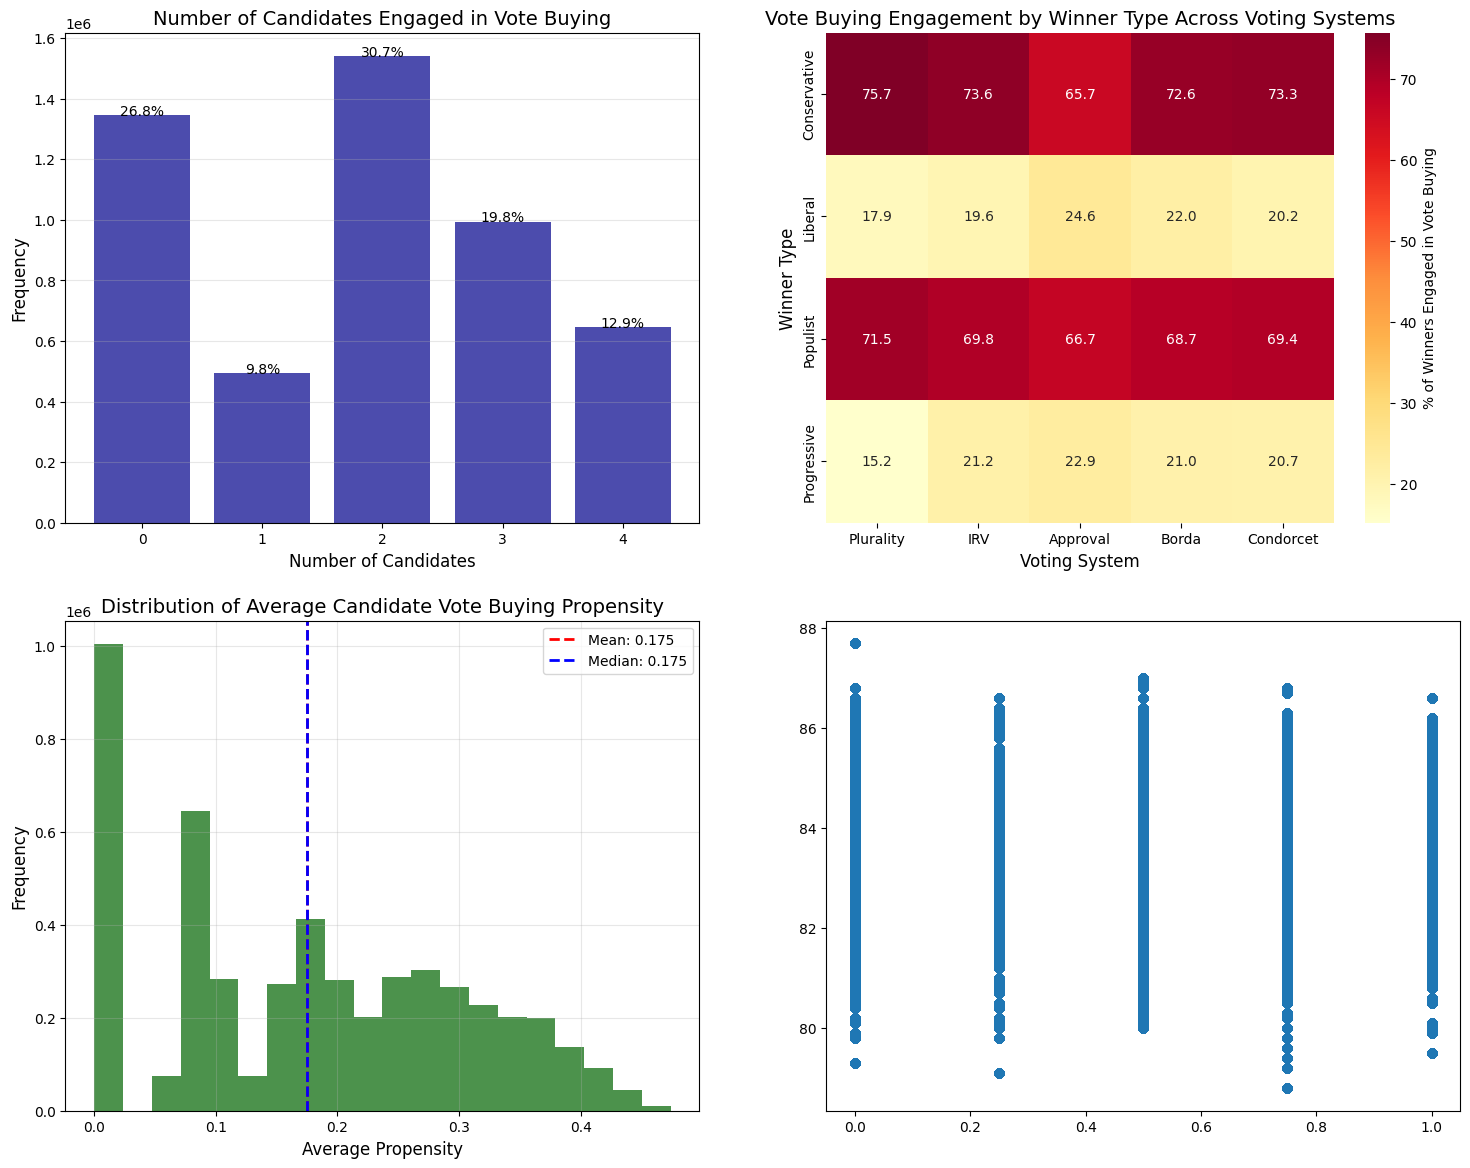

In [29]:
# Create visualizations for winner types and vote buying engagement patterns

# Set up the matplotlib figure
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# 1. Distribution of total candidates engaged in vote buying
engagement_counts = sim_df['Total Candidates Engaged in Vote Buying'].value_counts().sort_index()
axs[0, 0].bar(engagement_counts.index, engagement_counts.values, color='darkblue', alpha=0.7)
axs[0, 0].set_title('Number of Candidates Engaged in Vote Buying', fontsize=14)
axs[0, 0].set_xlabel('Number of Candidates', fontsize=12)
axs[0, 0].set_ylabel('Frequency', fontsize=12)
axs[0, 0].set_xticks(range(max(engagement_counts.index)+1))
axs[0, 0].grid(axis='y', alpha=0.3)

# Add percentage labels
total = engagement_counts.sum()
for i, count in enumerate(engagement_counts):
    percentage = (count / total) * 100
    axs[0, 0].text(engagement_counts.index[i], count + 10, f"{percentage:.1f}%", 
                  ha='center', fontsize=10)

# 2. Compare winner types and vote buying engagement for each voting system
winner_vb_data = []
for system in voting_systems:
    type_vb = pd.crosstab(sim_df[f'{system} Winner Type'], 
                          sim_df[f'{system} Winner Vote Buying'],
                          normalize='index') * 100
    if True in type_vb.columns:
        winner_vb_data.append(type_vb[True])

winner_vb_df = pd.DataFrame(winner_vb_data, index=voting_systems)

# Plot as heatmap
sns.heatmap(winner_vb_df.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=axs[0, 1],
           cbar_kws={'label': '% of Winners Engaged in Vote Buying'})
axs[0, 1].set_title('Vote Buying Engagement by Winner Type Across Voting Systems', fontsize=14)
axs[0, 1].set_ylabel('Winner Type', fontsize=12)
axs[0, 1].set_xlabel('Voting System', fontsize=12)

# 3. Vote buying propensity distribution
axs[1, 0].hist(sim_df['Avg Candidate Propensity'], bins=20, color='darkgreen', alpha=0.7)
axs[1, 0].set_title('Distribution of Average Candidate Vote Buying Propensity', fontsize=14)
axs[1, 0].set_xlabel('Average Propensity', fontsize=12)
axs[1, 0].set_ylabel('Frequency', fontsize=12)
axs[1, 0].grid(alpha=0.3)

# Calculate mean and median
mean_prop = sim_df['Avg Candidate Propensity'].mean()
median_prop = sim_df['Avg Candidate Propensity'].median()
axs[1, 0].axvline(mean_prop, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_prop:.3f}')
axs[1, 0].axvline(median_prop, color='blue', linestyle='dashed', linewidth=2, label=f'Median: {median_prop:.3f}')
axs[1, 0].legend()

# 4. Relationship between vote buying engagement rate and turnout
# Create scatter plot with linear regression line
sns.regplot(x='Vote Buying Engagement Rate', y='Turnout Percentage', 
           data=sim_df, scatter_kws={'alpha':0.3}, ax=axs[1, 1])
axs[1, 1].set_title('Impact of Vote Buying Engagement on Voter Turnout', fontsize=14)
axs[1, 1].set_xlabel('Vote Buying Engagement Rate', fontsize=12)
axs[1, 1].set_ylabel('Turnout Percentage', fontsize=12)
axs[1, 1].grid(alpha=0.3)

# Calculate correlation coefficient
corr = sim_df['Vote Buying Engagement Rate'].corr(sim_df['Turnout Percentage'])
axs[1, 1].text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=axs[1, 1].transAxes, 
              fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.suptitle('Analysis of Vote Buying Patterns and Electoral Outcomes', fontsize=18, y=1.02)
plt.show()

# Additional analysis: Compare voter satisfaction across different vote buying engagement levels
#plt.figure(figsize=(14, 8))
#
## Create vote buying engagement rate bins
#sim_df['Engagement_Bin'] = pd.cut(sim_df['Vote Buying Engagement Rate'], 
#                                 bins=[0, 0.25, 0.5, 0.75, 1.0],
#                                 labels=['0-25%', '26-50%', '51-75%', '76-100%'])
#
## Calculate mean satisfaction for each voting system by engagement bin
#satisfaction_data = []
#for system in voting_systems:
#    satisfaction_data.append(sim_df.groupby('Engagement_Bin')[f'{system} Satisfaction'].mean())
#
#satisfaction_df = pd.DataFrame(satisfaction_data, index=voting_systems).T
#
# Plot the grouped bar chart
#ax = satisfaction_df.plot(kind='bar', figsize=(14, 8), width=0.8)
#plt.title('Average Voter Satisfaction by Vote Buying Engagement Level', fontsize=16)
#plt.xlabel('Vote Buying Engagement Rate', fontsize=14)
#plt.ylabel('Average Voter Satisfaction', fontsize=14)
#plt.grid(axis='y', alpha=0.3)
#plt.legend(title='Voting System')
#
## Add value labels on bars
#for container in ax.containers:
#    ax.bar_label(container, fmt='%.3f', fontsize=9)
#
#plt.tight_layout()
plt.show()

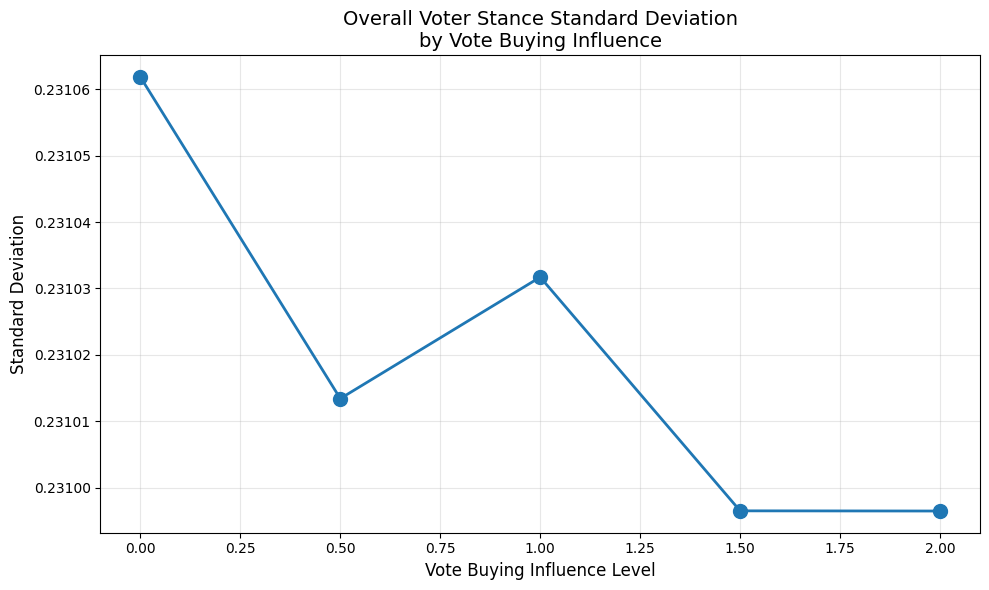

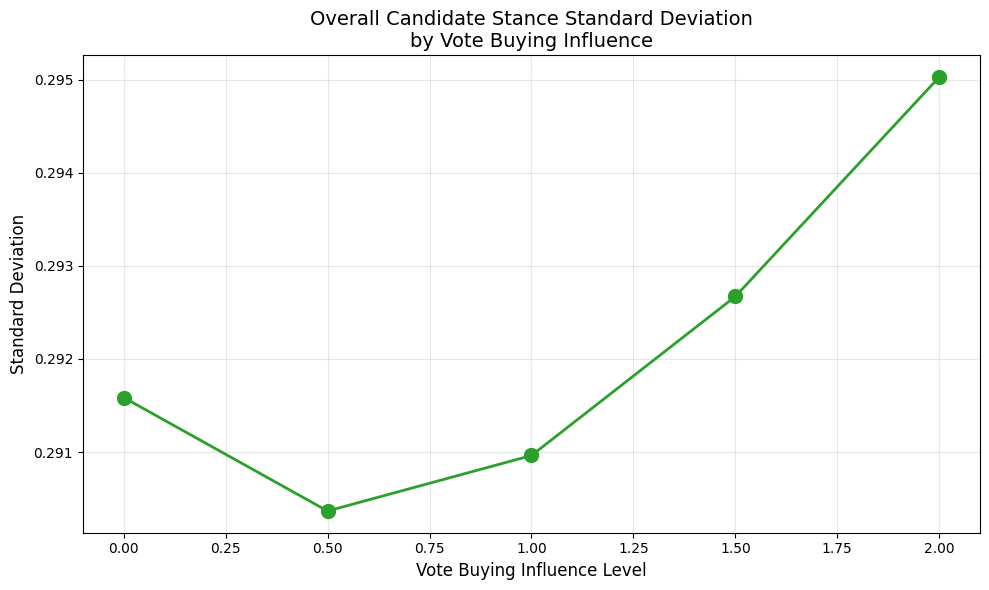

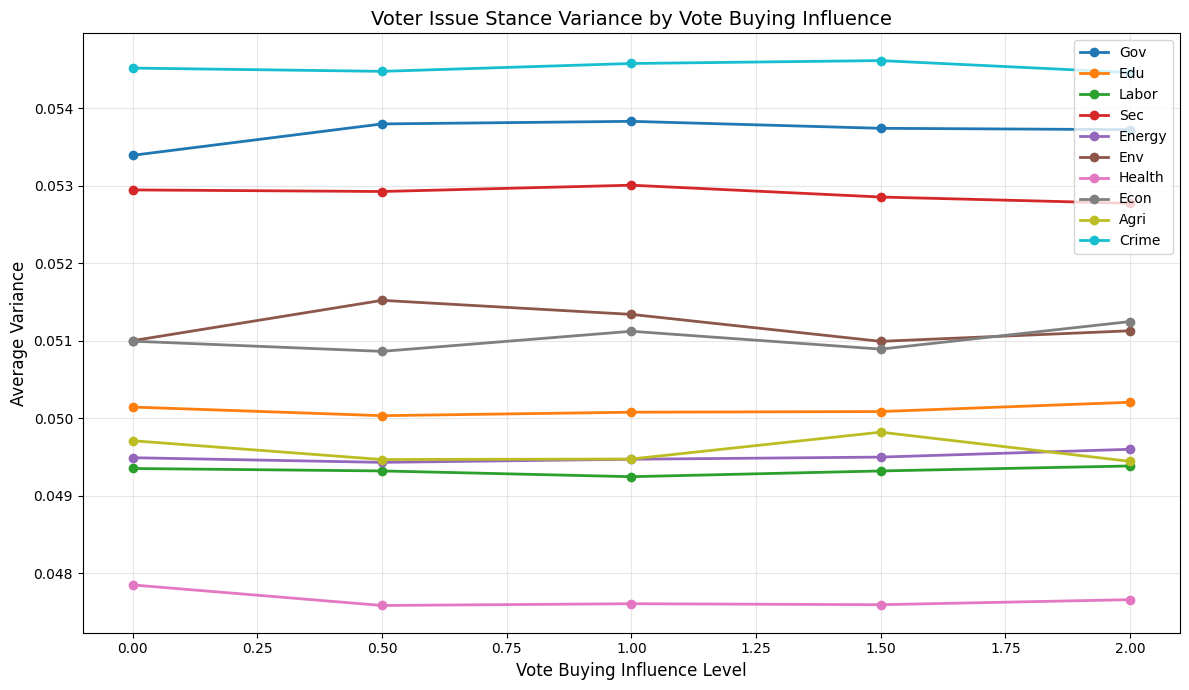

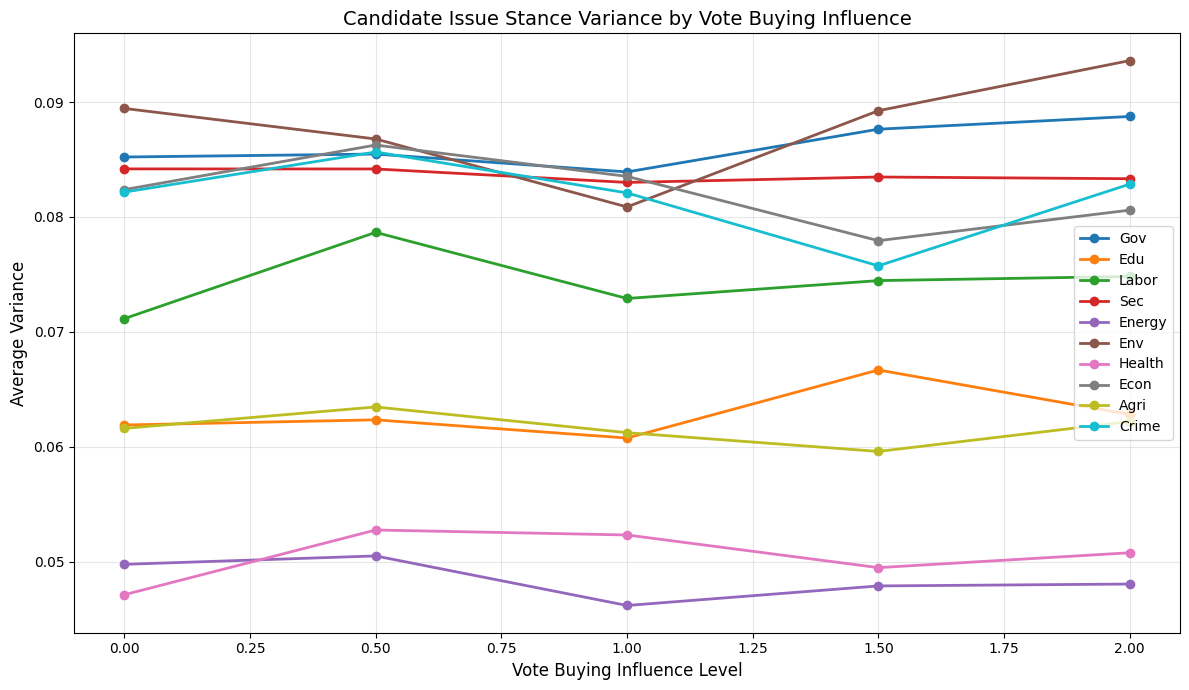

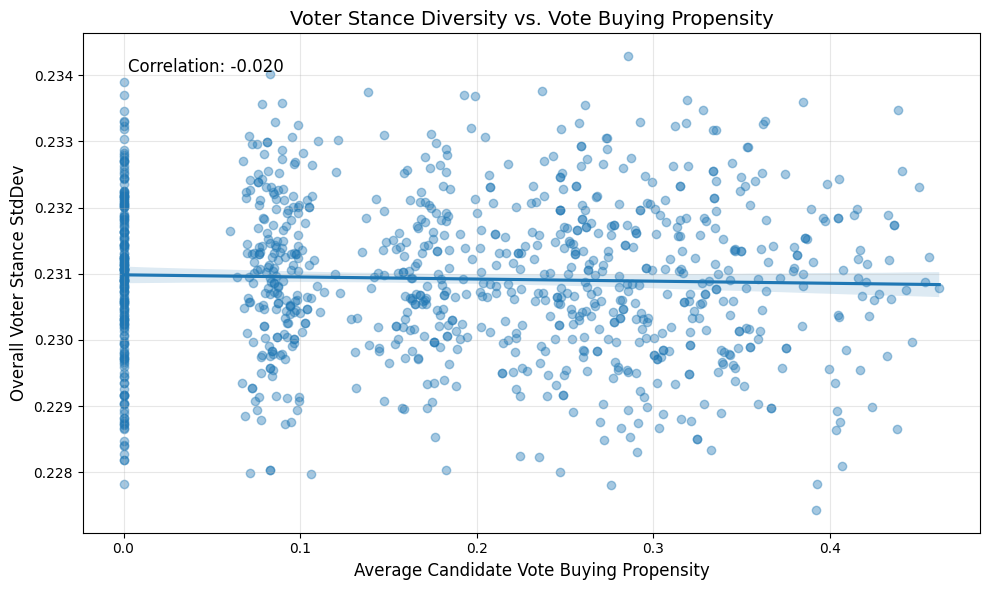

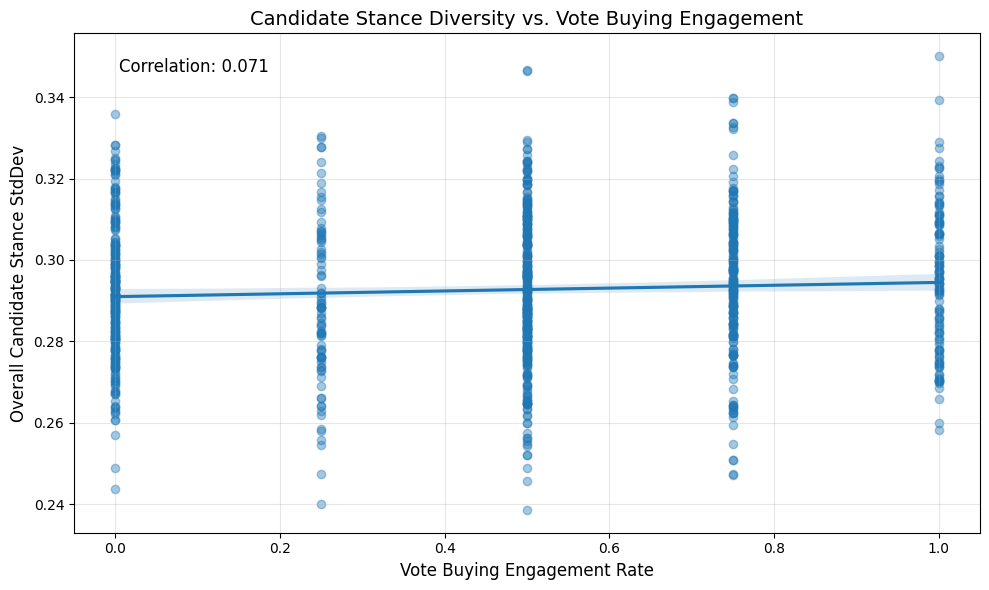

In [127]:
# Visualize how stance variance and standard deviation change with vote buying prevalence

# Process data as before
influence_levels = sorted(sim_df['influence'].unique())
variance_data = []

# Process data for each influence level
for influence in influence_levels:
    filtered_df = sim_df[sim_df['influence'] == influence].drop_duplicates(['RunId', 'iteration'])
    
    # Calculate average standard deviations
    avg_voter_std = filtered_df['Overall Voter Stance StdDev'].mean()
    avg_candidate_std = filtered_df['Overall Candidate Stance StdDev'].mean()
    
    # Parse issue variance dictionaries
    voter_issue_variance = {}
    candidate_issue_variance = {}
    
    # Process sample rows to extract issue variances
    sample_size = min(100, len(filtered_df))
    for i in range(sample_size):
        # Parse voter stance variance
        v_variance = eval(filtered_df['Voter Issue Stance Variance'].iloc[i].replace('np.float64', 'float'))
        for issue, value in v_variance.items():
            if issue not in voter_issue_variance:
                voter_issue_variance[issue] = []
            voter_issue_variance[issue].append(value)
        
        # Parse candidate stance variance
        c_variance = eval(filtered_df['Candidate Issue Stance Variance'].iloc[i].replace('np.float64', 'float'))
        for issue, value in c_variance.items():
            if issue not in candidate_issue_variance:
                candidate_issue_variance[issue] = []
            candidate_issue_variance[issue].append(value)
    
    # Calculate average variance for each issue
    avg_voter_variance = {k: np.mean(v) for k, v in voter_issue_variance.items()}
    avg_candidate_variance = {k: np.mean(v) for k, v in candidate_issue_variance.items()}
    
    variance_data.append({
        'influence': influence,
        'voter_std': avg_voter_std,
        'candidate_std': avg_candidate_std,
        'avg_voter_variance': avg_voter_variance,
        'avg_candidate_variance': avg_candidate_variance
    })

# Convert to DataFrame for easier plotting
variance_df = pd.DataFrame(variance_data)

# Extract issues
issues = list(variance_df.iloc[0]['avg_voter_variance'].keys())

# Create 6 separate plots

# Plot 1: Overall Voter Stance StdDev
plt.figure(figsize=(10, 6))
plt.plot(variance_df['influence'], variance_df['voter_std'], 'o-', linewidth=2, markersize=10, color='#1f77b4')
plt.title('Overall Voter Stance Standard Deviation\nby Vote Buying Influence', fontsize=14)
plt.xlabel('Vote Buying Influence Level', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Overall Candidate Stance StdDev
plt.figure(figsize=(10, 6))
plt.plot(variance_df['influence'], variance_df['candidate_std'], 'o-', linewidth=2, markersize=10, color='#2ca02c')
plt.title('Overall Candidate Stance Standard Deviation\nby Vote Buying Influence', fontsize=14)
plt.xlabel('Vote Buying Influence Level', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Voter Issue Stance Variance
plt.figure(figsize=(12, 7))
for issue in issues:
    issue_variance = [row[issue] for row in variance_df['avg_voter_variance']]
    plt.plot(variance_df['influence'], issue_variance, 'o-', linewidth=2, label=issue.capitalize())
plt.title('Voter Issue Stance Variance by Vote Buying Influence', fontsize=14)
plt.xlabel('Vote Buying Influence Level', fontsize=12)
plt.ylabel('Average Variance', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Candidate Issue Stance Variance
plt.figure(figsize=(12, 7))
for issue in issues:
    issue_variance = [row[issue] for row in variance_df['avg_candidate_variance']]
    plt.plot(variance_df['influence'], issue_variance, 'o-', linewidth=2, label=issue.capitalize())
plt.title('Candidate Issue Stance Variance by Vote Buying Influence', fontsize=14)
plt.xlabel('Vote Buying Influence Level', fontsize=12)
plt.ylabel('Average Variance', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 5: Voter Stance Diversity vs. Vote Buying Propensity
plt.figure(figsize=(10, 6))
sns.regplot(x='Avg Candidate Propensity', y='Overall Voter Stance StdDev', 
           data=sim_df.sample(1000), scatter_kws={'alpha':0.4})
plt.title('Voter Stance Diversity vs. Vote Buying Propensity', fontsize=14)
plt.xlabel('Average Candidate Vote Buying Propensity', fontsize=12)
plt.ylabel('Overall Voter Stance StdDev', fontsize=12)
plt.grid(alpha=0.3)
# Calculate correlation coefficient
corr = sim_df['Avg Candidate Propensity'].corr(sim_df['Overall Voter Stance StdDev'])
plt.text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=plt.gca().transAxes, 
          fontsize=12, verticalalignment='top')
plt.tight_layout()
plt.show()

# Plot 6: Candidate Stance Diversity vs. Vote Buying Engagement
plt.figure(figsize=(10, 6))
sns.regplot(x='Vote Buying Engagement Rate', y='Overall Candidate Stance StdDev', 
           data=sim_df.sample(1000), scatter_kws={'alpha':0.4})
plt.title('Candidate Stance Diversity vs. Vote Buying Engagement', fontsize=14)
plt.xlabel('Vote Buying Engagement Rate', fontsize=12)
plt.ylabel('Overall Candidate Stance StdDev', fontsize=12)
plt.grid(alpha=0.3)
# Calculate correlation coefficient
corr = sim_df['Vote Buying Engagement Rate'].corr(sim_df['Overall Candidate Stance StdDev'])
plt.text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=plt.gca().transAxes, 
          fontsize=12, verticalalignment='top')
plt.tight_layout()
plt.show()

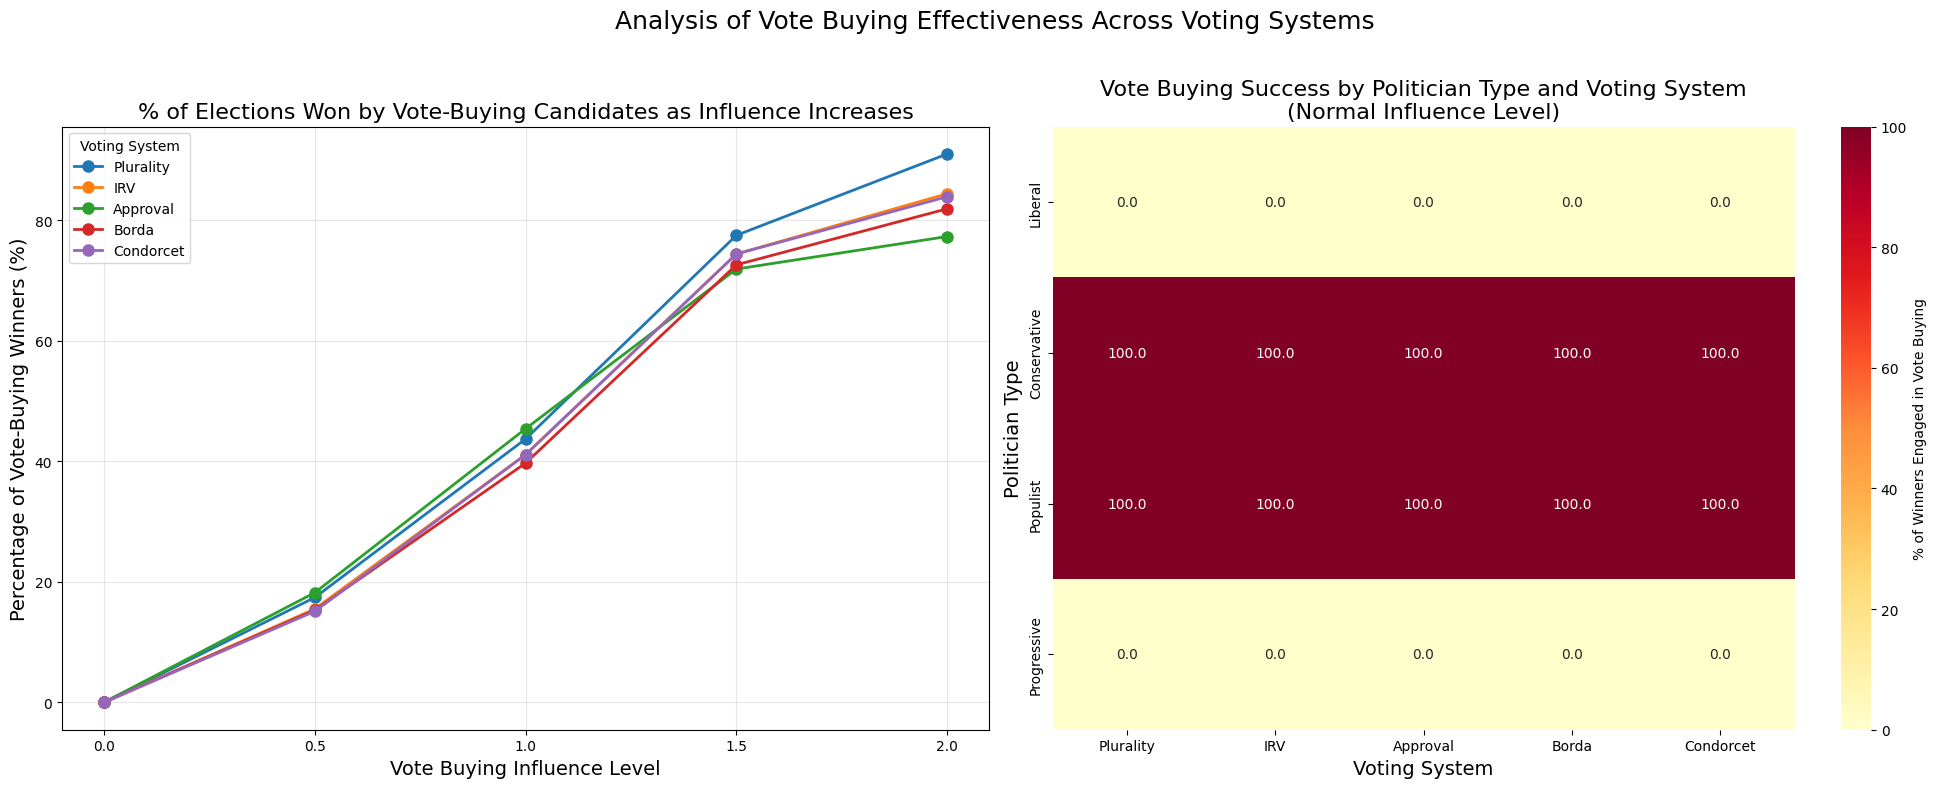

<Figure size 1200x600 with 0 Axes>

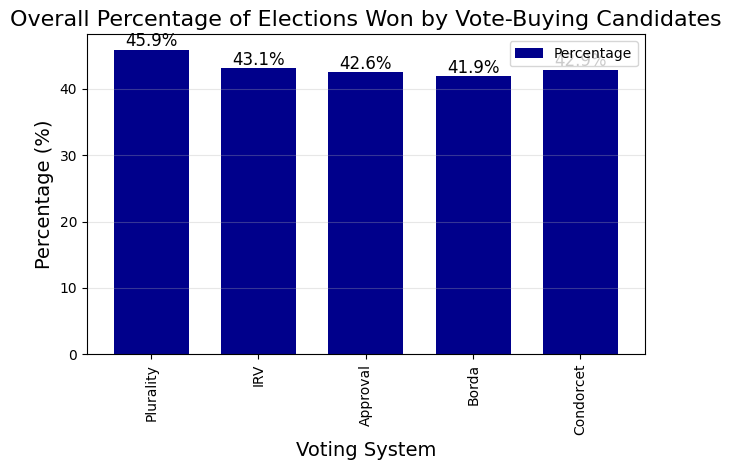

In [30]:
# Create a visualization to analyze how vote buying influences electoral outcomes across systems

# Filter data for different influence levels to see the trend
influence_levels = sorted(sim_df['influence'].unique())
vb_winner_trends = pd.DataFrame(index=influence_levels, columns=voting_systems)

# Calculate percentage of vote buying winners at each influence level for each system
for influence in influence_levels:
    filtered_data = sim_df[sim_df['influence'] == influence]
    for system in voting_systems:
        vb_winner_trends.loc[influence, system] = filtered_data[f'{system} Winner Vote Buying'].mean() * 100

# Ensure all values are numeric
vb_winner_trends = vb_winner_trends.astype(float)

# Create the main figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Trend of vote buying winners as influence increases
vb_winner_trends.plot(marker='o', linewidth=2, markersize=8, ax=ax1)
ax1.set_title('% of Elections Won by Vote-Buying Candidates as Influence Increases', fontsize=16)
ax1.set_xlabel('Vote Buying Influence Level', fontsize=14)
ax1.set_ylabel('Percentage of Vote-Buying Winners (%)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Voting System')
ax1.set_xticks(influence_levels)

# For the second plot, analyze which politician types are most likely to win via vote buying
# Create a heatmap showing the percentage of vote buying winners by winner type for each system

# Filter for normal influence level (1.0) to show realistic effects
normal_influence_data = sim_df[sim_df['influence'] == 1.0]

# Get all winner types
winner_types = ['Liberal', 'Conservative', 'Populist', 'Progressive']

# Calculate percentage of vote-buying winners by type for each system
vb_by_type_and_system = pd.DataFrame(index=winner_types, columns=voting_systems)

for system in voting_systems:
    for winner_type in winner_types:
        type_data = normal_influence_data[normal_influence_data[f'{system} Winner Type'] == winner_type]
        if len(type_data) > 0:
            vb_by_type_and_system.loc[winner_type, system] = type_data[f'{system} Winner Vote Buying'].mean() * 100
        else:
            vb_by_type_and_system.loc[winner_type, system] = 0

# Convert the dataframe values to float type
vb_by_type_and_system = vb_by_type_and_system.astype(float)

# Create heatmap
sns.heatmap(vb_by_type_and_system, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': '% of Winners Engaged in Vote Buying'}, ax=ax2)
ax2.set_title('Vote Buying Success by Politician Type and Voting System\n(Normal Influence Level)', fontsize=16)
ax2.set_ylabel('Politician Type', fontsize=14)
ax2.set_xlabel('Voting System', fontsize=14)

# Add a subtitle to explain the visualization
plt.suptitle('Analysis of Vote Buying Effectiveness Across Voting Systems', fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Add a third chart below to show total vote buying winners across all influence levels
plt.figure(figsize=(12, 6))
overall_vb_winners = pd.DataFrame(index=['Percentage'])

for system in voting_systems:
    vb_col = f'{system} Winner Vote Buying'
    overall_vb_winners[system] = sim_df[vb_col].mean() * 100

# Plot bar chart - ensure numeric data
overall_vb_winners = overall_vb_winners.astype(float)
ax3 = overall_vb_winners.T.plot(kind='bar', color='darkblue', width=0.7)
plt.title('Overall Percentage of Elections Won by Vote-Buying Candidates', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.xlabel('Voting System', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add percentage values on top of bars
for i, v in enumerate(overall_vb_winners.loc['Percentage']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

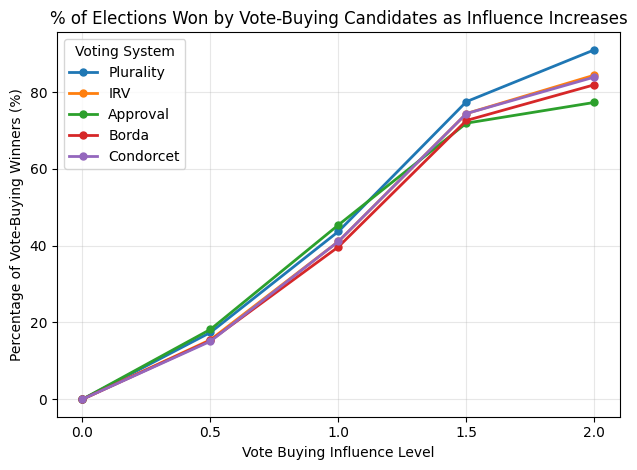

In [67]:
# Create a visualization to analyze how vote buying influences electoral outcomes across systems

# Filter data for different influence levels to see the trend
influence_levels = sorted(sim_df['influence'].unique())
vb_winner_trends = pd.DataFrame(index=influence_levels, columns=voting_systems)

# Calculate percentage of vote buying winners at each influence level for each system
for influence in influence_levels:
    filtered_data = sim_df[sim_df['influence'] == influence]
    for system in voting_systems:
        vb_winner_trends.loc[influence, system] = filtered_data[f'{system} Winner Vote Buying'].mean() * 100

# Ensure all values are numeric
vb_winner_trends = vb_winner_trends.astype(float)

# Create the figure
plt.figure(figsize=(14, 8))

# Plot the trend of vote buying winners as influence increases
vb_winner_trends.plot(marker='o', linewidth=2, markersize=5)
plt.title('% of Elections Won by Vote-Buying Candidates as Influence Increases', fontsize=12)
plt.xlabel('Vote Buying Influence Level', fontsize=10)
plt.ylabel('Percentage of Vote-Buying Winners (%)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(title='Voting System')
plt.xticks(influence_levels)

plt.tight_layout()
plt.show()

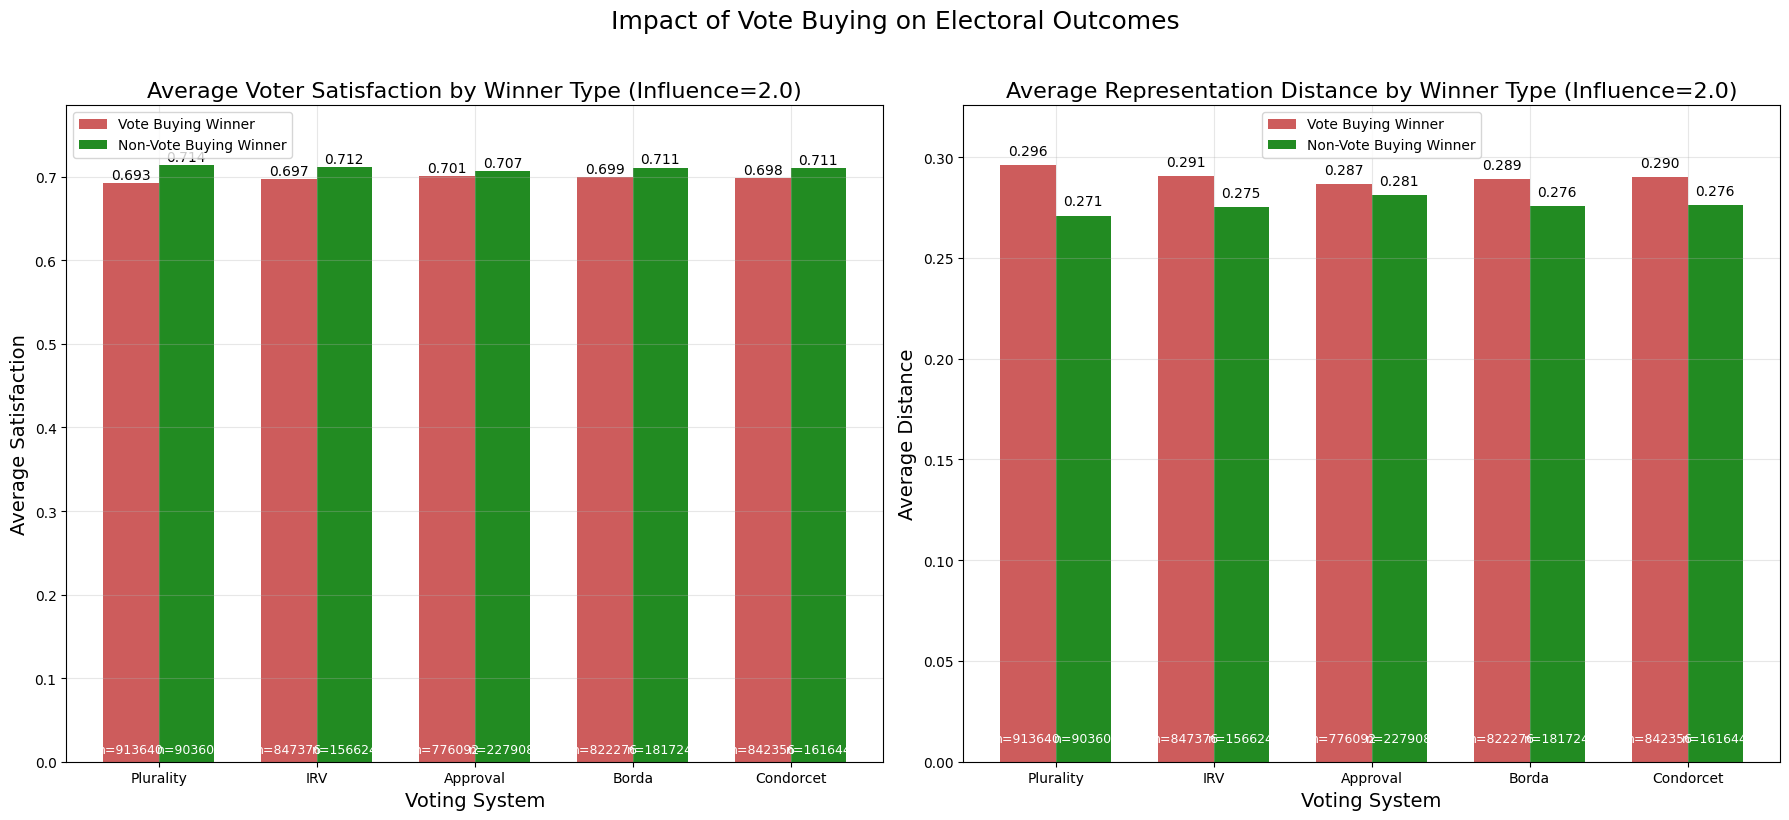

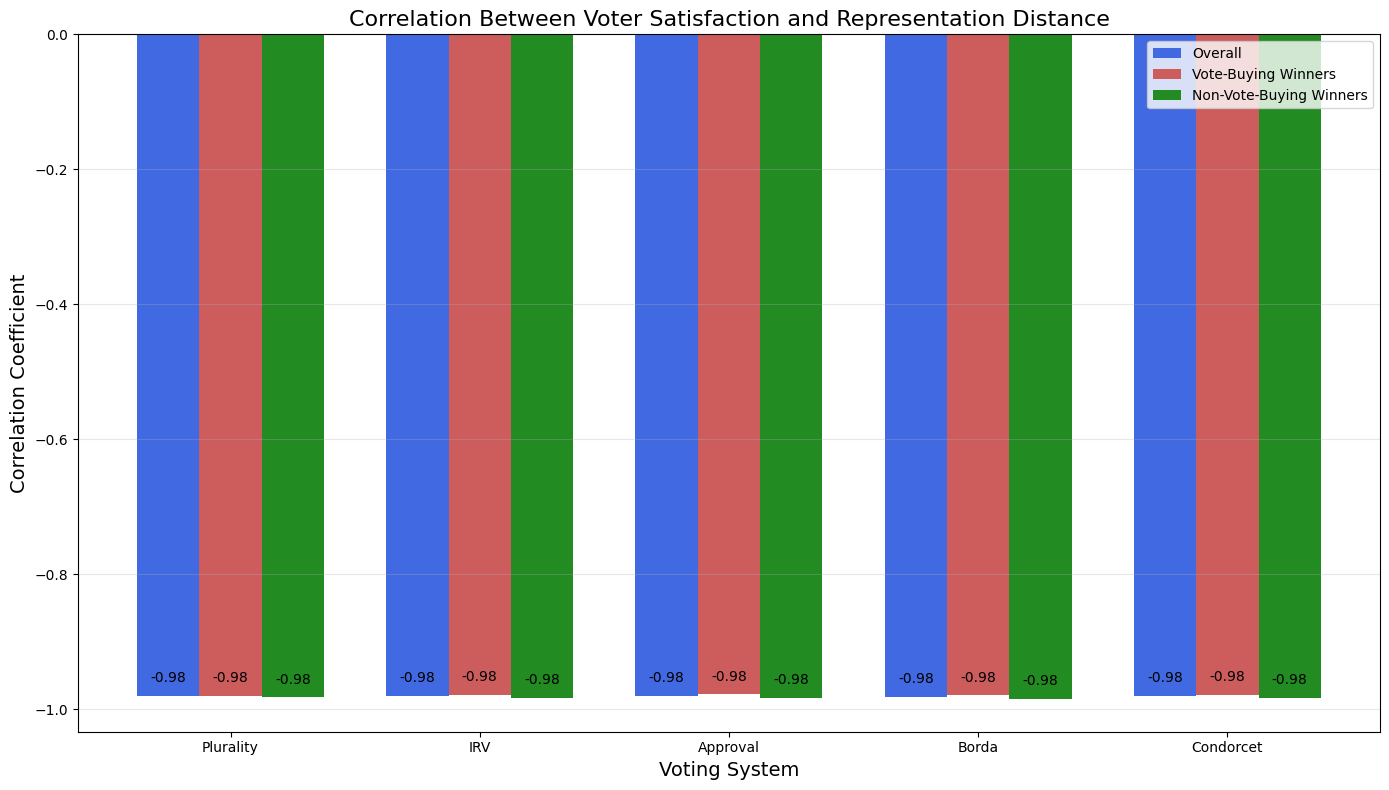

In [31]:
# Create visualizations for voter satisfaction and representation distance
# comparing vote-buying vs non-vote-buying winners across voting systems

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Filter data for influence level 2.0 to see clearer effects
influence_2_df = sim_df[sim_df['influence'] == 2.0]

# Calculate metrics for each voting system
results = []
for system in voting_systems:
    vb_data = influence_2_df[influence_2_df[f'{system} Winner Vote Buying'] == True]
    non_vb_data = influence_2_df[influence_2_df[f'{system} Winner Vote Buying'] == False]
    
    # Calculate average satisfaction and distance
    results.append({
        'System': system,
        'Satisfaction (VB)': vb_data[f'{system} Satisfaction'].mean(),
        'Satisfaction (Non-VB)': non_vb_data[f'{system} Satisfaction'].mean(),
        'Distance (VB)': vb_data[f'{system} Distance'].mean(),
        'Distance (Non-VB)': non_vb_data[f'{system} Distance'].mean(),
        'Count (VB)': len(vb_data),
        'Count (Non-VB)': len(non_vb_data),
    })

results_df = pd.DataFrame(results)

# Bar width
bar_width = 0.35
index = np.arange(len(voting_systems))

# Plot satisfaction data
satisfaction_vb = ax1.bar(index - bar_width/2, results_df['Satisfaction (VB)'], bar_width, 
                         label='Vote Buying Winner', color='indianred')
satisfaction_non_vb = ax1.bar(index + bar_width/2, results_df['Satisfaction (Non-VB)'], bar_width, 
                             label='Non-Vote Buying Winner', color='forestgreen')

# Add value labels
for i, v in enumerate(results_df['Satisfaction (VB)']):
    ax1.text(i - bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(results_df['Satisfaction (Non-VB)']):
    ax1.text(i + bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# Add sample size annotations
for i, (vb_count, non_vb_count) in enumerate(zip(results_df['Count (VB)'], results_df['Count (Non-VB)'])):
    ax1.text(i - bar_width/2, 0.01, f'n={vb_count}', ha='center', fontsize=9, color='white')
    ax1.text(i + bar_width/2, 0.01, f'n={non_vb_count}', ha='center', fontsize=9, color='white')

ax1.set_title('Average Voter Satisfaction by Winner Type (Influence=2.0)', fontsize=16)
ax1.set_ylabel('Average Satisfaction', fontsize=14)
ax1.set_xlabel('Voting System', fontsize=14)
ax1.set_xticks(index)
ax1.set_xticklabels(voting_systems)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(results_df['Satisfaction (VB)'].max(), results_df['Satisfaction (Non-VB)'].max()) * 1.1)

# Plot distance data
distance_vb = ax2.bar(index - bar_width/2, results_df['Distance (VB)'], bar_width, 
                     label='Vote Buying Winner', color='indianred')
distance_non_vb = ax2.bar(index + bar_width/2, results_df['Distance (Non-VB)'], bar_width, 
                         label='Non-Vote Buying Winner', color='forestgreen')

# Add value labels
for i, v in enumerate(results_df['Distance (VB)']):
    ax2.text(i - bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(results_df['Distance (Non-VB)']):
    ax2.text(i + bar_width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# Add sample size annotations (same as first plot)
for i, (vb_count, non_vb_count) in enumerate(zip(results_df['Count (VB)'], results_df['Count (Non-VB)'])):
    ax2.text(i - bar_width/2, 0.01, f'n={vb_count}', ha='center', fontsize=9, color='white')
    ax2.text(i + bar_width/2, 0.01, f'n={non_vb_count}', ha='center', fontsize=9, color='white')

ax2.set_title('Average Representation Distance by Winner Type (Influence=2.0)', fontsize=16)
ax2.set_ylabel('Average Distance', fontsize=14)
ax2.set_xlabel('Voting System', fontsize=14)
ax2.set_xticks(index)
ax2.set_xticklabels(voting_systems)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(results_df['Distance (VB)'].max(), results_df['Distance (Non-VB)'].max()) * 1.1)

plt.tight_layout()
plt.suptitle('Impact of Vote Buying on Electoral Outcomes', fontsize=18, y=1.02)
plt.subplots_adjust(top=0.9)

# Create a third plot for correlation analysis
plt.figure(figsize=(14, 8))

# Calculate correlation between satisfaction and distance for each system
corr_data = []
for system in voting_systems:
    # Overall correlation
    overall_corr = sim_df[f'{system} Satisfaction'].corr(sim_df[f'{system} Distance'])
    
    # Correlation for vote-buying winners
    vb_df = sim_df[sim_df[f'{system} Winner Vote Buying'] == True]
    vb_corr = vb_df[f'{system} Satisfaction'].corr(vb_df[f'{system} Distance'])
    
    # Correlation for non-vote-buying winners
    non_vb_df = sim_df[sim_df[f'{system} Winner Vote Buying'] == False]
    non_vb_corr = non_vb_df[f'{system} Satisfaction'].corr(non_vb_df[f'{system} Distance'])
    
    corr_data.append({
        'System': system,
        'Overall Correlation': overall_corr,
        'VB Winners Correlation': vb_corr,
        'Non-VB Winners Correlation': non_vb_corr
    })

corr_df = pd.DataFrame(corr_data)

# Plot correlation data
x = np.arange(len(voting_systems))
width = 0.25

plt.bar(x - width, corr_df['Overall Correlation'], width, label='Overall', color='royalblue')
plt.bar(x, corr_df['VB Winners Correlation'], width, label='Vote-Buying Winners', color='indianred')
plt.bar(x + width, corr_df['Non-VB Winners Correlation'], width, label='Non-Vote-Buying Winners', color='forestgreen')

plt.title('Correlation Between Voter Satisfaction and Representation Distance', fontsize=16)
plt.xlabel('Voting System', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xticks(x, voting_systems)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(corr_df['Overall Correlation']):
    plt.text(i - width, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
for i, v in enumerate(corr_df['VB Winners Correlation']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
for i, v in enumerate(corr_df['Non-VB Winners Correlation']):
    plt.text(i + width, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

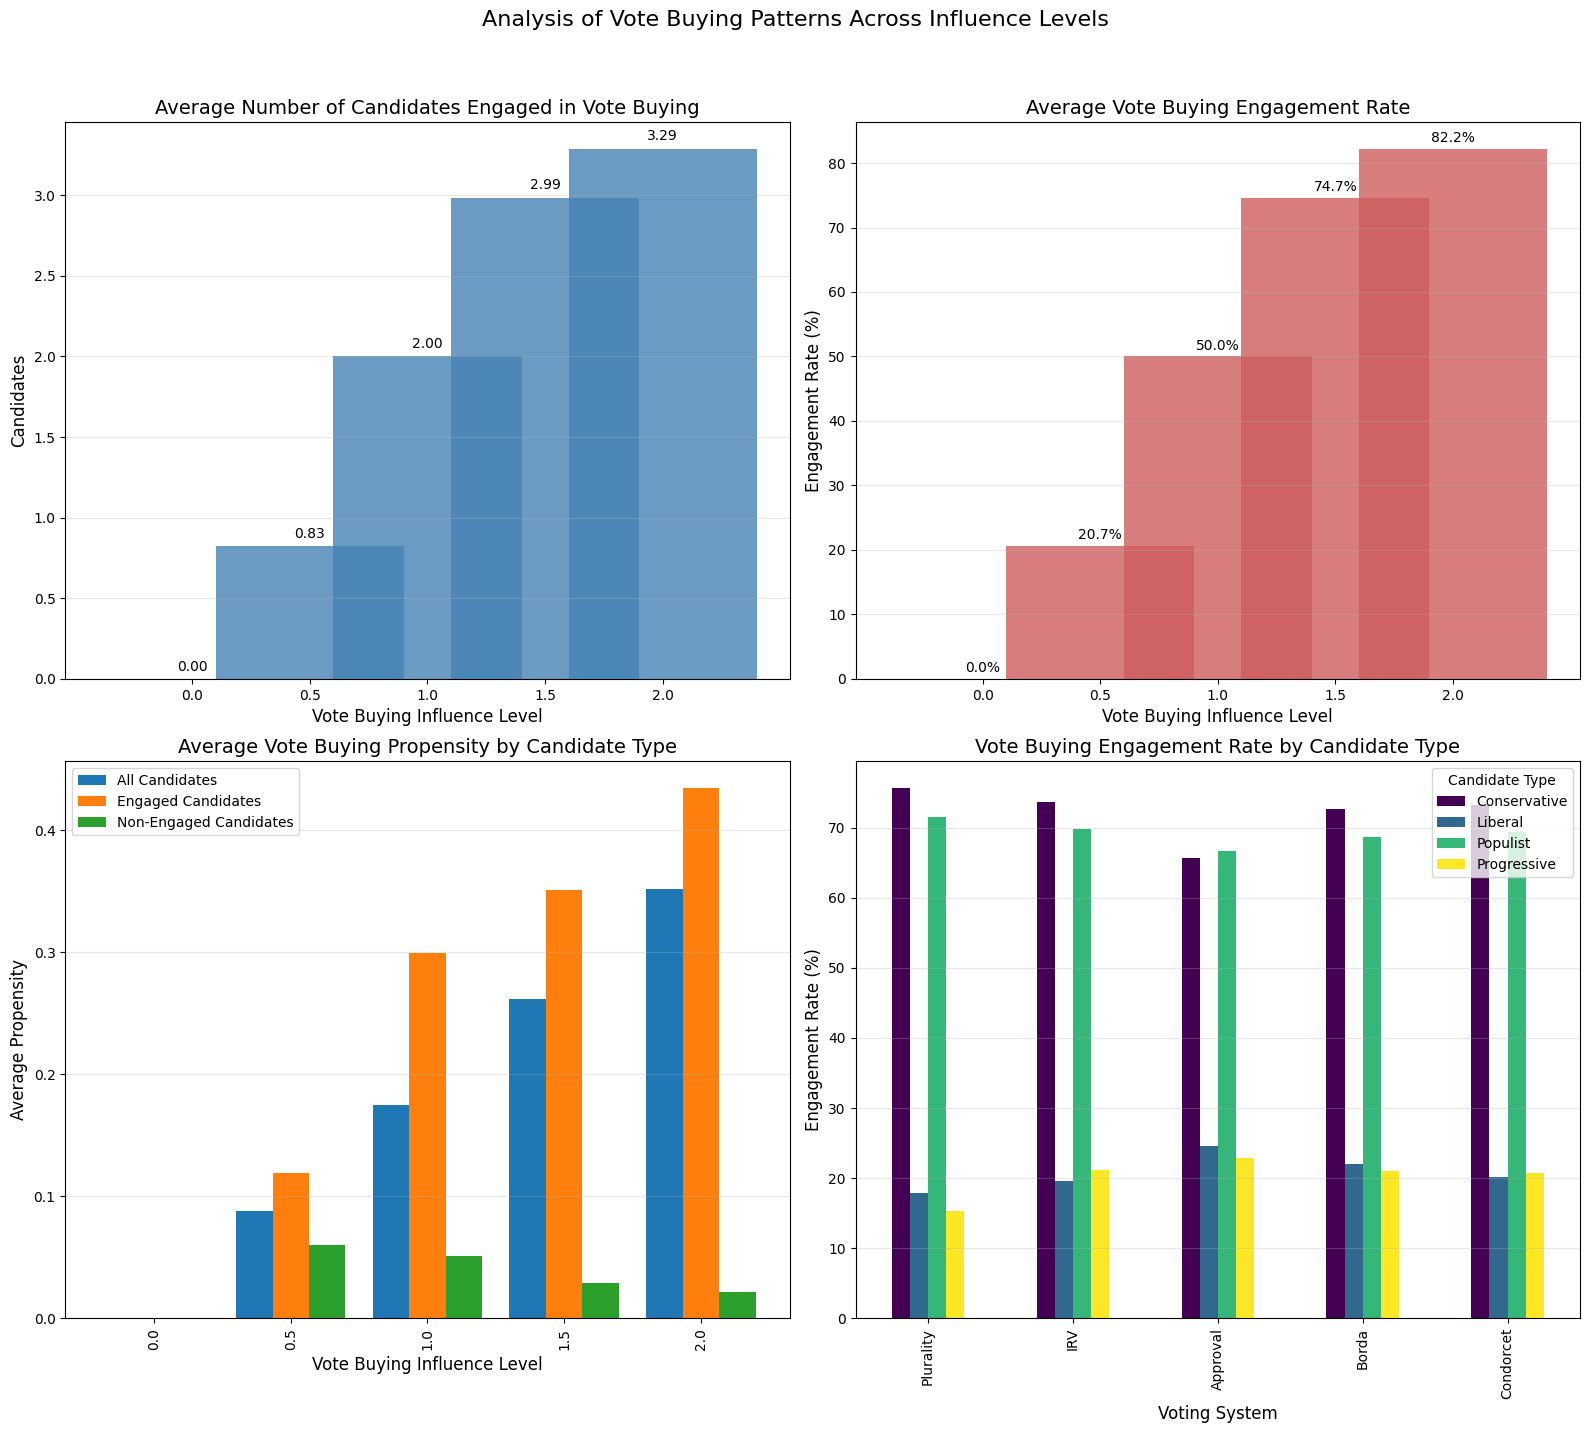

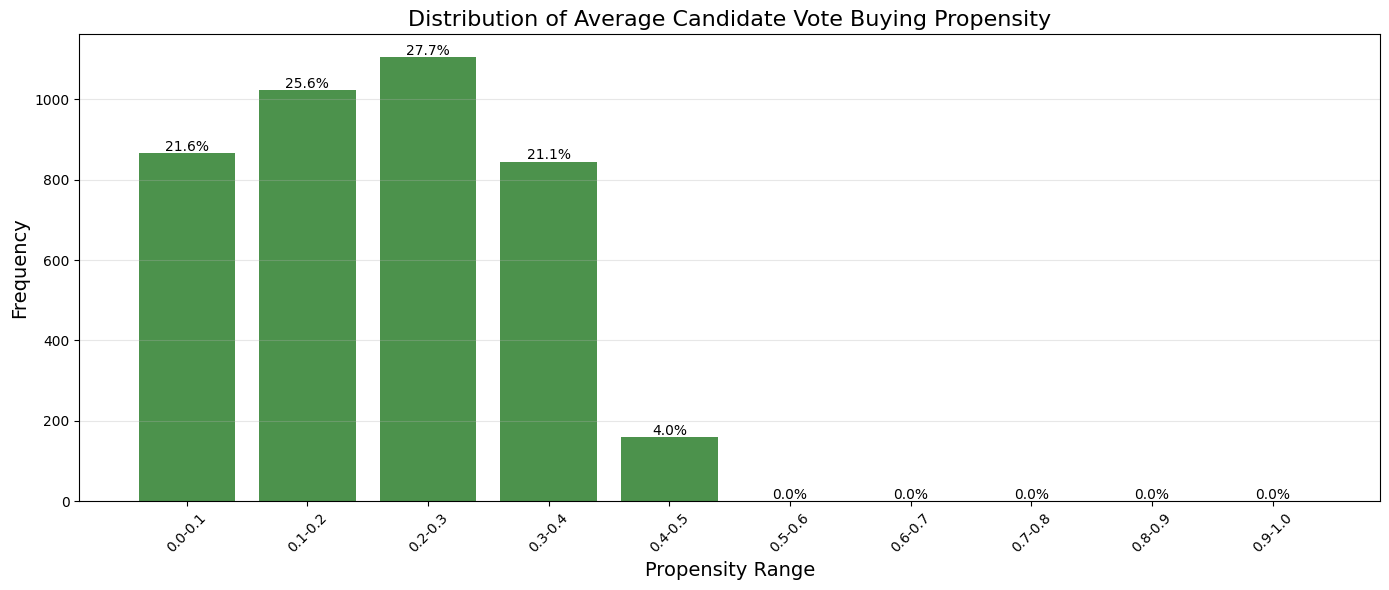

In [32]:
# Create a comprehensive visualization to analyze vote buying patterns across different influence levels

# Set up figure with 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 14))

# 1. Total candidates engaged in vote buying by influence level
influence_levels = sorted(sim_df['influence'].unique())
engagement_by_influence = []

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence]
    # Count occurrences of each engagement level and take the mean to get the representative value
    engagement_counts = subset['Total Candidates Engaged in Vote Buying'].value_counts().sort_index()
    total_candidates = subset['num_candidates'].mean()
    engagement_data = {
        'influence': influence,
        'counts': engagement_counts,
        'avg_engagement': subset['Total Candidates Engaged in Vote Buying'].mean(),
        'avg_rate': subset['Vote Buying Engagement Rate'].mean() * 100
    }
    engagement_by_influence.append(engagement_data)

# Plot total candidates engaged
avg_engagement = [data['avg_engagement'] for data in engagement_by_influence]
axs[0, 0].bar(influence_levels, avg_engagement, color='steelblue', alpha=0.8)
axs[0, 0].set_title('Average Number of Candidates Engaged in Vote Buying', fontsize=14)
axs[0, 0].set_xlabel('Vote Buying Influence Level', fontsize=12)
axs[0, 0].set_ylabel('Candidates', fontsize=12)
axs[0, 0].grid(axis='y', alpha=0.3)
axs[0, 0].set_xticks(influence_levels)

# Add value labels
for i, v in enumerate(avg_engagement):
    axs[0, 0].text(influence_levels[i], v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

# 2. Vote buying engagement rate
avg_rates = [data['avg_rate'] for data in engagement_by_influence]
axs[0, 1].bar(influence_levels, avg_rates, color='indianred', alpha=0.8)
axs[0, 1].set_title('Average Vote Buying Engagement Rate', fontsize=14)
axs[0, 1].set_xlabel('Vote Buying Influence Level', fontsize=12)
axs[0, 1].set_ylabel('Engagement Rate (%)', fontsize=12)
axs[0, 1].grid(axis='y', alpha=0.3)
axs[0, 1].set_xticks(influence_levels)

# Add value labels
for i, v in enumerate(avg_rates):
    axs[0, 1].text(influence_levels[i], v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# 3. Average propensity by candidate engagement status
propensity_data = pd.DataFrame({
    'Influence': influence_levels,
    'All Candidates': [sim_df[sim_df['influence'] == i]['Avg Candidate Propensity'].mean() for i in influence_levels],
    'Engaged Candidates': [sim_df[sim_df['influence'] == i]['Avg Propensity (Engaged)'].mean() for i in influence_levels],
    'Non-Engaged Candidates': [sim_df[sim_df['influence'] == i]['Avg Propensity (Not Engaged)'].mean() for i in influence_levels]
})

# Plot propensity by engagement status
propensity_data.plot(x='Influence', y=['All Candidates', 'Engaged Candidates', 'Non-Engaged Candidates'], 
                    kind='bar', ax=axs[1, 0], width=0.8)
axs[1, 0].set_title('Average Vote Buying Propensity by Candidate Type', fontsize=14)
axs[1, 0].set_xlabel('Vote Buying Influence Level', fontsize=12)
axs[1, 0].set_ylabel('Average Propensity', fontsize=12)
axs[1, 0].set_xticklabels(influence_levels)
axs[1, 0].legend()
axs[1, 0].grid(axis='y', alpha=0.3)

# 4. Vote buying propensity distribution by candidate type
# Create a new DataFrame to store candidate data
candidate_data = []

# Use winner_vb_df if available, which contains the vote buying rates by candidate type
if 'winner_vb_df' in globals() and not winner_vb_df.empty:
    # Plot engagement rate by candidate type across voting systems
    winner_vb_df.plot(kind='bar', ax=axs[1, 1], colormap='viridis')
    axs[1, 1].set_title('Vote Buying Engagement Rate by Candidate Type', fontsize=14)
    axs[1, 1].set_xlabel('Voting System', fontsize=12)
    axs[1, 1].set_ylabel('Engagement Rate (%)', fontsize=12)
    axs[1, 1].legend(title='Candidate Type')
    axs[1, 1].grid(axis='y', alpha=0.3)
else:
    # If winner_vb_df is not available, create a new analysis from sim_df
    # Filter for candidate rows and extract relevant data
    for influence in influence_levels:
        # Skip influence level 0 (no vote buying)
        if influence == 0:
            continue
            
        influence_df = sim_df[(sim_df['influence'] == influence) & (sim_df['AgentType'] == 'Candidate')]
        
        # Make sure to identify unique candidates properly
        if 'Candidate Type' in influence_df.columns:
            influence_df = influence_df.drop_duplicates(['RunId', 'iteration', 'AgentID'])
            
            # Extract data for each candidate type
            for candidate_type in ['Liberal', 'Conservative', 'Populist', 'Progressive']:
                subset = influence_df[influence_df['Candidate Type'] == candidate_type]
                if not subset.empty:
                    engaged_candidates = subset[subset['Candidate Engaged in Vote Buying'] == 'True']
                    
                    candidate_data.append({
                        'Influence': influence,
                        'Candidate Type': candidate_type,
                        'Average Propensity': subset['Candidate Propensity'].mean() if 'Candidate Propensity' in subset.columns else 0,
                        'Engagement Rate': len(engaged_candidates) / len(subset) * 100 if len(subset) > 0 else 0
                    })
    
    # Convert to DataFrame
    if candidate_data:
        candidate_df = pd.DataFrame(candidate_data)
        
        # Plot engagement rate by candidate type
        pivot_df = candidate_df.pivot_table(index='Candidate Type', columns='Influence', values='Engagement Rate')
        pivot_df.plot(kind='bar', ax=axs[1, 1], colormap='viridis')
        axs[1, 1].set_title('Vote Buying Engagement Rate by Candidate Type', fontsize=14)
        axs[1, 1].set_xlabel('Candidate Type', fontsize=12)
        axs[1, 1].set_ylabel('Engagement Rate (%)', fontsize=12)
        axs[1, 1].legend(title='Influence Level')
        axs[1, 1].grid(axis='y', alpha=0.3)
    else:
        # If no candidate data is available, plot the alternative visualization
        # Create a stacked bar chart showing vote buying winner percentages by system
        vb_winners_by_system = pd.DataFrame()
        non_zero_influence = [i for i in influence_levels if i > 0]
        
        # Define voting systems
        voting_systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
        
        for influence in non_zero_influence:
            subset = sim_df[sim_df['influence'] == influence]
            for system in voting_systems:
                vb_col = f'{system} Winner Vote Buying'
                vb_winners_by_system.loc[influence, system] = subset[vb_col].mean() * 100
        
        vb_winners_by_system.plot(kind='bar', stacked=False, ax=axs[1, 1], colormap='viridis')
        axs[1, 1].set_title('% of Vote Buying Winners by Voting System', fontsize=14)
        axs[1, 1].set_xlabel('Influence Level', fontsize=12)
        axs[1, 1].set_ylabel('Percentage of Winners (%)', fontsize=12)
        axs[1, 1].legend(title='Voting System')
        axs[1, 1].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.suptitle('Analysis of Vote Buying Patterns Across Influence Levels', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.94)

# Additional plot for propensity distribution
plt.figure(figsize=(14, 6))

# Create bins for propensity
bins = np.linspace(0, 1, 11)
bin_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

# Filter data for influence > 0
non_zero_df = sim_df[sim_df['influence'] > 0].drop_duplicates(['RunId', 'iteration'])
non_zero_df['Propensity_Bin'] = pd.cut(non_zero_df['Avg Candidate Propensity'], bins=bins, labels=bin_labels)

# Count occurrences in each bin
propensity_counts = non_zero_df['Propensity_Bin'].value_counts().sort_index()

# Plot propensity distribution
plt.bar(propensity_counts.index, propensity_counts.values, color='darkgreen', alpha=0.7)
plt.title('Distribution of Average Candidate Vote Buying Propensity', fontsize=16)
plt.xlabel('Propensity Range', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Add percentage labels
total = propensity_counts.sum()
for i, count in enumerate(propensity_counts):
    percentage = (count / total) * 100
    plt.text(i, count + 5, f"{percentage:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2314413617.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 0].set_xticklabels(income_labels, rotation=45, ha='right')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2314413617.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 1].set_xticklabels(edu_labels, rotation=45, ha='right')


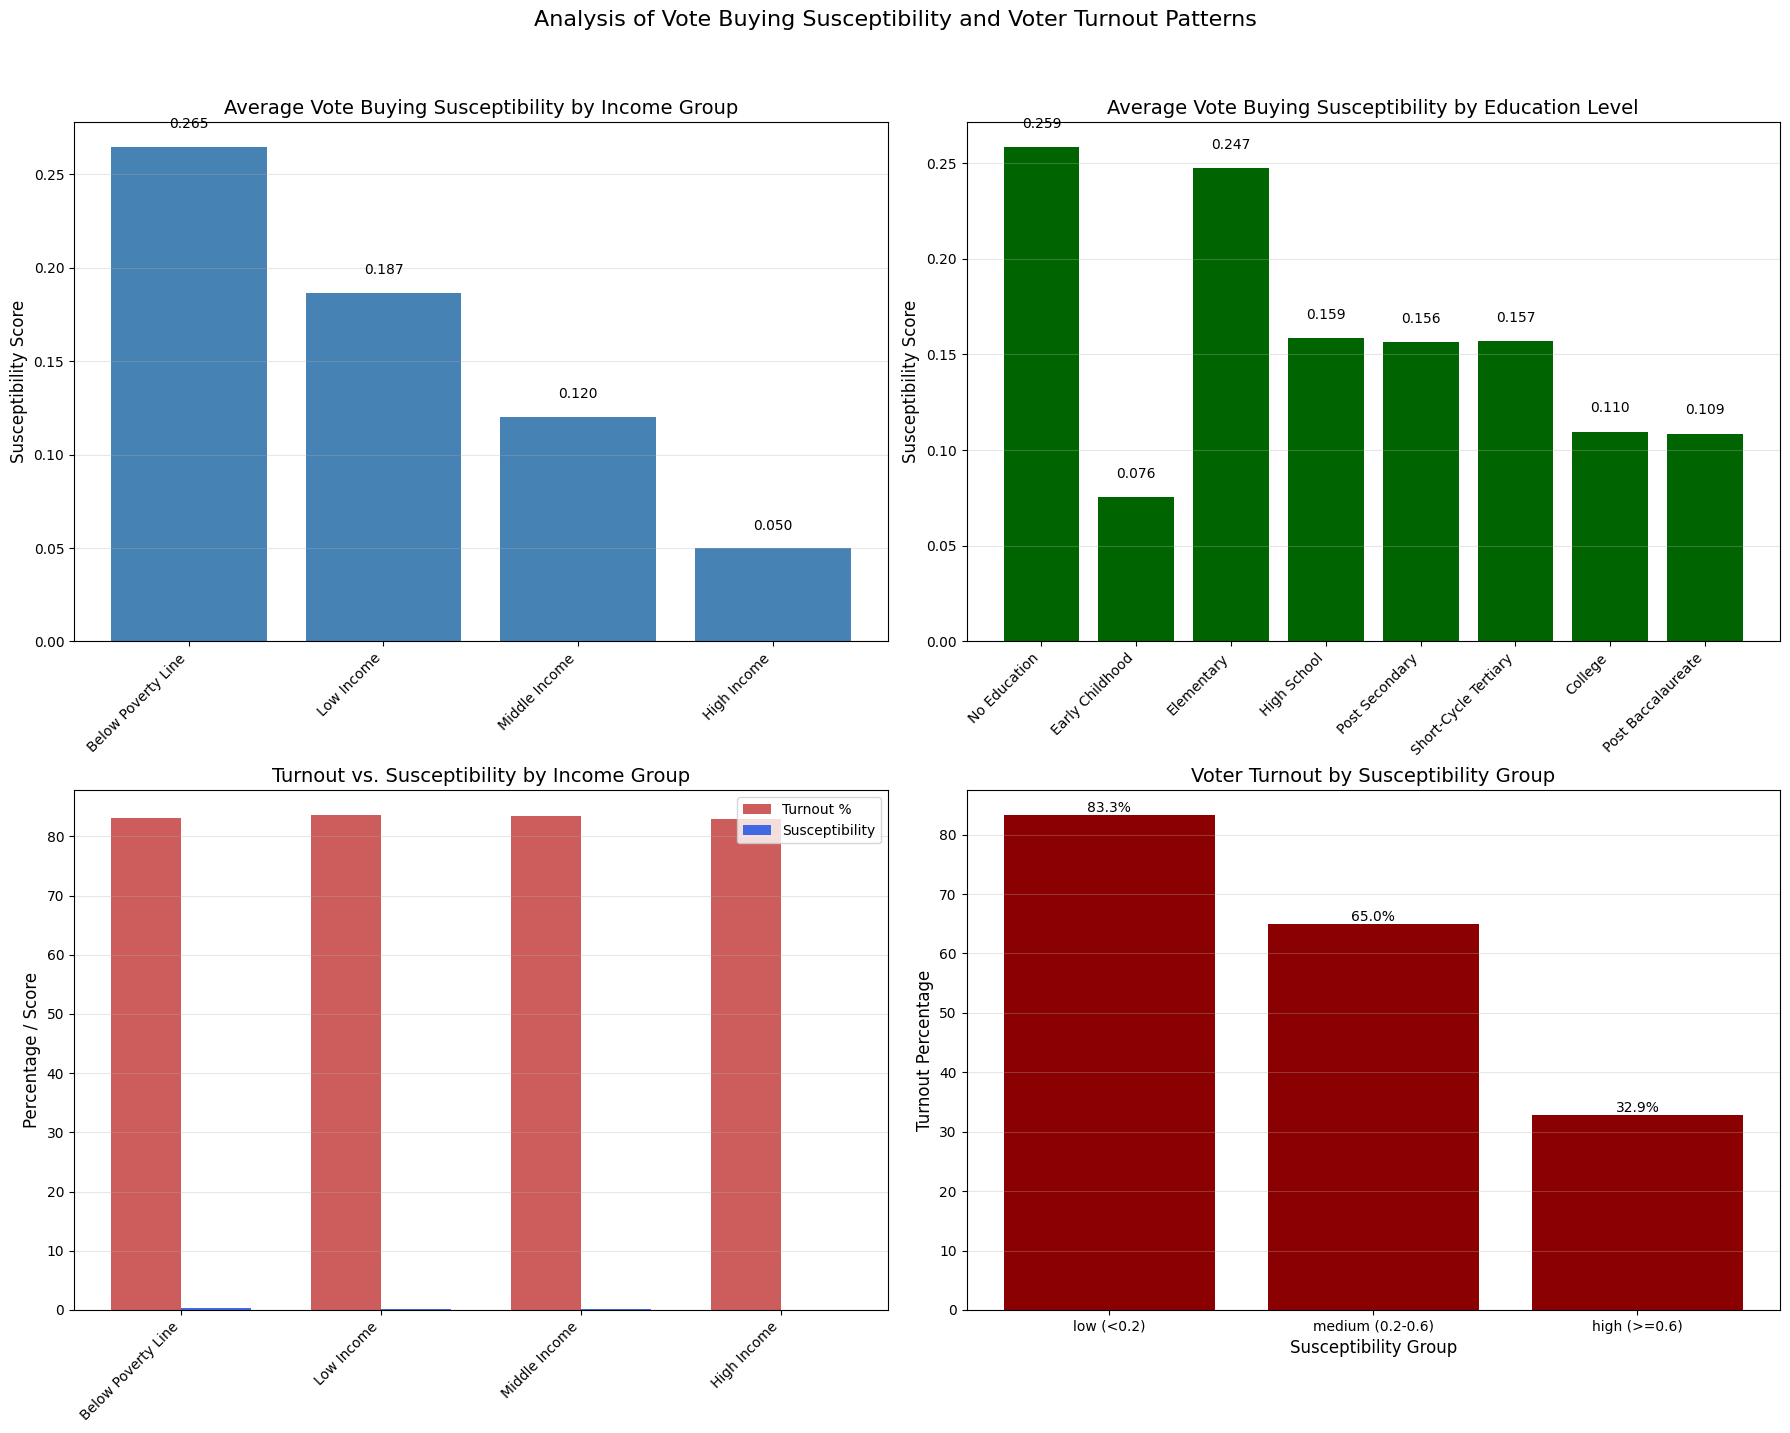

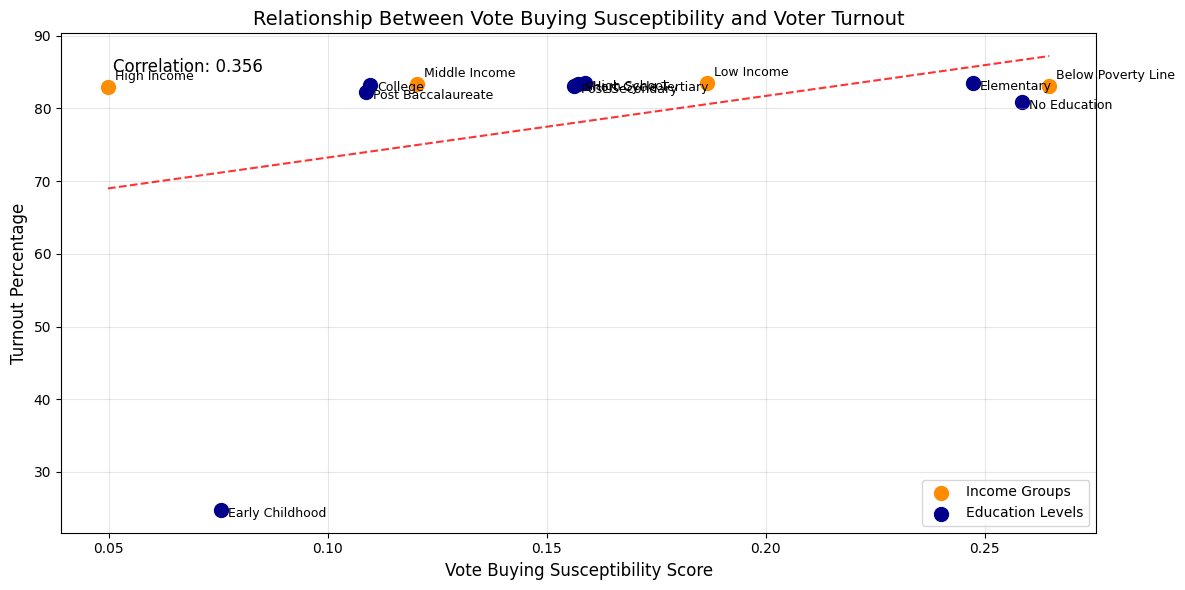

In [33]:
# Create a comprehensive visualization of vote buying susceptibility and turnout patterns

# Set up figure with 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Process the dictionary data for cleaner visualization
def process_dictionary_data(dict_str):
    """Convert dictionary string to actual dictionary with clean values"""
    clean_dict = eval(dict_str.replace('np.float64', 'float'))
    return {k: float(v) for k, v in clean_dict.items()}

# Get a sample row to extract consistent keys
sample_row = sim_df.iloc[0]
income_keys = list(process_dictionary_data(sample_row['Avg Susceptibility by Income']).keys())
edu_keys = list(process_dictionary_data(sample_row['Avg Susceptibility by Education']).keys())
suscept_keys = list(process_dictionary_data(sample_row['Turnout by Susceptibility Group']).keys())

# Process dictionaries for all rows
suscept_by_income = {k: [] for k in income_keys}
suscept_by_edu = {k: [] for k in edu_keys}
turnout_by_income = {k: [] for k in income_keys}
turnout_by_edu = {k: [] for k in edu_keys}
turnout_by_suscept = {k: [] for k in suscept_keys}

# Sample a subset of rows for performance
sample_rows = sim_df.sample(min(1000, len(sim_df)))

# Extract data from dictionaries
for _, row in sample_rows.iterrows():
    # Process susceptibility by income
    income_dict = process_dictionary_data(row['Avg Susceptibility by Income'])
    for k in income_keys:
        suscept_by_income[k].append(income_dict.get(k, 0))
    
    # Process susceptibility by education
    edu_dict = process_dictionary_data(row['Avg Susceptibility by Education'])
    for k in edu_keys:
        suscept_by_edu[k].append(edu_dict.get(k, 0))
    
    # Process turnout by income
    income_turnout_dict = process_dictionary_data(row['Turnout by Income'])
    for k in income_keys:
        turnout_by_income[k].append(income_turnout_dict.get(k, 0))
    
    # Process turnout by education
    edu_turnout_dict = process_dictionary_data(row['Turnout by Education'])
    for k in edu_keys:
        turnout_by_edu[k].append(edu_turnout_dict.get(k, 0))
    
    # Process turnout by susceptibility group
    suscept_turnout_dict = process_dictionary_data(row['Turnout by Susceptibility Group'])
    for k in suscept_keys:
        turnout_by_suscept[k].append(suscept_turnout_dict.get(k, 0))

# Calculate averages
avg_suscept_by_income = {k: np.mean(v) for k, v in suscept_by_income.items()}
avg_suscept_by_edu = {k: np.mean(v) for k, v in suscept_by_edu.items()}
avg_turnout_by_income = {k: np.mean(v) for k, v in turnout_by_income.items()}
avg_turnout_by_edu = {k: np.mean(v) for k, v in turnout_by_edu.items()}
avg_turnout_by_suscept = {k: np.mean(v) for k, v in turnout_by_suscept.items()}

# Prepare data for plotting
income_labels = [k.replace('_', ' ').title() for k in income_keys]
edu_labels = [k.replace('_', ' ').title() for k in edu_keys]
suscept_labels = [k for k in suscept_keys]

# 1. Plot susceptibility by income
axs[0, 0].bar(income_labels, [avg_suscept_by_income[k] for k in income_keys], color='steelblue')
axs[0, 0].set_title('Average Vote Buying Susceptibility by Income Group', fontsize=14)
axs[0, 0].set_ylabel('Susceptibility Score', fontsize=12)
axs[0, 0].grid(axis='y', alpha=0.3)
axs[0, 0].set_xticklabels(income_labels, rotation=45, ha='right')

# Add value labels
for i, v in enumerate([avg_suscept_by_income[k] for k in income_keys]):
    axs[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# 2. Plot susceptibility by education
axs[0, 1].bar(edu_labels, [avg_suscept_by_edu[k] for k in edu_keys], color='darkgreen')
axs[0, 1].set_title('Average Vote Buying Susceptibility by Education Level', fontsize=14)
axs[0, 1].set_ylabel('Susceptibility Score', fontsize=12)
axs[0, 1].grid(axis='y', alpha=0.3)
axs[0, 1].set_xticklabels(edu_labels, rotation=45, ha='right')

# Add value labels
for i, v in enumerate([avg_suscept_by_edu[k] for k in edu_keys]):
    axs[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# 3. Plot turnout comparison (income)
x = np.arange(len(income_keys))
width = 0.35
axs[1, 0].bar(x - width/2, [avg_turnout_by_income[k] for k in income_keys], width, 
             label='Turnout %', color='indianred')
axs[1, 0].bar(x + width/2, [avg_suscept_by_income[k] for k in income_keys], width, 
             label='Susceptibility', color='royalblue')

axs[1, 0].set_title('Turnout vs. Susceptibility by Income Group', fontsize=14)
axs[1, 0].set_ylabel('Percentage / Score', fontsize=12)
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(income_labels, rotation=45, ha='right')
axs[1, 0].legend()
axs[1, 0].grid(axis='y', alpha=0.3)

# 4. Plot turnout by susceptibility group
axs[1, 1].bar(suscept_labels, [avg_turnout_by_suscept[k] for k in suscept_keys], color='darkred')
axs[1, 1].set_title('Voter Turnout by Susceptibility Group', fontsize=14)
axs[1, 1].set_ylabel('Turnout Percentage', fontsize=12)
axs[1, 1].set_xlabel('Susceptibility Group', fontsize=12)
axs[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate([avg_turnout_by_suscept[k] for k in suscept_keys]):
    axs[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.suptitle('Analysis of Vote Buying Susceptibility and Voter Turnout Patterns', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.94)

# Additional plot to analyze correlation between susceptibility and turnout
plt.figure(figsize=(12, 6))

# Prepare data for correlation analysis
income_data = pd.DataFrame({
    'Group': income_labels,
    'Susceptibility': [avg_suscept_by_income[k] for k in income_keys],
    'Turnout': [avg_turnout_by_income[k] for k in income_keys]
})

edu_data = pd.DataFrame({
    'Group': edu_labels,
    'Susceptibility': [avg_suscept_by_edu[k] for k in edu_keys],
    'Turnout': [avg_turnout_by_edu[k] for k in edu_keys]
})

# Plot scatter with labels
plt.scatter(income_data['Susceptibility'], income_data['Turnout'], 
           s=100, color='darkorange', label='Income Groups')
plt.scatter(edu_data['Susceptibility'], edu_data['Turnout'], 
           s=100, color='darkblue', label='Education Levels')

# Add labels
for i, txt in enumerate(income_data['Group']):
    plt.annotate(txt, (income_data['Susceptibility'][i], income_data['Turnout'][i]), 
                fontsize=9, xytext=(5, 5), textcoords='offset points')

for i, txt in enumerate(edu_data['Group']):
    plt.annotate(txt, (edu_data['Susceptibility'][i], edu_data['Turnout'][i]), 
                fontsize=9, xytext=(5, -5), textcoords='offset points')

# Calculate and show correlation coefficient
all_suscept = list(income_data['Susceptibility']) + list(edu_data['Susceptibility'])
all_turnout = list(income_data['Turnout']) + list(edu_data['Turnout'])
corr = np.corrcoef(all_suscept, all_turnout)[0, 1]
plt.text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=plt.gca().transAxes, 
        fontsize=12, verticalalignment='top')

# Add regression line
z = np.polyfit(all_suscept, all_turnout, 1)
p = np.poly1d(z)
plt.plot(sorted(all_suscept), p(sorted(all_suscept)), "r--", alpha=0.8)

plt.title('Relationship Between Vote Buying Susceptibility and Voter Turnout', fontsize=14)
plt.xlabel('Vote Buying Susceptibility Score', fontsize=12)
plt.ylabel('Turnout Percentage', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

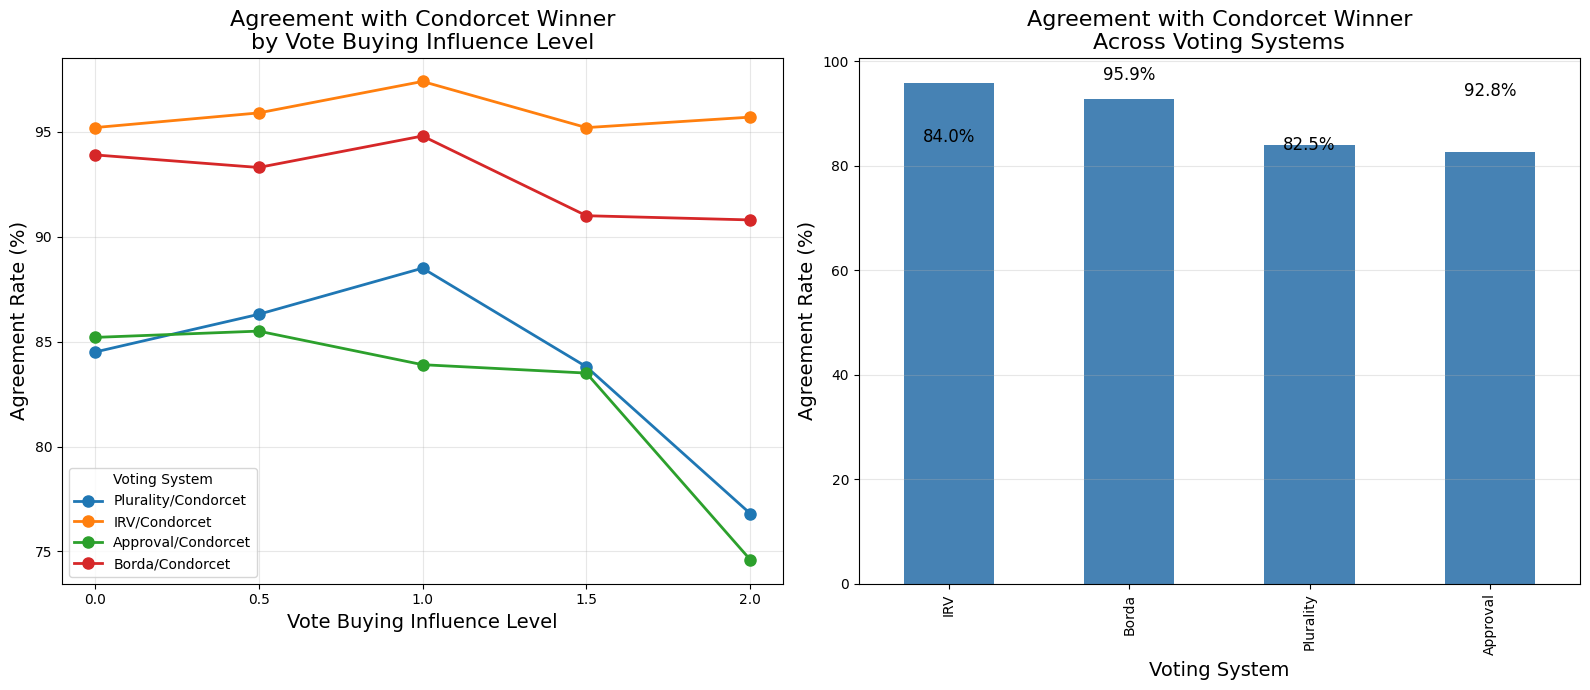

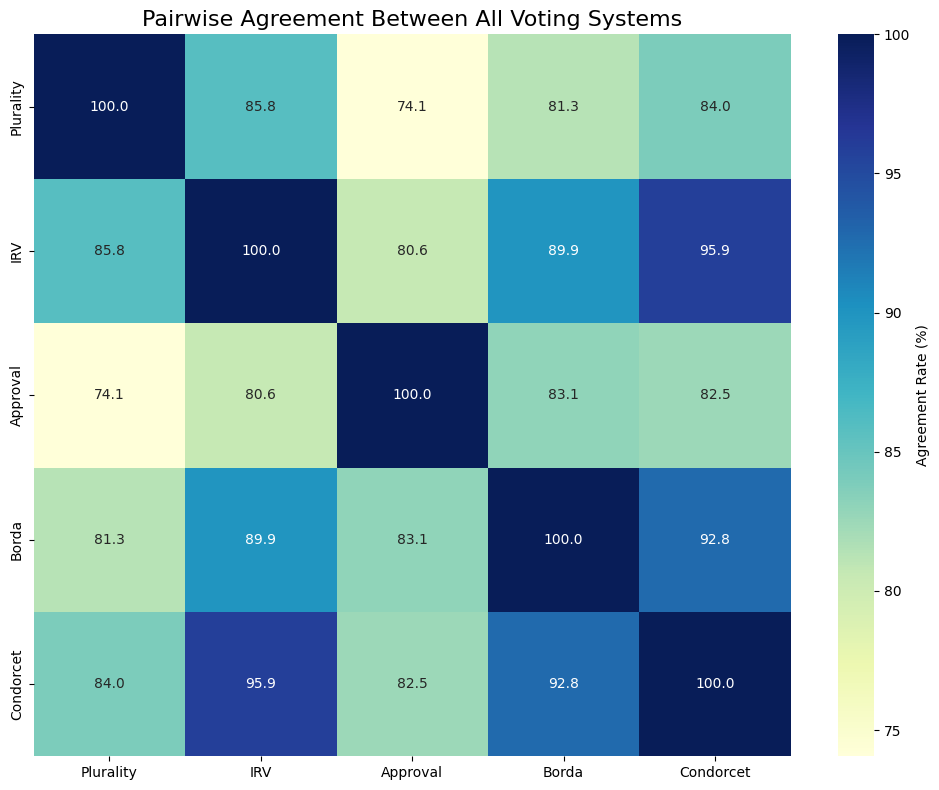

In [36]:
# Create visualization for voting system agreement patterns across influence levels

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Calculate agreement rates between voting systems for each influence level
influence_levels = sorted(sim_df['influence'].unique())
agreement_by_influence = pd.DataFrame(index=influence_levels)

# Define pairs of voting systems to analyze
system_pairs = [
    ('Plurality/Condorcet', 'Winner Agreement (Plurality/Condorcet)'),
    ('IRV/Condorcet', 'Winner Agreement (IRV/Condorcet)'),
    ('Approval/Condorcet', 'Winner Agreement (Approval/Condorcet)'),
    ('Borda/Condorcet', 'Winner Agreement (Borda/Condorcet)')
]

# Calculate agreement percentage for each pair at each influence level
for pair_name, column_name in system_pairs:
    agreement_rates = []
    for influence in influence_levels:
        subset = sim_df[sim_df['influence'] == influence]
        # If column already exists, use it, otherwise calculate directly
        if column_name in subset.columns:
            agreement_rate = subset[column_name].mean() * 100
        else:
            # Extract system names from pair_name
            sys1, sys2 = pair_name.split('/')
            agreement_rate = (subset[f'{sys1} Winner'] == subset[f'{sys2} Winner']).mean() * 100
        agreement_rates.append(agreement_rate)
    
    agreement_by_influence[pair_name] = agreement_rates

# 1. Plot agreement rates across influence levels as line chart
agreement_by_influence.plot(marker='o', linewidth=2, markersize=8, ax=ax1)
ax1.set_title('Agreement with Condorcet Winner\nby Vote Buying Influence Level', fontsize=16)
ax1.set_xlabel('Vote Buying Influence Level', fontsize=14)
ax1.set_ylabel('Agreement Rate (%)', fontsize=14)
ax1.set_xticks(influence_levels)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Voting System')

# 2. Calculate agreement rates with Condorcet system (which is often considered normatively ideal)
condorcet_agreement = pd.DataFrame(index=['Agreement with Condorcet (%)'])

for system in voting_systems:
    if system != 'Condorcet':
        column_name = f'Winner Agreement ({system}/Condorcet)'
        if column_name in sim_df.columns:
            condorcet_agreement[system] = sim_df[column_name].mean() * 100
        else:
            # If column doesn't exist, calculate it directly
            condorcet_agreement[system] = (sim_df[f'{system} Winner'] == sim_df['Condorcet Winner']).mean() * 100

# Plot overall agreement rates with Condorcet as bar chart
condorcet_agreement.T.sort_values(by='Agreement with Condorcet (%)', ascending=False).plot(
    kind='bar', ax=ax2, color='steelblue', legend=False)
ax2.set_title('Agreement with Condorcet Winner\nAcross Voting Systems', fontsize=16)
ax2.set_ylabel('Agreement Rate (%)', fontsize=14)
ax2.set_xlabel('Voting System', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, v in enumerate(condorcet_agreement.values[0]):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

plt.tight_layout()

# Create a supplementary heatmap showing pairwise agreement between all systems
plt.figure(figsize=(10, 8))

# Create data for all possible system pairs
voting_systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
agreement_matrix = pd.DataFrame(index=voting_systems, columns=voting_systems)

# Fill the matrix with agreement percentages
for i, sys1 in enumerate(voting_systems):
    for j, sys2 in enumerate(voting_systems):
        if i == j:
            agreement_matrix.loc[sys1, sys2] = 100.0  # Same system always agrees with itself
        else:
            # Check if we have this pair in system_pairs
            pair_found = False
            for pair_name, column_name in system_pairs:
                if (f"{sys1}/{sys2}" == pair_name) or (f"{sys2}/{sys1}" == pair_name):
                    # Check if column exists before trying to use it
                    if column_name in sim_df.columns:
                        agreement_matrix.loc[sys1, sys2] = float(sim_df[column_name].mean() * 100)
                    else:
                        # Calculate directly if column doesn't exist
                        agreement = (sim_df[f'{sys1} Winner'] == sim_df[f'{sys2} Winner']).mean() * 100
                        agreement_matrix.loc[sys1, sys2] = float(agreement)
                    pair_found = True
                    break
            
            # If pair not found in system_pairs, calculate it directly
            if not pair_found:
                # Ensure columns exist before comparing
                if f'{sys1} Winner' in sim_df.columns and f'{sys2} Winner' in sim_df.columns:
                    agreement = float((sim_df[f'{sys1} Winner'] == sim_df[f'{sys2} Winner']).mean() * 100)
                    agreement_matrix.loc[sys1, sys2] = agreement
                else:
                    # If columns don't exist, use a default value or calculate another way
                    agreement_matrix.loc[sys1, sys2] = 0.0

# Ensure matrix contains only float values
agreement_matrix = agreement_matrix.astype(float)

# Create the heatmap
sns.heatmap(agreement_matrix, annot=True, cmap='YlGnBu', fmt='.1f',
            cbar_kws={'label': 'Agreement Rate (%)'})
plt.title('Pairwise Agreement Between All Voting Systems', fontsize=16)

plt.tight_layout()
plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3624601485.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  score_data = [borda_efficiency[f'{system} Score'][0] for system in voting_systems]
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3624601485.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_score = borda_efficiency['Max Possible'][0]
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\3624601485.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

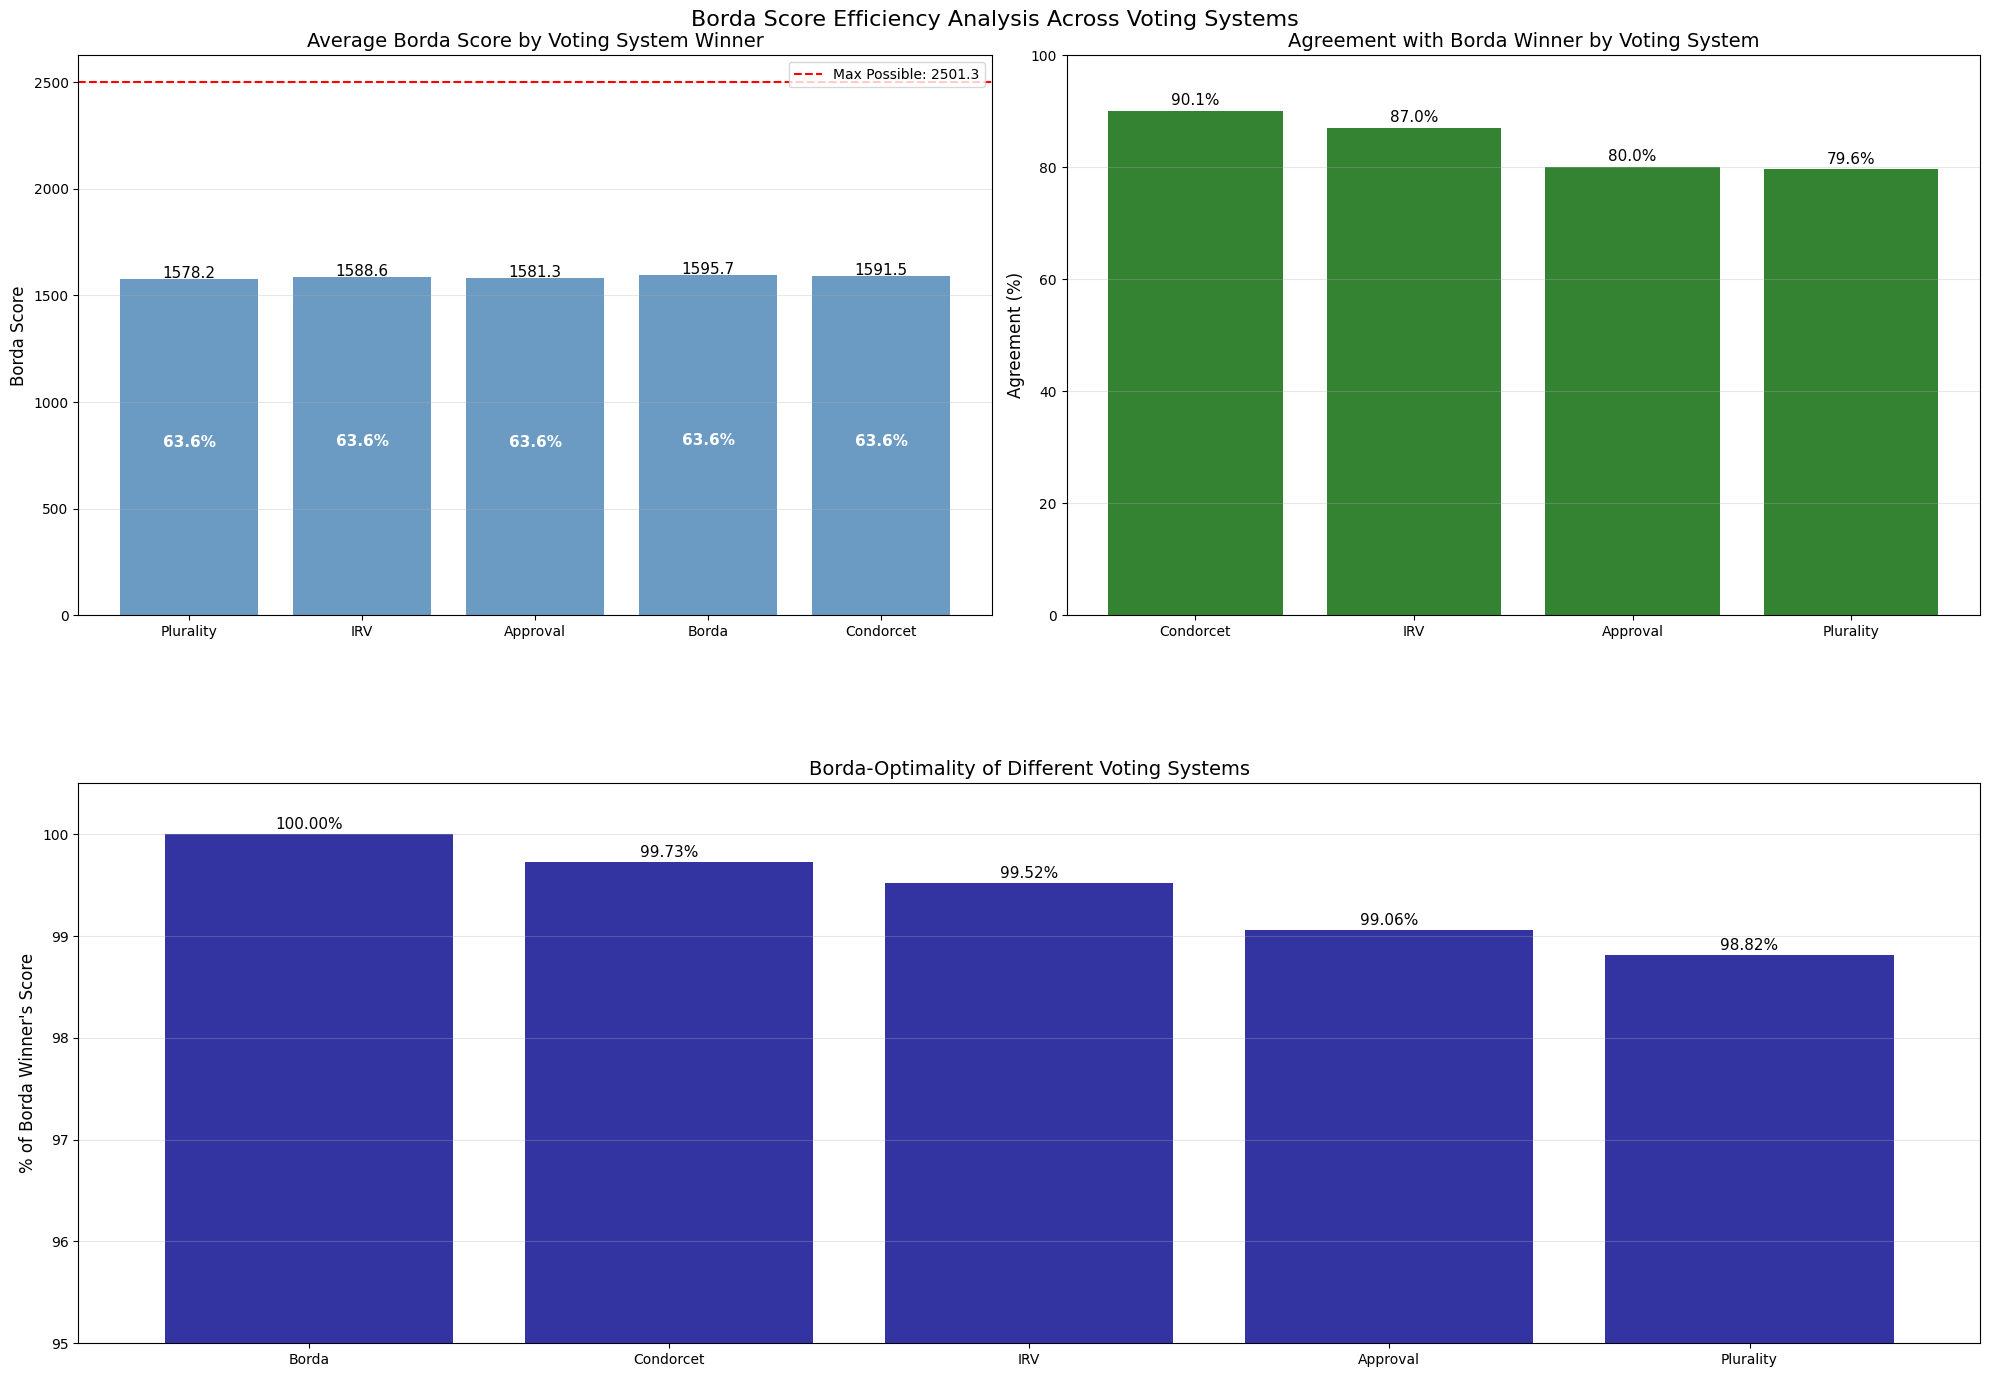

In [128]:
import ast
import ast

# Create a visualization of Borda score efficiency across voting systems
fig = plt.figure(figsize=(20, 14))
grid = plt.GridSpec(2, 2, height_ratios=[1, 1])

# Create axes
ax1 = plt.subplot(grid[0, 0])
ax2 = plt.subplot(grid[0, 1])
ax3 = plt.subplot(grid[1, :])

# Calculate average Borda score for each system's winner as percentage of max possible
borda_efficiency = pd.DataFrame(index=voting_systems)

# Calculate average Borda score for each system's winner - more efficiently
for system in voting_systems:
    col_name = f'Borda Score of {system} Winner'
    # Check if the column exists in the dataframe
    if col_name in vb_df.columns:
        borda_efficiency[f'{system} Score'] = vb_df[col_name].mean()
    else:
        # Use safer approach for dictionary parsing
        borda_scores = []
        for _, row in vb_df.iterrows():
            winner = row[f'{system} Winner']
            # Use ast.literal_eval instead of eval for safety
            scores = ast.literal_eval(row['Borda Scores'])
            borda_scores.append(scores[winner])
        borda_efficiency[f'{system} Score'] = sum(borda_scores) / len(borda_scores)

# Add the max possible score
borda_efficiency['Max Possible'] = vb_df['Max Possible Borda Score'].mean()

# Calculate efficiency (percentage of max possible score)
for system in voting_systems:
    borda_efficiency[f'{system} Efficiency'] = (borda_efficiency[f'{system} Score'] / 
                                              borda_efficiency['Max Possible']) * 100

# Plot 1: Absolute Borda scores
score_data = [borda_efficiency[f'{system} Score'][0] for system in voting_systems]
max_score = borda_efficiency['Max Possible'][0]

bars1 = ax1.bar(voting_systems, score_data, color='steelblue', alpha=0.8)
ax1.axhline(max_score, color='r', linestyle='--', label=f'Max Possible: {max_score:.1f}')
ax1.set_title('Average Borda Score by Voting System Winner', fontsize=14)
ax1.set_ylabel('Borda Score', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='best')

# Add value labels and efficiency percentages
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(i, height + 5, f'{height:.1f}', ha='center', fontsize=11)
    efficiency = borda_efficiency[f'{system} Efficiency'][0]
    ax1.text(i, height/2, f'{efficiency:.1f}%', ha='center', fontsize=11, 
             color='white', fontweight='bold')

# Plot 2: Agreement with Borda winner
agreement_data = []
for system in voting_systems:
    if system != 'Borda':
        # Calculate percentage of times this system agrees with Borda
        agreement = (vb_df[f'{system} Winner'] == vb_df['Borda Winner']).mean() * 100
        agreement_data.append({'System': system, 'Agreement': agreement})

agreement_df = pd.DataFrame(agreement_data).sort_values('Agreement', ascending=False)

# Plot agreement percentages
bars2 = ax2.bar(agreement_df['System'], agreement_df['Agreement'], color='darkgreen', alpha=0.8)
ax2.set_title('Agreement with Borda Winner by Voting System', fontsize=14)
ax2.set_ylabel('Agreement (%)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', fontsize=11)

# Plot 3: Borda optimality
# Calculate the average percentage of the Borda winner's score achieved by each system's winner
borda_score_ratio = {}

# Get Borda winner's score for each row more efficiently
borda_winner_scores = []
for _, row in vb_df.iterrows():
    borda_winner = row['Borda Winner']
    scores = ast.literal_eval(row['Borda Scores'])
    borda_winner_scores.append(scores[borda_winner])
borda_winner_scores = pd.Series(borda_winner_scores, index=vb_df.index)

# Calculate Borda-optimality for each system
for system in voting_systems:
    if system != 'Borda':
        col_name = f'Borda Score of {system} Winner'
        ratios = (vb_df[col_name] / borda_winner_scores) * 100
        borda_score_ratio[system] = ratios.mean()
    else:
        borda_score_ratio[system] = 100.0  # By definition

# Convert to DataFrame and sort
borda_score_df = pd.DataFrame.from_dict(borda_score_ratio, orient='index', columns=['Ratio'])
borda_score_df = borda_score_df.sort_values(by='Ratio', ascending=False)

# Plot Borda-optimality
bars3 = ax3.bar(borda_score_df.index, borda_score_df['Ratio'], color='darkblue', alpha=0.8)
ax3.set_title('Borda-Optimality of Different Voting Systems', fontsize=14)
ax3.set_ylabel('% of Borda Winner\'s Score', fontsize=12)
ax3.set_ylim(95, 100.5)  # Focus on the differences
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}%', ha='center', fontsize=11)

plt.suptitle('Borda Score Efficiency Analysis Across Voting Systems', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\4008703524.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 0].set_xticklabels(voter_avg_vars.keys(), rotation=45, ha='right')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\4008703524.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 1].set_xticklabels(candidate_avg_vars.keys(), rotation=45, ha='right')


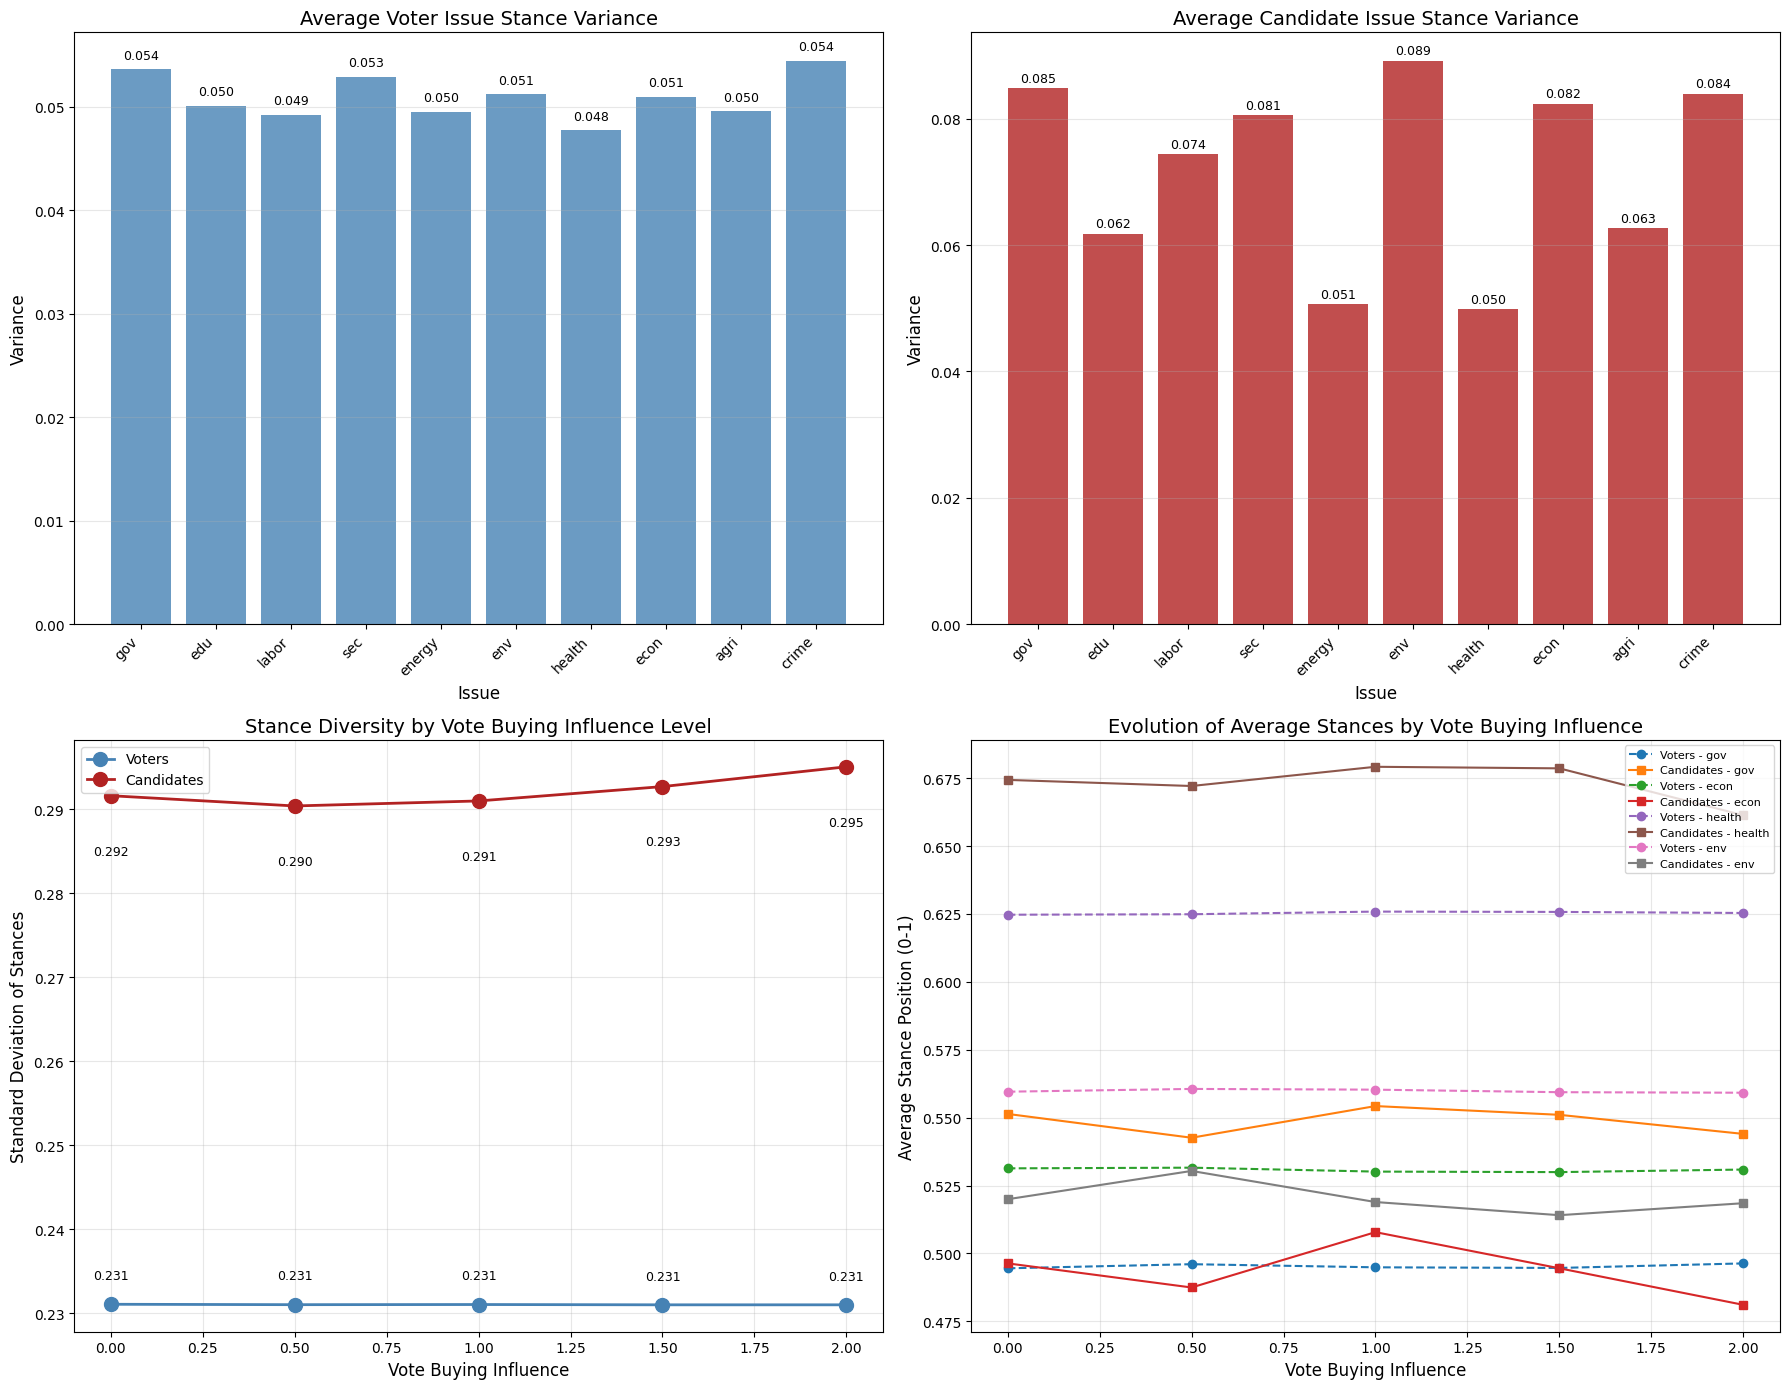

In [38]:
# Create a comprehensive visualization of stance variance and standard deviation

# Set up figure with 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Process issue variance data for analysis
# Extract unique issues from the variance dictionaries
sample_voter_var = eval(sim_df['Voter Issue Stance Variance'].iloc[0].replace('np.float64', 'float'))
sample_cand_var = eval(sim_df['Candidate Issue Stance Variance'].iloc[0].replace('np.float64', 'float'))
issues = list(sample_voter_var.keys())

# Calculate average variance for each issue
voter_issue_vars = {issue: [] for issue in issues}
candidate_issue_vars = {issue: [] for issue in issues}

# Sample rows for performance
sample_size = min(1000, len(sim_df))
sample_rows = sim_df.sample(sample_size)

for _, row in sample_rows.iterrows():
    voter_var_dict = eval(row['Voter Issue Stance Variance'].replace('np.float64', 'float'))
    cand_var_dict = eval(row['Candidate Issue Stance Variance'].replace('np.float64', 'float'))
    
    for issue in issues:
        voter_issue_vars[issue].append(voter_var_dict[issue])
        candidate_issue_vars[issue].append(cand_var_dict[issue])

# Calculate mean variance for each issue
voter_avg_vars = {issue: np.mean(values) for issue, values in voter_issue_vars.items()}
candidate_avg_vars = {issue: np.mean(values) for issue, values in candidate_issue_vars.items()}

# 1. Plot voter issue stance variance
axs[0, 0].bar(voter_avg_vars.keys(), voter_avg_vars.values(), color='steelblue', alpha=0.8)
axs[0, 0].set_title('Average Voter Issue Stance Variance', fontsize=14)
axs[0, 0].set_ylabel('Variance', fontsize=12)
axs[0, 0].set_xlabel('Issue', fontsize=12)
axs[0, 0].grid(axis='y', alpha=0.3)
axs[0, 0].set_xticklabels(voter_avg_vars.keys(), rotation=45, ha='right')

# Add value labels
for i, (issue, var) in enumerate(voter_avg_vars.items()):
    axs[0, 0].text(i, var + 0.001, f'{var:.3f}', ha='center', fontsize=9)

# 2. Plot candidate issue stance variance
axs[0, 1].bar(candidate_avg_vars.keys(), candidate_avg_vars.values(), color='firebrick', alpha=0.8)
axs[0, 1].set_title('Average Candidate Issue Stance Variance', fontsize=14)
axs[0, 1].set_ylabel('Variance', fontsize=12)
axs[0, 1].set_xlabel('Issue', fontsize=12)
axs[0, 1].grid(axis='y', alpha=0.3)
axs[0, 1].set_xticklabels(candidate_avg_vars.keys(), rotation=45, ha='right')

# Add value labels
for i, (issue, var) in enumerate(candidate_avg_vars.items()):
    axs[0, 1].text(i, var + 0.001, f'{var:.3f}', ha='center', fontsize=9)

# 3. Plot overall stance standard deviation for voters and candidates
# Group by influence level to see how vote buying affects stance diversity
influence_levels = sorted(sim_df['influence'].unique())
voter_stds = []
cand_stds = []

for influence in influence_levels:
    inf_data = sim_df[sim_df['influence'] == influence]
    voter_stds.append(inf_data['Overall Voter Stance StdDev'].mean())
    cand_stds.append(inf_data['Overall Candidate Stance StdDev'].mean())

# Plot standard deviations by influence level
axs[1, 0].plot(influence_levels, voter_stds, 'o-', linewidth=2, markersize=10, color='steelblue', label='Voters')
axs[1, 0].plot(influence_levels, cand_stds, 'o-', linewidth=2, markersize=10, color='firebrick', label='Candidates')
axs[1, 0].set_title('Stance Diversity by Vote Buying Influence Level', fontsize=14)
axs[1, 0].set_xlabel('Vote Buying Influence', fontsize=12)
axs[1, 0].set_ylabel('Standard Deviation of Stances', fontsize=12)
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# Add value labels for lines
for i, (v_std, c_std) in enumerate(zip(voter_stds, cand_stds)):
    axs[1, 0].text(influence_levels[i], v_std + 0.003, f'{v_std:.3f}', ha='center', fontsize=9)
    axs[1, 0].text(influence_levels[i], c_std - 0.007, f'{c_std:.3f}', ha='center', fontsize=9)

# 4. Plot evolution of average stances for a specific issue over influence levels
# Extract average stances from dictionaries
def extract_stances(stance_dict_str):
    return eval(stance_dict_str.replace('np.float64', 'float'))

# Select a couple of key issues to visualize
key_issues = ['gov', 'econ', 'health', 'env']
voter_issue_stances = {issue: [] for issue in key_issues}
candidate_issue_stances = {issue: [] for issue in key_issues}

for influence in influence_levels:
    inf_data = sim_df[sim_df['influence'] == influence].sample(min(100, len(sim_df[sim_df['influence'] == influence])))
    
    issue_v_values = {issue: [] for issue in key_issues}
    issue_c_values = {issue: [] for issue in key_issues}
    
    for _, row in inf_data.iterrows():
        v_stances = extract_stances(row['Avg Voter Issue Stances'])
        c_stances = extract_stances(row['Avg Candidate Issue Stances'])
        
        for issue in key_issues:
            issue_v_values[issue].append(v_stances[issue])
            issue_c_values[issue].append(c_stances[issue])
    
    for issue in key_issues:
        voter_issue_stances[issue].append(np.mean(issue_v_values[issue]))
        candidate_issue_stances[issue].append(np.mean(issue_c_values[issue]))

# Plot stance evolution for selected issues
for issue in key_issues:
    axs[1, 1].plot(influence_levels, voter_issue_stances[issue], 'o--', linewidth=1.5, markersize=6, label=f'Voters - {issue}')
    axs[1, 1].plot(influence_levels, candidate_issue_stances[issue], 's-', linewidth=1.5, markersize=6, label=f'Candidates - {issue}')

axs[1, 1].set_title('Evolution of Average Stances by Vote Buying Influence', fontsize=14)
axs[1, 1].set_xlabel('Vote Buying Influence', fontsize=12)
axs[1, 1].set_ylabel('Average Stance Position (0-1)', fontsize=12)
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend(fontsize=8)

plt.tight_layout()

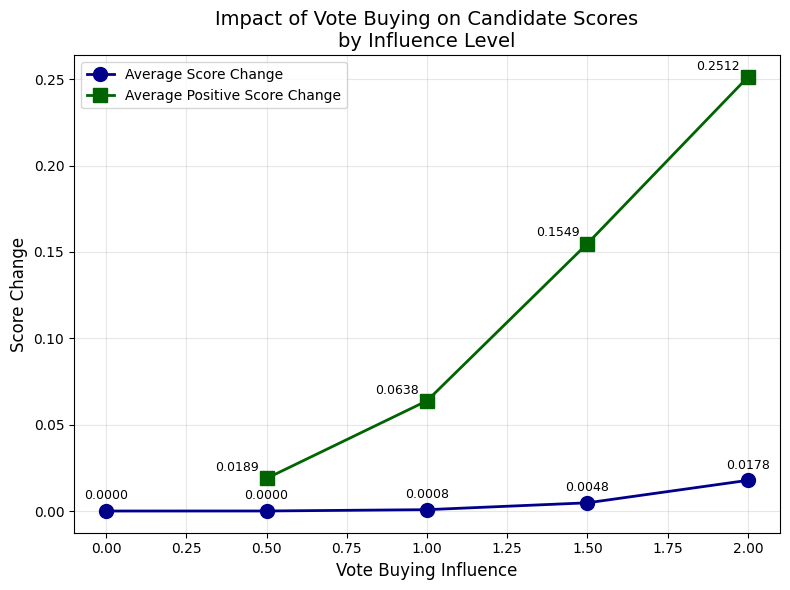

In [82]:
# 1. Average score change due to vote buying by influence level
plt.figure(figsize=(8, 6))
plt.plot(influence_levels, avg_score_changes, 'o-', linewidth=2, markersize=10, 
         color='darkblue', label='Average Score Change')
plt.plot(influence_levels, avg_positive_changes, 's-', linewidth=2, markersize=10, 
         color='darkgreen', label='Average Positive Score Change')
plt.title('Impact of Vote Buying on Candidate Scores\nby Influence Level', fontsize=14)
plt.xlabel('Vote Buying Influence', fontsize=12)
plt.ylabel('Score Change', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Add value labels
for i, (avg, pos) in enumerate(zip(avg_score_changes, avg_positive_changes)):
    plt.text(influence_levels[i], avg + 0.005, f'{avg:.4f}', ha='center', va='bottom', fontsize=9)
    plt.text(influence_levels[i] - 0.025, pos + 0.01, f'{pos:.4f}', ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

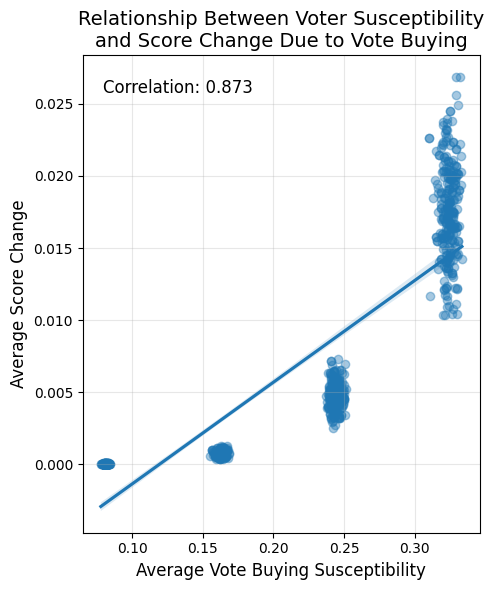

In [87]:
# 4. Relationship between susceptibility and score change
plt.figure(figsize=(5, 6))
sns.regplot(x='Avg Vote Buying Susceptibility', y='Avg Score Change Due to Vote Buying',
            data=vb_data.sample(1000), scatter_kws={'alpha': 0.4})
plt.title('Relationship Between Voter Susceptibility\nand Score Change Due to Vote Buying', fontsize=14)
plt.xlabel('Average Vote Buying Susceptibility', fontsize=12)
plt.ylabel('Average Score Change', fontsize=12)
plt.grid(alpha=0.3)

# Calculate correlation
corr = vb_data['Avg Vote Buying Susceptibility'].corr(vb_data['Avg Score Change Due to Vote Buying'])
plt.text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.show()


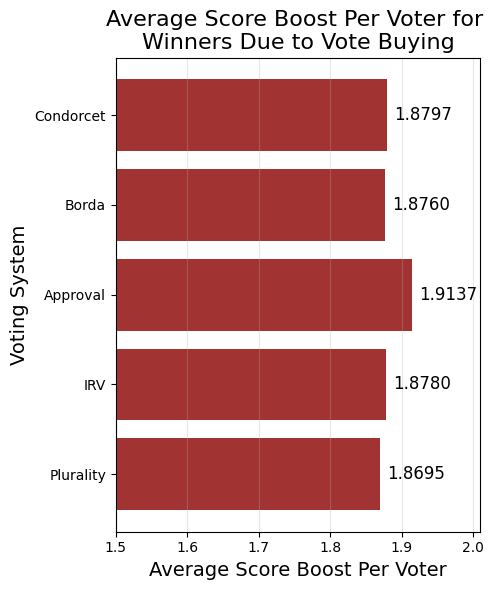

In [135]:
# Additional analysis: Visualize the average score boost per voter due to vote buying
plt.figure(figsize=(5, 6))

# Define the total number of voters
num_voters = 1000  # Replace 1000 with the actual number of voters in your simulation

# Convert efficiency to actual average score boost values per voter
boost_values_per_voter = {system: (ratio * 1000) / num_voters / 1000 for system, ratio in boost_ratio.items()}  # Assuming ratio is in thousands

# Create a horizontal bar chart for better readability
plt.barh(list(boost_values_per_voter.keys()), list(boost_values_per_voter.values()), color='darkred', alpha=0.8)
plt.title('Average Score Boost Per Voter for \nWinners Due to Vote Buying', fontsize=16)
plt.xlabel('Average Score Boost Per Voter', fontsize=14)
plt.ylabel('Voting System', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add value labels to the bars
for i, (system, value) in enumerate(boost_values_per_voter.items()):
    plt.text(value + 0.01, i, f'{value:.4f}', va='center', fontsize=12)

plt.xlim(1.5, None)  # Start x-axis at 1
plt.subplots_adjust(right=1.95)  # Add padding to the right
plt.tight_layout()
plt.show()

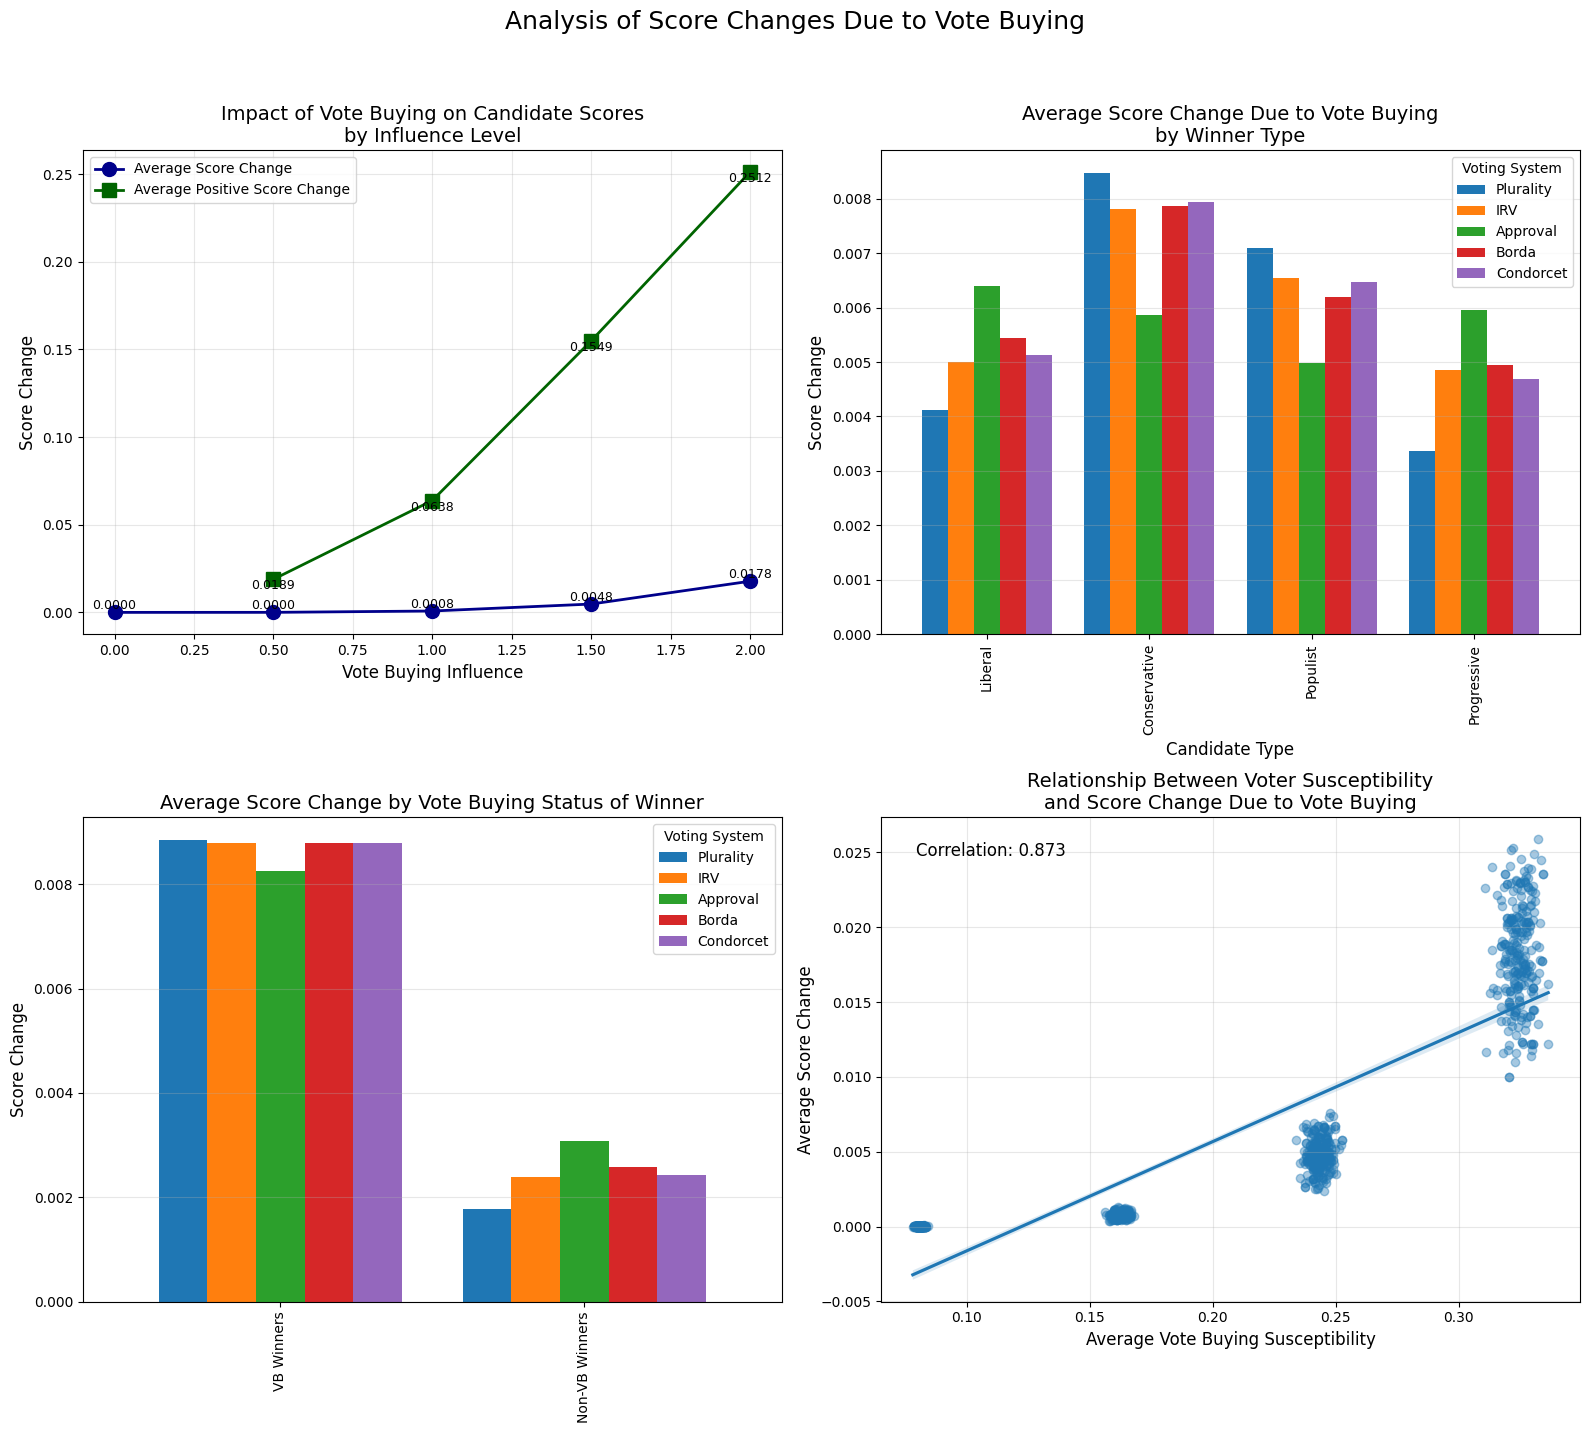

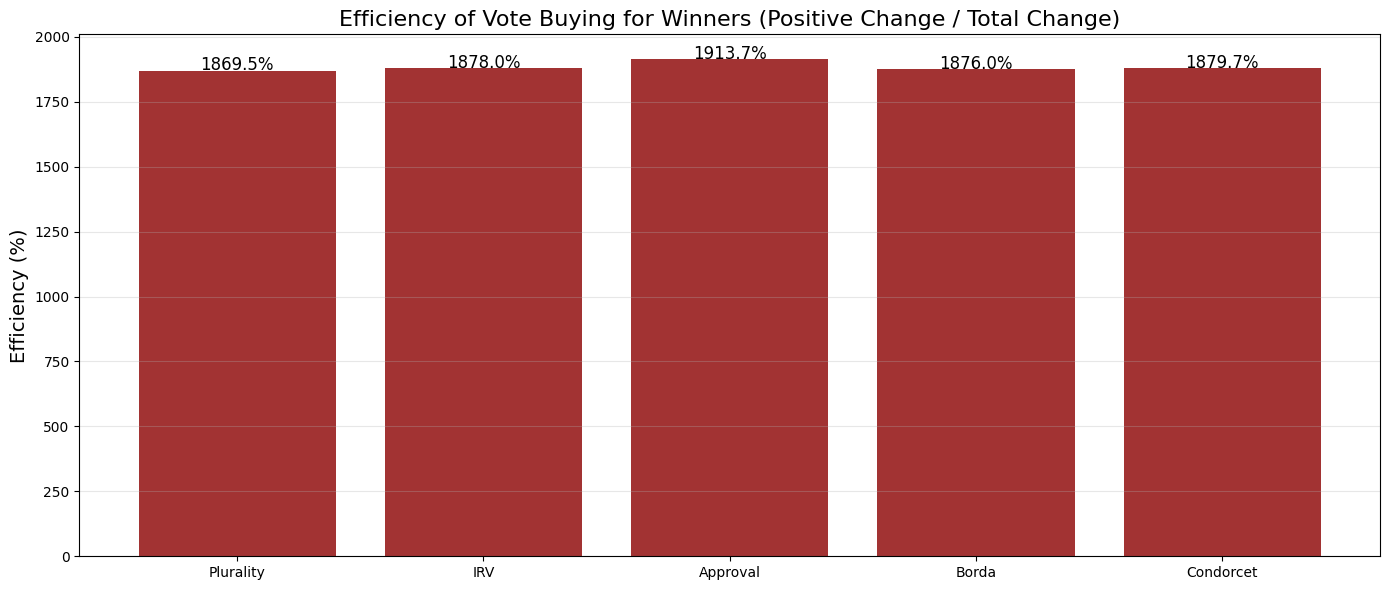

In [ ]:
# 2. Analyze score changes by winner type and voting system
plt.figure(figsize=(8, 6))
score_type_df.plot(kind='bar', width=0.8)
plt.title('Average Score Change Due to Vote Buying\nby Winner Type', fontsize=14)
plt.ylabel('Score Change', fontsize=12)
plt.xlabel('Candidate Type', fontsize=12)
plt.legend(title='Voting System')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Compare score changes for vote-buying vs non-vote-buying winners
plt.figure(figsize=(8, 6))
score_by_vb_status.plot(kind='bar', width=0.8)
plt.title('Average Score Change by Vote Buying Status of Winner', fontsize=14)
plt.ylabel('Score Change', fontsize=12)
plt.legend(title='Voting System')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 30000x1000 with 0 Axes>

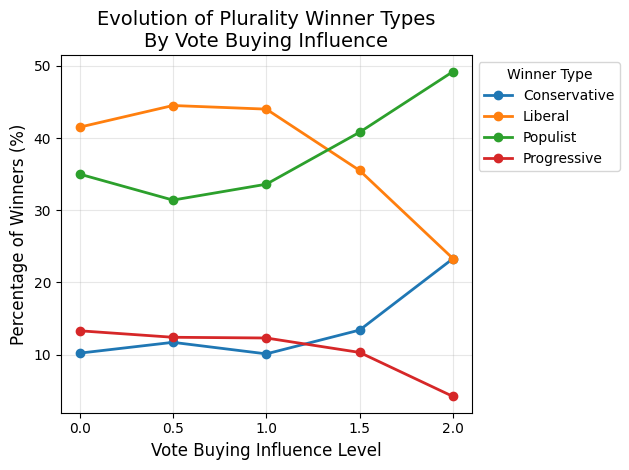

In [112]:
# Plot 2: Evolution of winner types by influence level for Plurality
plt.figure(figsize=(300, 10))  # Adjust the height to better fit the content
winner_types_evolution.plot(marker='o', linewidth=2)
plt.title(f'Evolution of {system_to_analyze} Winner Types\nBy Vote Buying Influence', fontsize=14)
plt.xlabel('Vote Buying Influence Level', fontsize=12)
plt.ylabel('Percentage of Winners (%)', fontsize=12)
plt.xticks(influence_levels)
plt.grid(True, alpha=0.3)
plt.legend(title='Winner Type', loc='upper left', bbox_to_anchor=(1, 1))  # Adjust legend position
plt.tight_layout()  # Ensure the layout adjusts to the figsize
plt.show()


<Figure size 800x600 with 0 Axes>

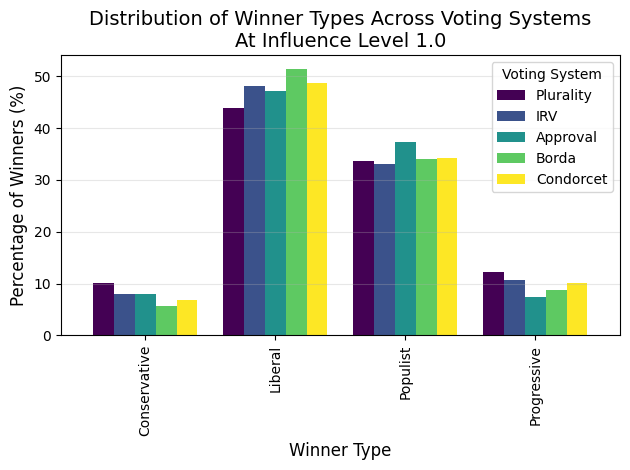

<Figure size 800x600 with 0 Axes>

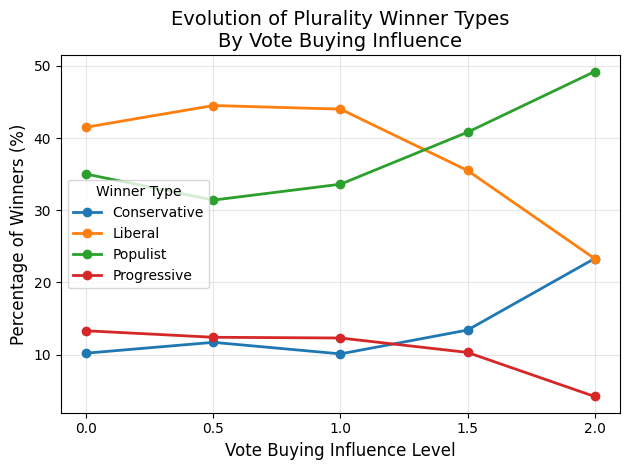

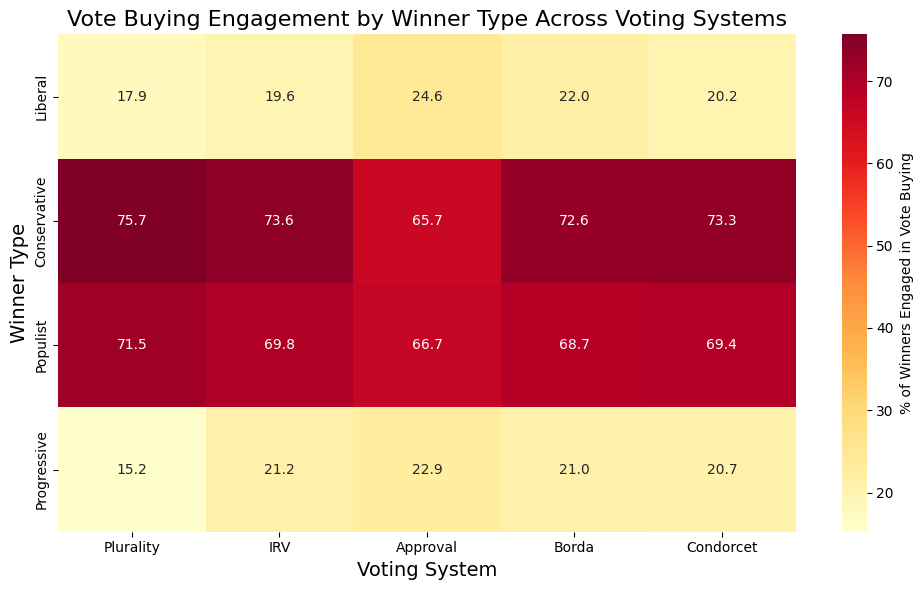

In [ ]:
# Plot 1: Winner type distribution across voting systems at moderate influence
plt.figure(figsize=(8, 6))
winner_types_inf_df.plot(kind='bar', stacked=False, width=0.8, colormap='viridis')
plt.title(f'Distribution of Winner Types Across Voting Systems\nAt Influence Level {influence_level}', fontsize=14)
plt.ylabel('Percentage of Winners (%)', fontsize=12)
plt.xlabel('Winner Type', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Voting System')
plt.tight_layout()
plt.show()


# Plot 3: Vote buying engagement by winner type across voting systems
plt.figure(figsize=(10, 6))
sns.heatmap(vb_type_matrix, annot=True, cmap='YlOrRd', fmt='.1f',
            cbar_kws={'label': '% of Winners Engaged in Vote Buying'})
plt.title('Vote Buying Engagement by Winner Type Across Voting Systems', fontsize=16)
plt.ylabel('Winner Type', fontsize=14)
plt.xlabel('Voting System', fontsize=14)
plt.tight_layout()
plt.show()


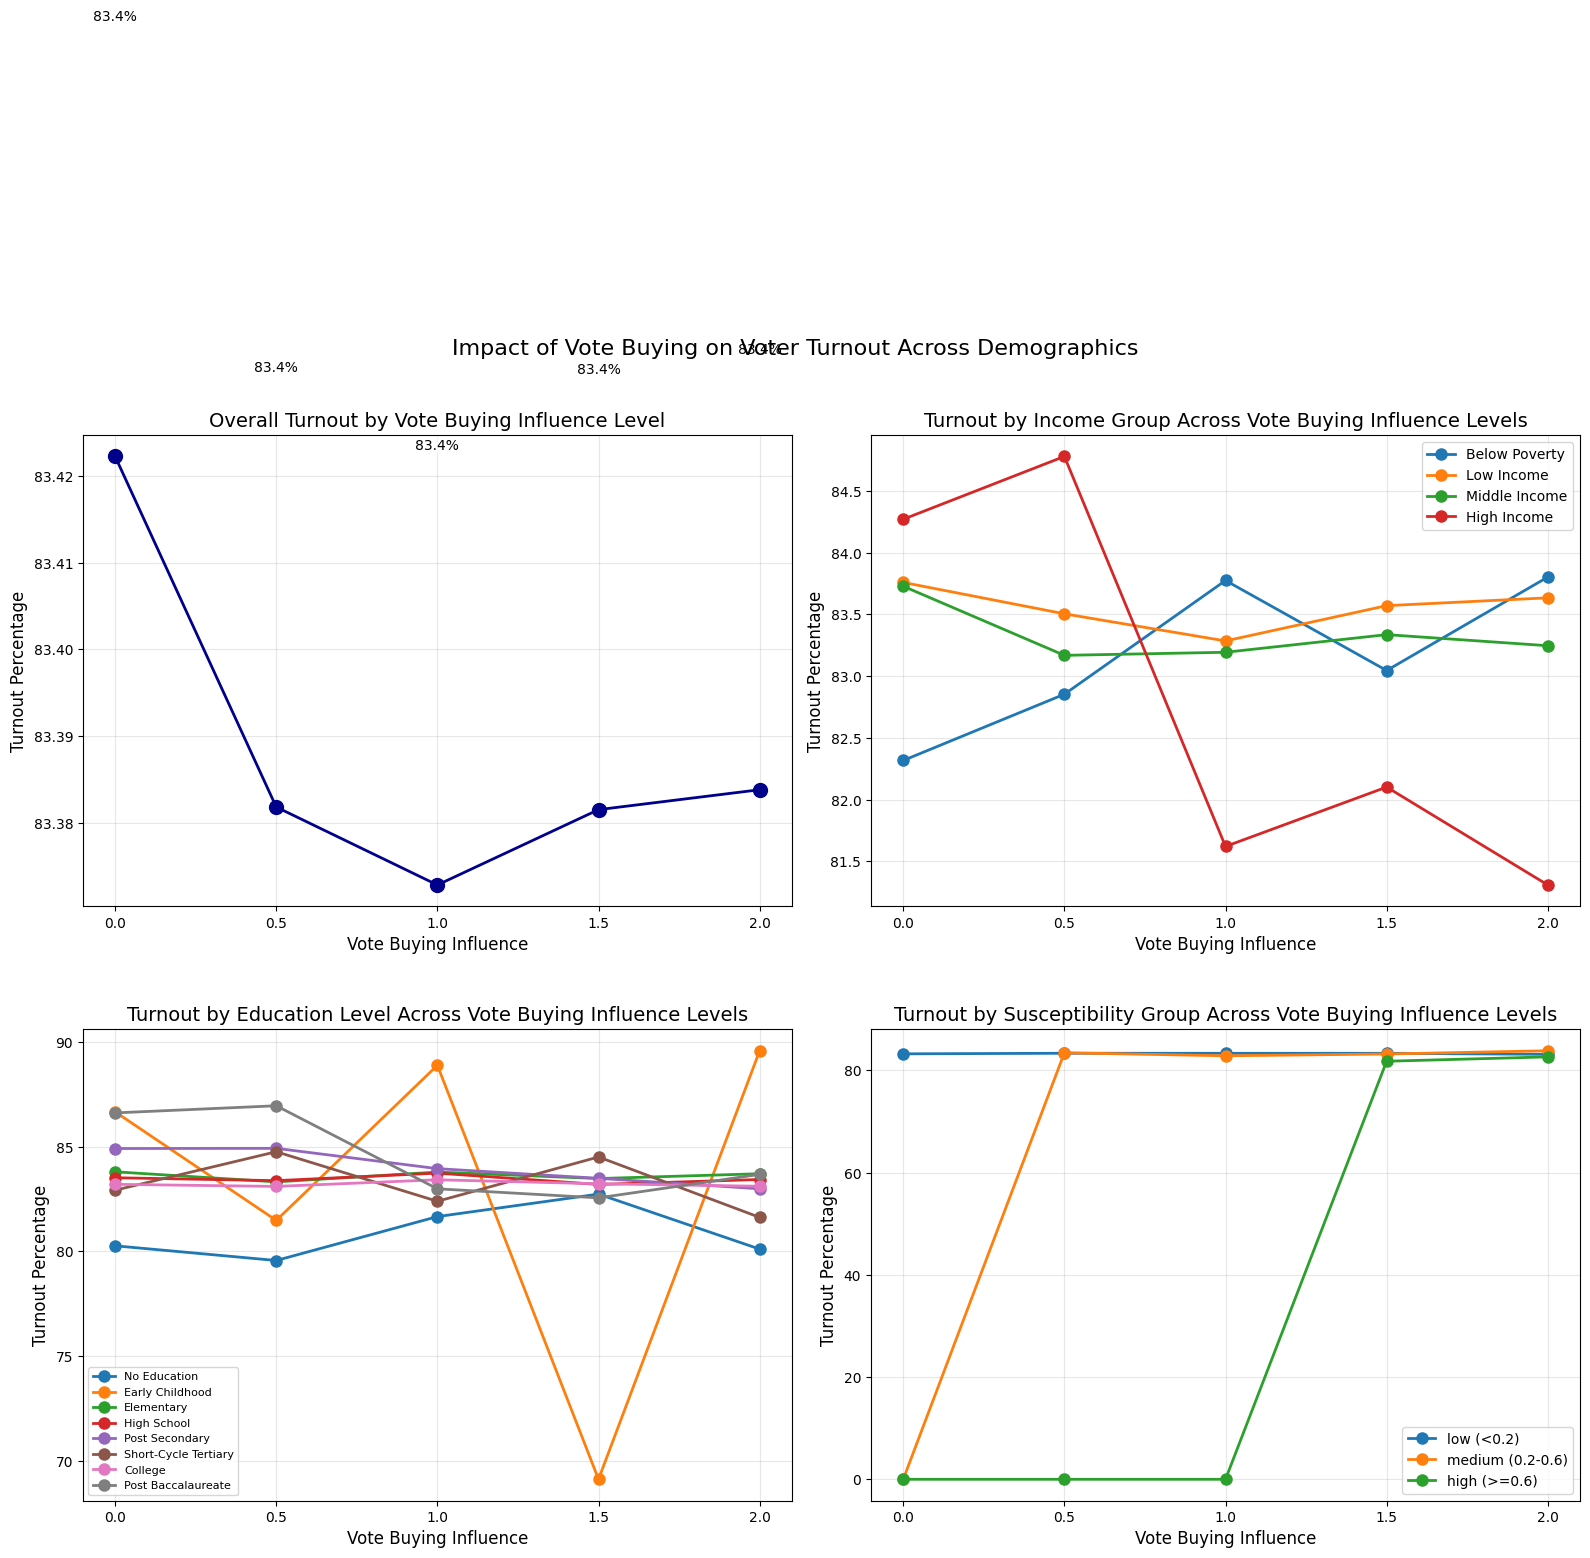

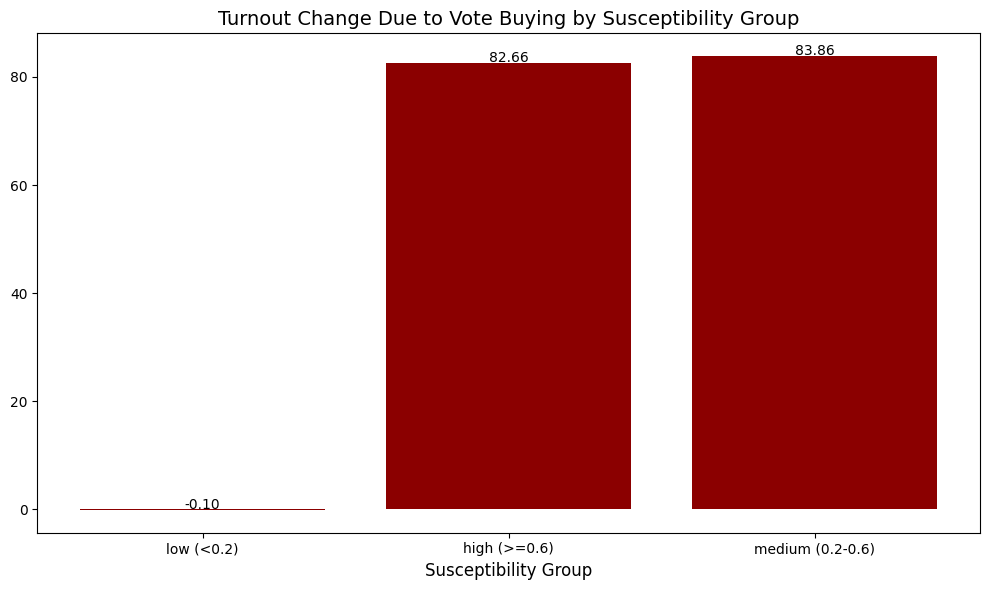

In [55]:
# Analyze how vote buying influence affects overall turnout and turnout by demographics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set up figure with 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Plot overall turnout by influence level
influence_levels = sorted(sim_df['influence'].unique())
turnout_by_influence = []

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence]
    turnout_by_influence.append(subset['Turnout Percentage'].mean())

# Create line plot for overall turnout
axs[0, 0].plot(influence_levels, turnout_by_influence, 'o-', linewidth=2, 
              markersize=10, color='darkblue')
axs[0, 0].set_title('Overall Turnout by Vote Buying Influence Level', fontsize=14)
axs[0, 0].set_xlabel('Vote Buying Influence', fontsize=12)
axs[0, 0].set_ylabel('Turnout Percentage', fontsize=12)
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].set_xticks(influence_levels)

# Add value labels with improved positioning and formatting
for i, v in enumerate(turnout_by_influence):
    axs[0, 0].text(influence_levels[i], v + 0.05, f'{v:.1f}%', 
                   ha='center', va='bottom', fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# 2. Analyze turnout by income group across influence levels
# Process dictionary data for income groups
income_groups = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
income_labels = ['Below Poverty', 'Low Income', 'Middle Income', 'High Income']
turnout_by_income_influence = {group: [] for group in income_groups}

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence].sample(min(100, len(sim_df[sim_df['influence'] == influence])))
    
    # Extract turnout data from dictionaries
    for group in income_groups:
        group_turnout = []
        for _, row in subset.iterrows():
            turnout_dict = eval(row['Turnout by Income'].replace('np.float64', 'float'))
            group_turnout.append(turnout_dict.get(group, 0))  # Use 0 if key not found
        turnout_by_income_influence[group].append(np.mean(group_turnout))

# Plot turnout by income
for i, group in enumerate(income_groups):
    axs[0, 1].plot(influence_levels, turnout_by_income_influence[group], 'o-', 
                  linewidth=2, markersize=8, label=income_labels[i])

axs[0, 1].set_title('Turnout by Income Group Across Vote Buying Influence Levels', fontsize=14)
axs[0, 1].set_xlabel('Vote Buying Influence', fontsize=12)
axs[0, 1].set_ylabel('Turnout Percentage', fontsize=12)
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].set_xticks(influence_levels)
axs[0, 1].legend()

# 3. Analyze turnout by education level across influence levels
# Sample one row to get education groups
sample_row = sim_df.iloc[0]
education_dict = eval(sample_row['Turnout by Education'].replace('np.float64', 'float'))
edu_groups = list(education_dict.keys())
edu_labels = [group.replace('_', ' ').title() for group in edu_groups]
turnout_by_edu_influence = {group: [] for group in edu_groups}

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence].sample(min(100, len(sim_df[sim_df['influence'] == influence])))
    
    # Extract turnout data from dictionaries
    for group in edu_groups:
        group_turnout = []
        for _, row in subset.iterrows():
            turnout_dict = eval(row['Turnout by Education'].replace('np.float64', 'float'))
            if group in turnout_dict:
                group_turnout.append(turnout_dict[group])
        turnout_by_edu_influence[group].append(np.mean(group_turnout))

# Plot turnout by education
for i, group in enumerate(edu_groups):
    axs[1, 0].plot(influence_levels, turnout_by_edu_influence[group], 'o-', 
                  linewidth=2, markersize=8, label=edu_labels[i])

axs[1, 0].set_title('Turnout by Education Level Across Vote Buying Influence Levels', fontsize=14)
axs[1, 0].set_xlabel('Vote Buying Influence', fontsize=12)
axs[1, 0].set_ylabel('Turnout Percentage', fontsize=12)
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].set_xticks(influence_levels)
axs[1, 0].legend(fontsize=8)

# 4. Analyze turnout by susceptibility group across influence levels
# Process dictionary data for susceptibility groups
suscept_dict = eval(sample_row['Turnout by Susceptibility Group'].replace('np.float64', 'float'))
suscept_groups = list(suscept_dict.keys())
turnout_by_suscept_influence = {group: [] for group in suscept_groups}

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence].sample(min(100, len(sim_df[sim_df['influence'] == influence])))
    
    # Extract turnout data from dictionaries
    for group in suscept_groups:
        group_turnout = []
        for _, row in subset.iterrows():
            turnout_dict = eval(row['Turnout by Susceptibility Group'].replace('np.float64', 'float'))
            group_turnout.append(turnout_dict[group])
        turnout_by_suscept_influence[group].append(np.mean(group_turnout))

# Plot turnout by susceptibility group
for group in suscept_groups:
    axs[1, 1].plot(influence_levels, turnout_by_suscept_influence[group], 'o-', 
                  linewidth=2, markersize=8, label=group)

axs[1, 1].set_title('Turnout by Susceptibility Group Across Vote Buying Influence Levels', fontsize=14)
axs[1, 1].set_xlabel('Vote Buying Influence', fontsize=12)
axs[1, 1].set_ylabel('Turnout Percentage', fontsize=12)
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].set_xticks(influence_levels)
axs[1, 1].legend()

plt.tight_layout()
plt.suptitle('Impact of Vote Buying on Voter Turnout Across Demographics', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.94)
plt.show()

# Create additional plot to show turnout change by susceptibility
plt.figure(figsize=(10, 6))

# Calculate turnout change from baseline (no vote buying) to high influence
suscept_turnout_change = {}
for group in suscept_groups:
    baseline = turnout_by_suscept_influence[group][0]  # influence = 0
    highest = turnout_by_suscept_influence[group][-1]  # highest influence
    suscept_turnout_change[group] = highest - baseline

# Sort groups by turnout change
sorted_groups = sorted(suscept_groups, key=lambda x: suscept_turnout_change[x])

# Plot turnout change by susceptibility group
plt.bar(sorted_groups, [suscept_turnout_change[group] for group in sorted_groups], color='darkred')
plt.title('Turnout Change Due to Vote Buying by Susceptibility Group', fontsize=14)
plt.xlabel('Susceptibility Group', fontsize=12)
# Add value labels
for i, group in enumerate(sorted_groups):
    plt.text(i, suscept_turnout_change[group] + 0.1, 
             f'{suscept_turnout_change[group]:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Create a new separate figure for the scatter plot using the provided array data
plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y, c=y>0, cmap='viridis', alpha=0.7)
plt.colorbar(label='Vote Buying Influence')
plt.xlabel('Agent Susceptibility Score', fontsize=12)
plt.ylabel('Vote Buying Effect', fontsize=12)
plt.title('Vote Buying Effect by Agent Susceptibility', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

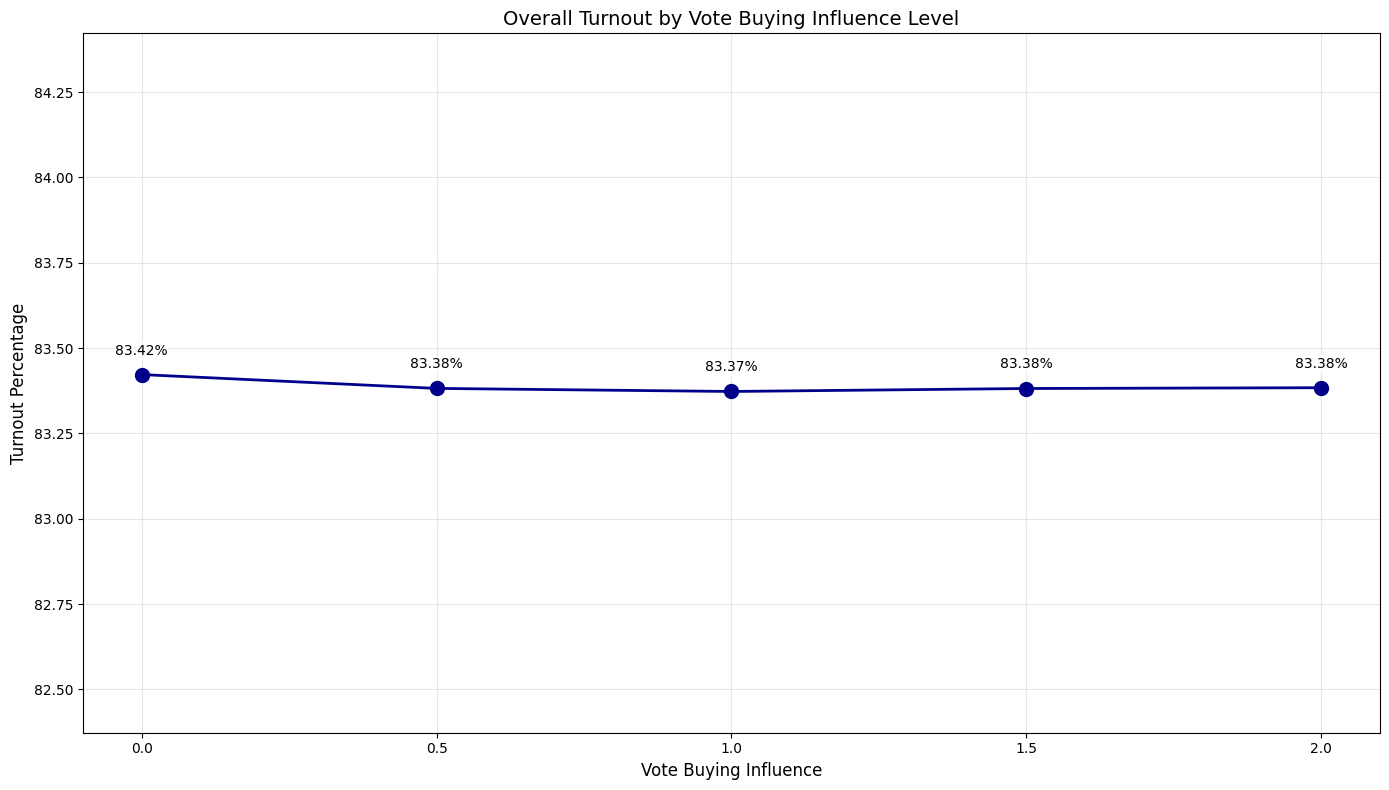

In [73]:
plt.figure(figsize=(14, 8))

# 1. Plot overall turnout by influence level
influence_levels = sorted(sim_df['influence'].unique())
turnout_by_influence = []

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence]
    turnout_by_influence.append(subset['Turnout Percentage'].mean())

# Create line plot for overall turnout
plt.plot(influence_levels, turnout_by_influence, 'o-', linewidth=2, 
         markersize=10, color='darkblue')
plt.title('Overall Turnout by Vote Buying Influence Level', fontsize=14)
plt.xlabel('Vote Buying Influence', fontsize=12)
plt.ylabel('Turnout Percentage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(influence_levels)

# Add value labels with improved positioning and formatting
for i, v in enumerate(turnout_by_influence):
    plt.text(influence_levels[i], v + 0.05, f'{v:.2f}%', 
             ha='center', va='bottom', fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Adjust ylim to add padding at the top
plt.ylim(min(turnout_by_influence) - 1, max(turnout_by_influence) + 1)

plt.tight_layout()
plt.show()






C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2519937483.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 1].set_xticklabels(income_labels, rotation=45, ha='right')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2519937483.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_xticklabels(education_labels, rotation=45, ha='right')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_10756\2519937483.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_xticklabels(income_labels, rotation=45, ha='right')


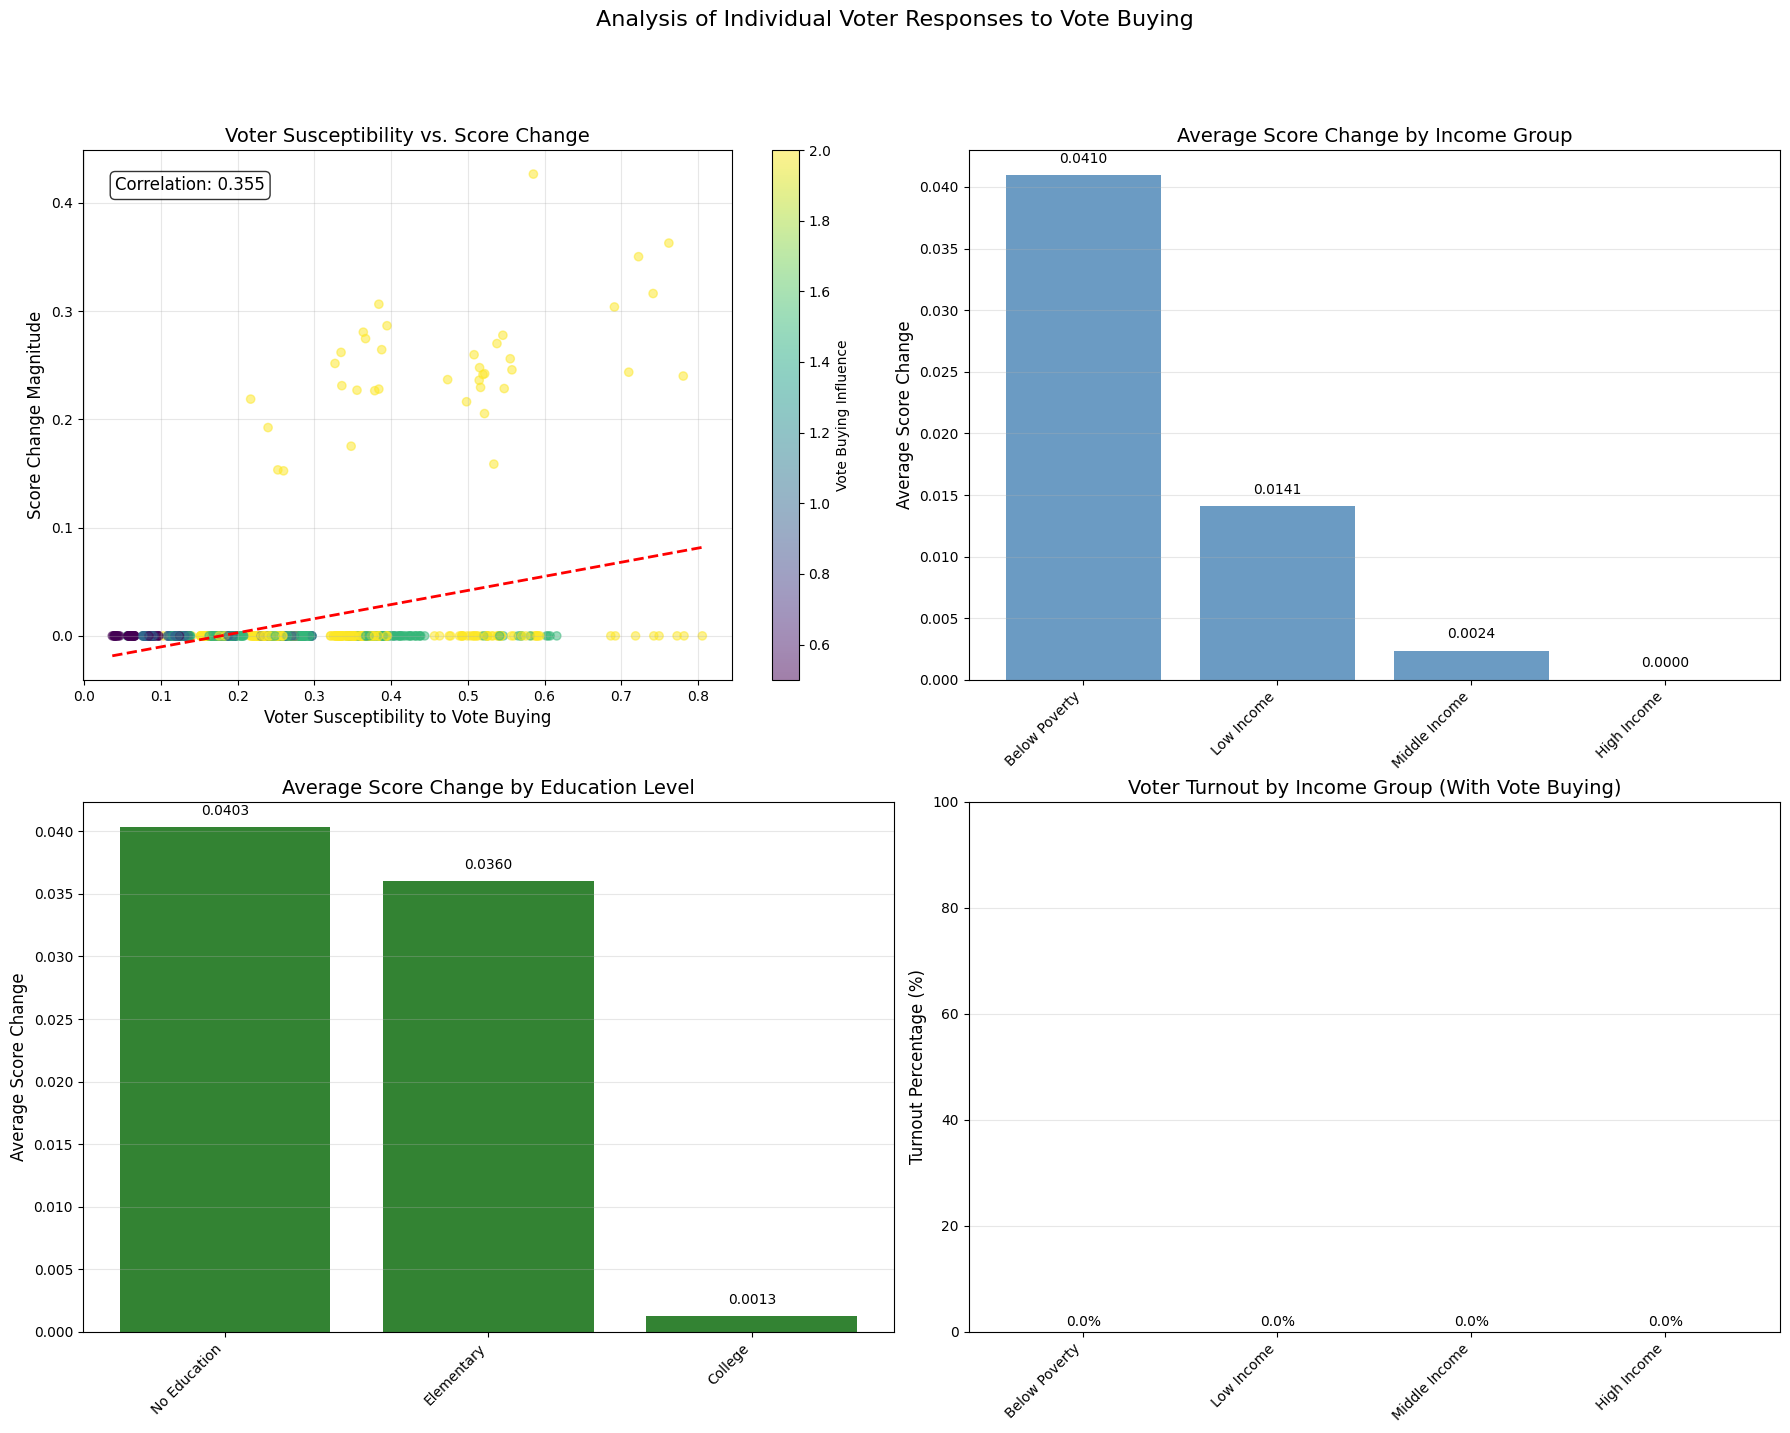

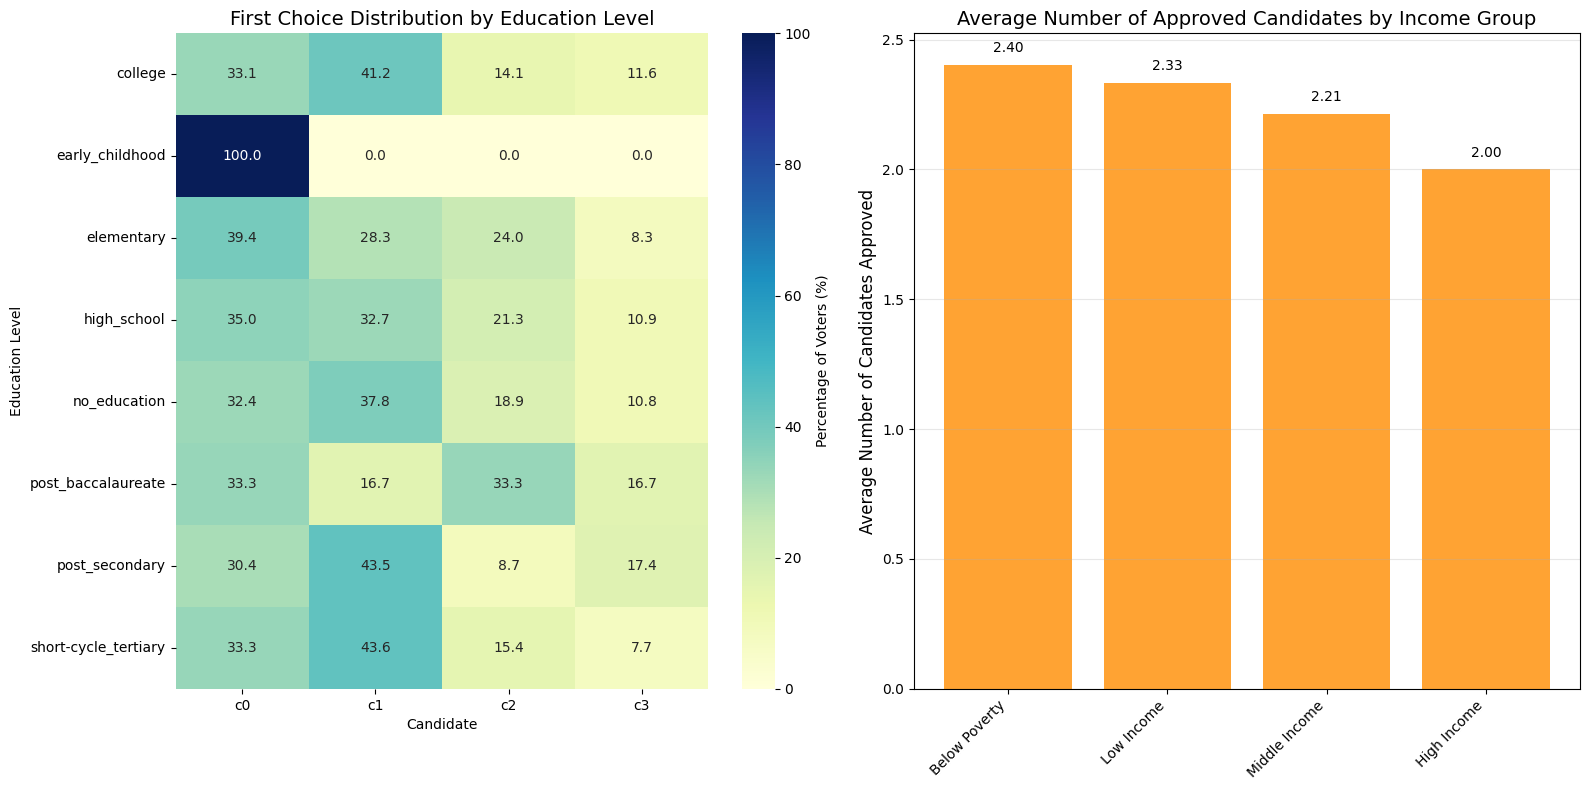

In [53]:
# Create visualizations for individual voter score changes and demographic patterns
# Set up figure with 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Import necessary libraries if not already imported
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import ast

# 1. Relationship between individual voter susceptibility and score change
# Take a smaller sample and only include rows where needed
sample_size = 1000  # Reduced sample size
sample_voters = voter_df[(voter_df['AgentType'] == 'Voter') & (voter_df['influence'] > 0)].sample(sample_size)

# Calculate Individual Score Change - extract the magnitude of score changes
def extract_score_change_magnitude(score_change_str):
    try:
        score_dict = ast.literal_eval(score_change_str)
        # Get absolute sum of all changes
        return sum(abs(float(v)) for v in score_dict.values() if v != 0)
    except:
        return 0

# Apply the function to create the Individual Score Change column
sample_voters['Individual Score Change'] = sample_voters['Voter Score Change'].apply(extract_score_change_magnitude)

# Plot susceptibility vs score change - use more efficient scatter plot
scatter = axs[0, 0].scatter(sample_voters['Voter Susceptibility'], 
                 sample_voters['Individual Score Change'],
                 alpha=0.5, c=sample_voters['influence'], cmap='viridis')
plt.colorbar(scatter, ax=axs[0, 0], label='Vote Buying Influence')
axs[0, 0].set_title('Voter Susceptibility vs. Score Change', fontsize=14)
axs[0, 0].set_xlabel('Voter Susceptibility to Vote Buying', fontsize=12)
axs[0, 0].set_ylabel('Score Change Magnitude', fontsize=12)
axs[0, 0].grid(alpha=0.3)
# Only analyze data where vote buying happens - use more efficient filtering
vote_buying_df = voter_df[voter_df['influence'] > 0].copy()

# Calculate Individual Score Change for all vote_buying_df rows
vote_buying_df['Individual Score Change'] = vote_buying_df['Voter Score Change'].apply(extract_score_change_magnitude)
# Get x and y data for polynomial fit
x = sample_voters['Voter Susceptibility'].values
y = sample_voters['Individual Score Change'].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
axs[0, 0].plot(x_sorted, p(x_sorted), "r--", linewidth=2)

# Calculate correlation
corr = np.corrcoef(x, y)[0, 1]
axs[0, 0].text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=axs[0, 0].transAxes, 
              fontsize=12, verticalalignment='top', 
              bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# 2. Score changes by income groups - use more efficient aggregation
income_groups = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
income_labels = ['Below Poverty', 'Low Income', 'Middle Income', 'High Income']

# Use the already filtered vote_buying_df we created above
income_changes = vote_buying_df.groupby('Income Group')['Individual Score Change'].mean().reindex(income_groups)
bars1 = axs[0, 1].bar(income_labels, income_changes, color='steelblue', alpha=0.8)
axs[0, 1].set_title('Average Score Change by Income Group', fontsize=14)
axs[0, 1].set_ylabel('Average Score Change', fontsize=12)
axs[0, 1].set_xticklabels(income_labels, rotation=45, ha='right')
axs[0, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axs[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{height:.4f}', ha='center', fontsize=10)

# 3. Score changes by education level - more efficient approach
education_levels = ['no_education', 'elementary', 'lower_secondary', 
                   'upper_secondary', 'short_cycle_tertiary', 'college']
# Filter to only include levels that exist in the data
edu_changes = vote_buying_df.groupby('Education')['Individual Score Change'].mean()
education_levels = [level for level in education_levels if level in edu_changes.index]
edu_changes = edu_changes.reindex(education_levels)
education_labels = [level.replace('_', ' ').title() for level in education_levels]

# Plot education group score changes
bars2 = axs[1, 0].bar(education_labels, edu_changes, color='darkgreen', alpha=0.8)
axs[1, 0].set_title('Average Score Change by Education Level', fontsize=14)
axs[1, 0].set_ylabel('Average Score Change', fontsize=12)
axs[1, 0].set_xticklabels(education_labels, rotation=45, ha='right')
axs[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axs[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{height:.4f}', ha='center', fontsize=10)

# 4. Turnout by demographic under vote buying influence - use vectorized operations
# Calculate turnout percentage by income group
turnout_by_income = vote_buying_df.groupby('Income Group')['Voter Turned Out'].apply(
    lambda x: (x == 'True').mean() * 100).reindex(income_groups)

# Plot turnout percentage
bars3 = axs[1, 1].bar(income_labels, turnout_by_income, color='darkred', alpha=0.8)
axs[1, 1].set_title('Voter Turnout by Income Group (With Vote Buying)', fontsize=14)
axs[1, 1].set_ylabel('Turnout Percentage (%)', fontsize=12)
axs[1, 1].set_xticklabels(income_labels, rotation=45, ha='right')
axs[1, 1].grid(axis='y', alpha=0.3)
axs[1, 1].set_ylim(0, 100)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    axs[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Analysis of Individual Voter Responses to Vote Buying', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)

# Additional analysis: Voting patterns by demographic groups
# Use a separate figure to prevent memory issues
plt.figure(figsize=(16, 8))

# Extract first choice from ranked vote using vectorized operations where possible
def get_first_choice(ranked_vote_str):
    try:
        ranked_vote = eval(ranked_vote_str)
        return ranked_vote[0] if ranked_vote else None
    except:
        return None

def count_approvals(approval_scores_str, threshold=0.7):
    try:
        scores = eval(approval_scores_str)
        return sum(1 for score in scores.values() if score > threshold)
    except:
        return 0

# Take a smaller sample for pattern analysis
pattern_sample_size = min(2000, len(vote_buying_df))
pattern_sample = vote_buying_df.sample(pattern_sample_size)
pattern_sample['First Choice'] = pattern_sample['Voter Ranked Vote'].apply(get_first_choice)
pattern_sample['Approved Count'] = pattern_sample['Voter Approval Scores'].apply(
    lambda x: count_approvals(x, threshold=0.7))

# Left plot: First choice distribution by education - use more efficient cross-tabulation
first_choice_by_edu = pd.crosstab(pattern_sample['Education'], 
                                 pattern_sample['First Choice'],
                                 normalize='index') * 100

plt.subplot(1, 2, 1)
sns.heatmap(first_choice_by_edu, annot=True, fmt='.1f', cmap='YlGnBu',
           cbar_kws={'label': 'Percentage of Voters (%)'})
plt.title('First Choice Distribution by Education Level', fontsize=14)
plt.xlabel('Candidate')
plt.ylabel('Education Level')

# Right plot: Number of approved candidates by income group
approval_by_income = pattern_sample.groupby('Income Group')['Approved Count'].mean()
approval_by_income = approval_by_income.reindex(income_groups)

plt.subplot(1, 2, 2)
plt.bar(income_labels, approval_by_income, color='darkorange', alpha=0.8)
plt.title('Average Number of Approved Candidates by Income Group', fontsize=14)
plt.ylabel('Average Number of Candidates Approved', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(approval_by_income):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

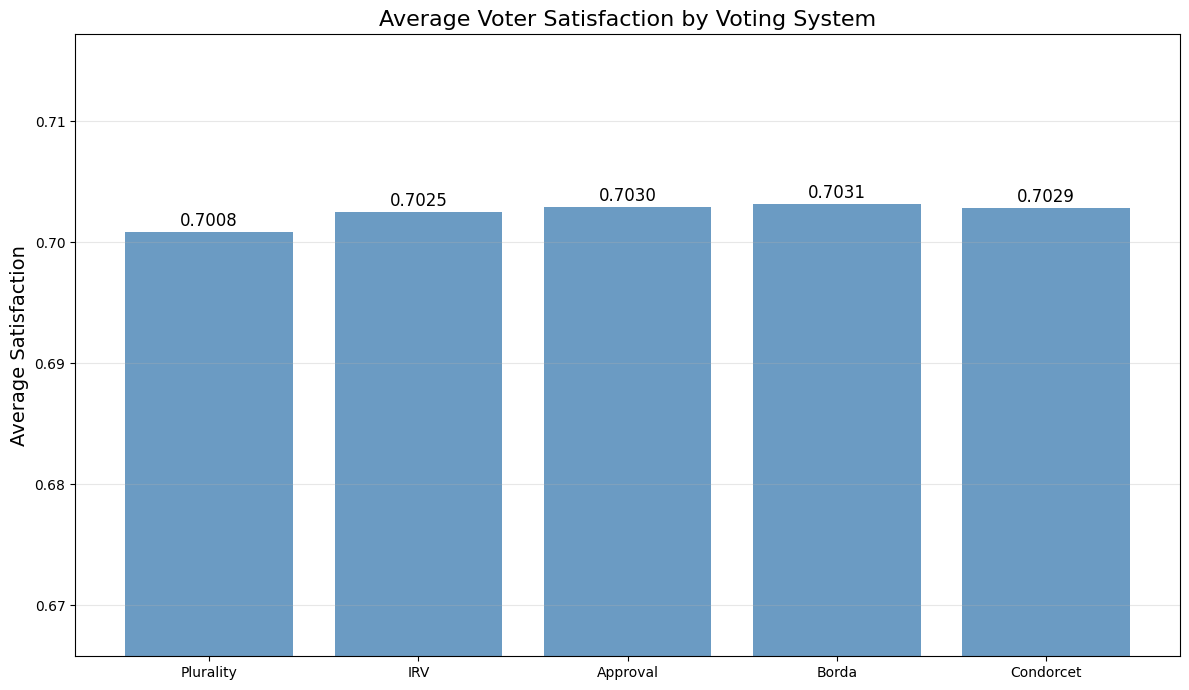

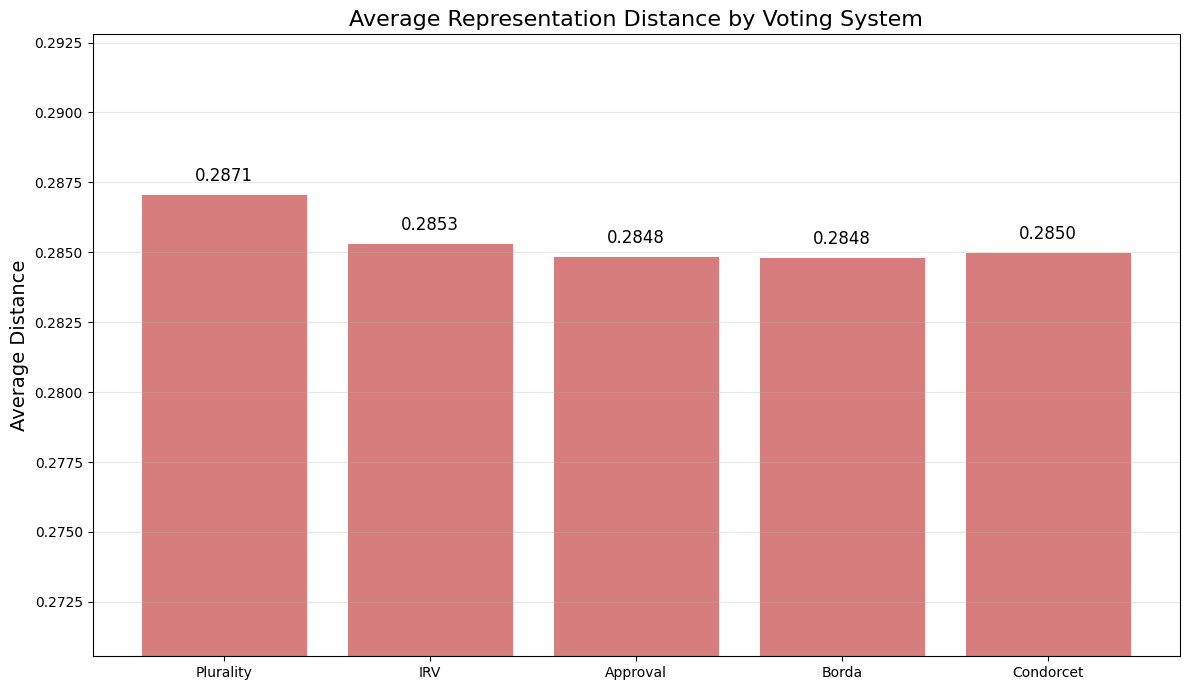

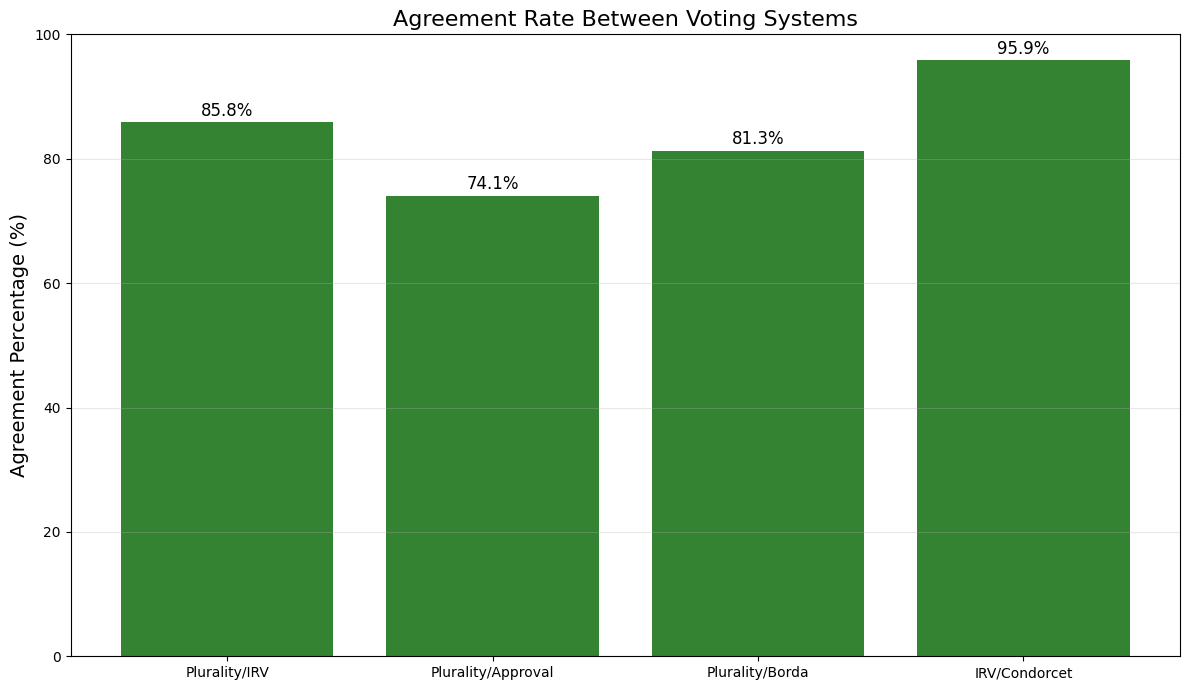

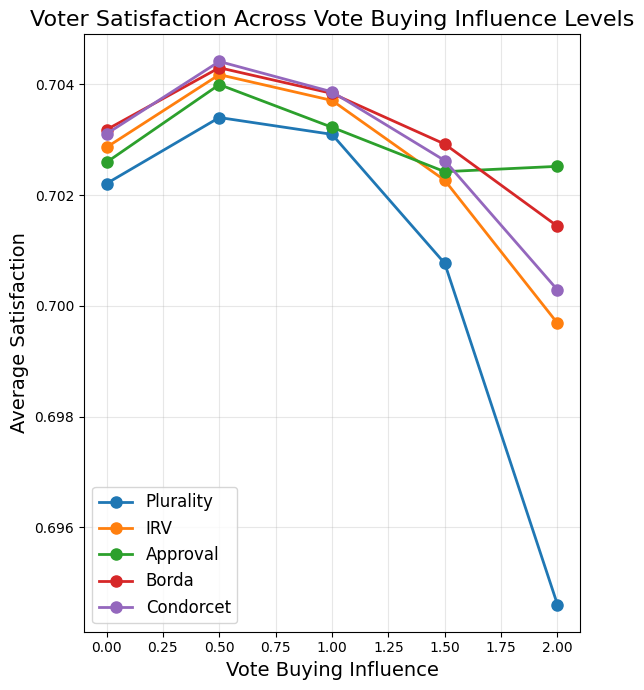

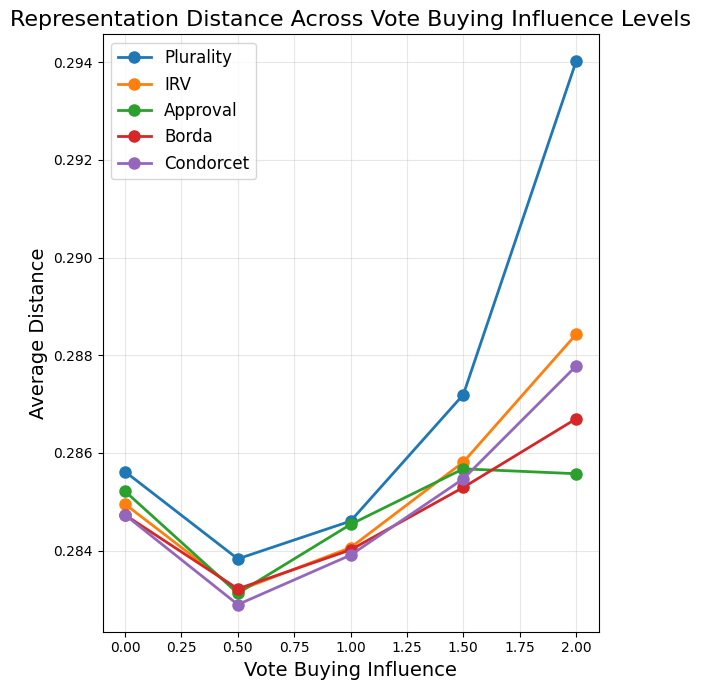

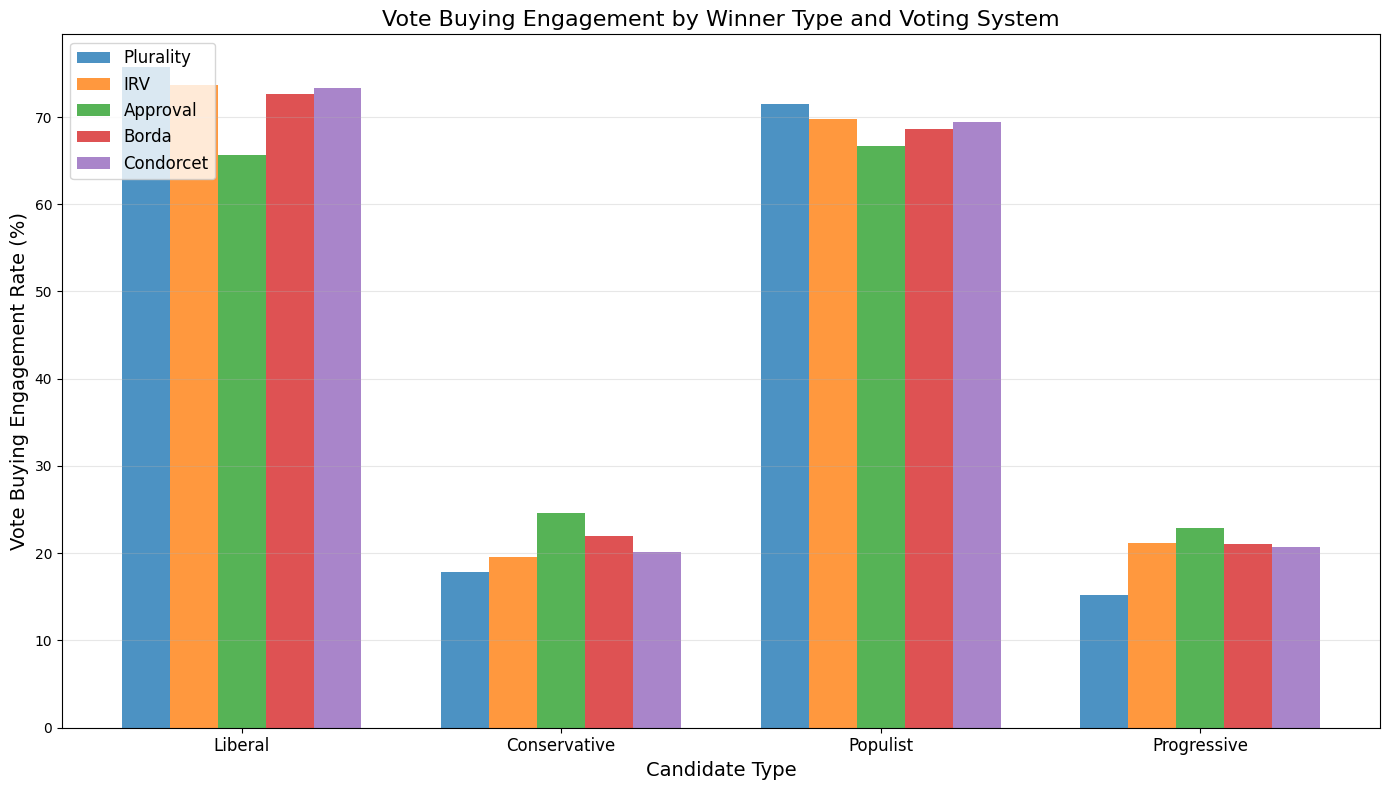

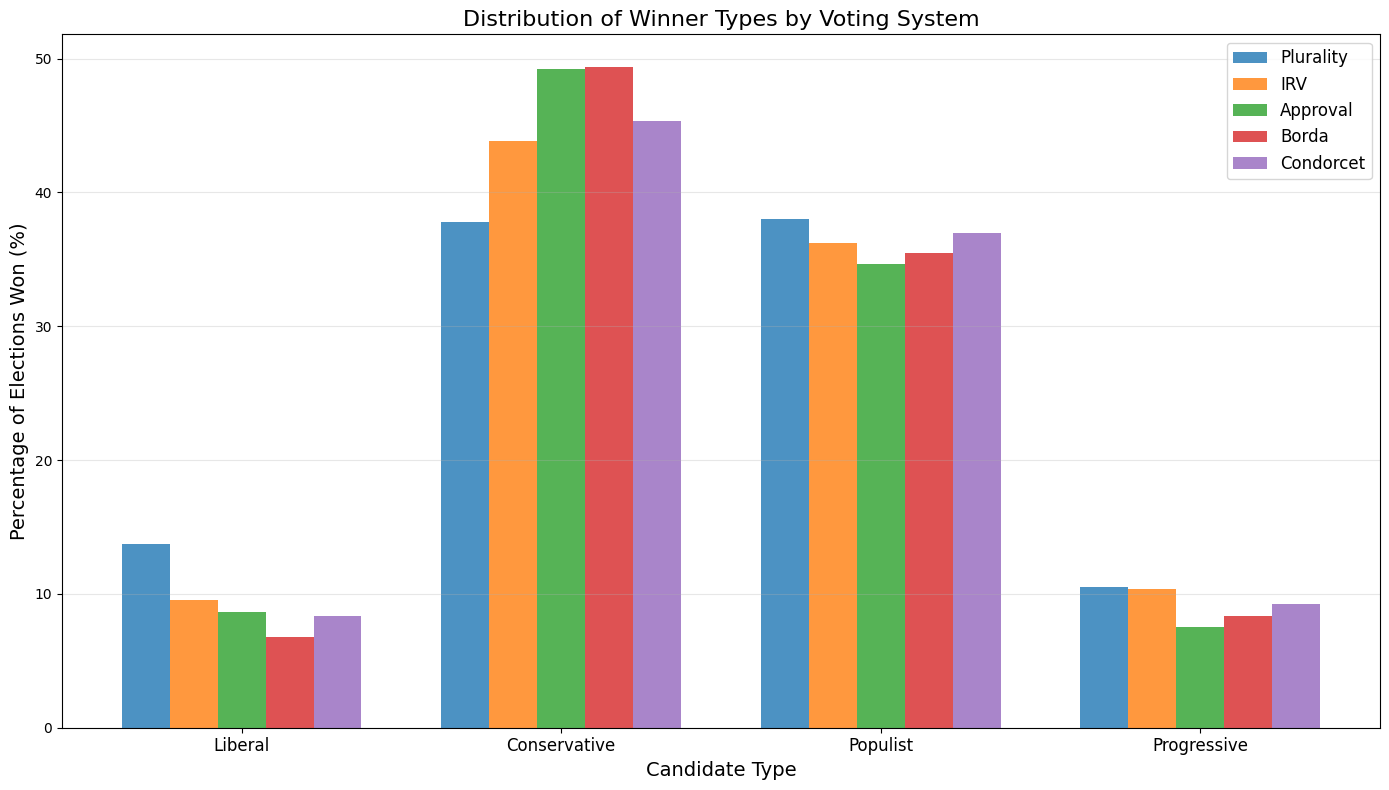

<Figure size 2000x1000 with 0 Axes>

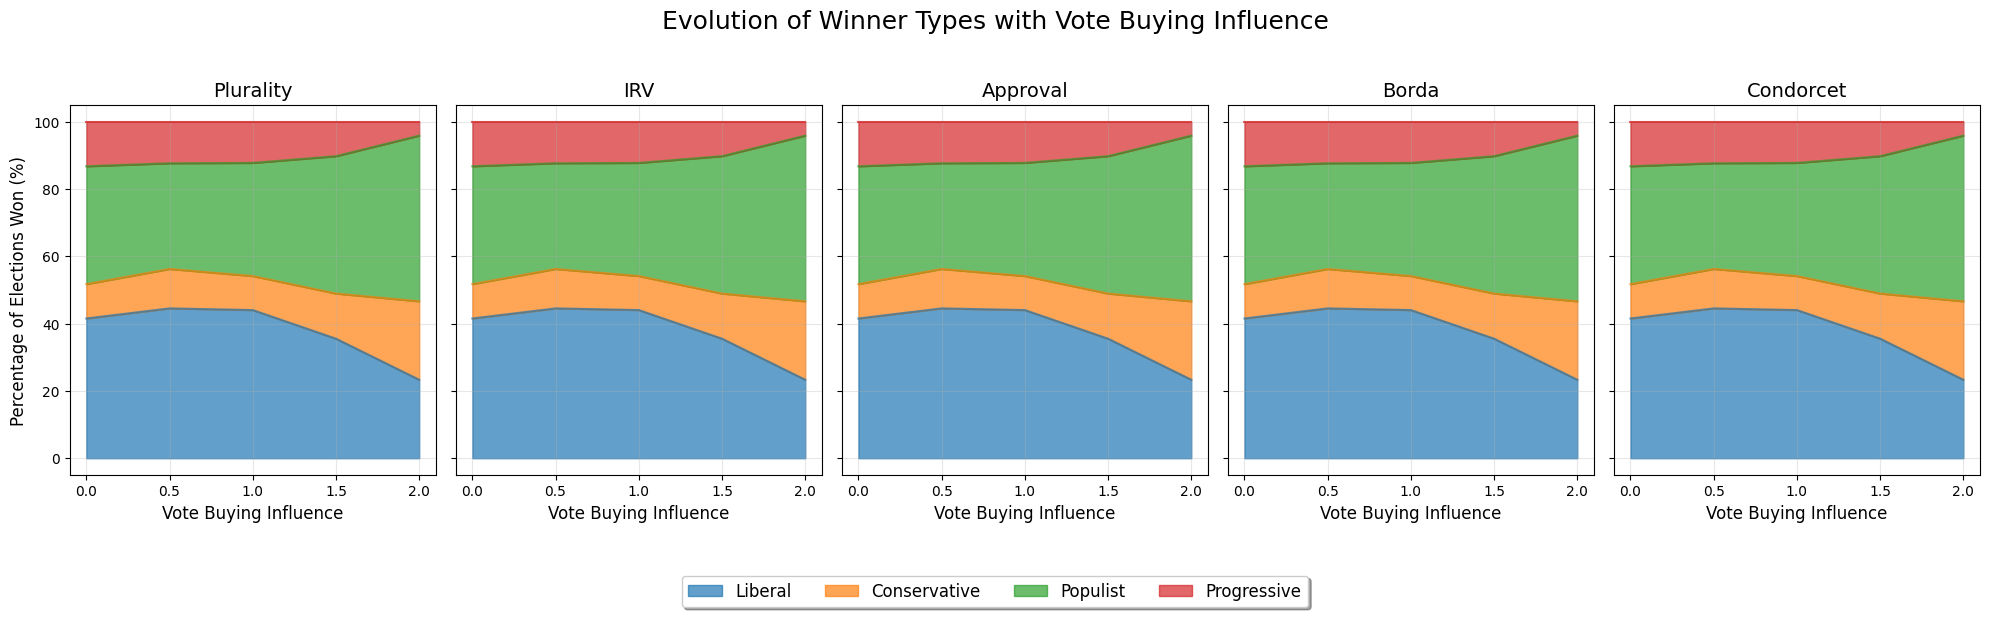

In [ ]:
# Create separate comprehensive visualizations comparing voting system performance

# Define voting systems for consistent ordering
voting_systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']

# 1. Plot average voter satisfaction by voting system
plt.figure(figsize=(12, 7))
satisfaction_data = []
for system in voting_systems:
    satisfaction_data.append(sim_df[f'{system} Satisfaction'].mean())
    
bars = plt.bar(voting_systems, satisfaction_data, color='steelblue', alpha=0.8)
plt.title('Average Voter Satisfaction by Voting System', fontsize=16)
plt.ylabel('Average Satisfaction', fontsize=14)
plt.ylim(min(satisfaction_data) * 0.95, max(satisfaction_data) * 1.02)
plt.grid(axis='y', alpha=0.3)

# Add value labels to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
            f'{height:.4f}', ha='center', fontsize=12)
            
plt.tight_layout()
plt.show()

# 2. Plot average representation distance by voting system
plt.figure(figsize=(12, 7))
distance_data = []
for system in voting_systems:
    distance_data.append(sim_df[f'{system} Distance'].mean())
    
bars = plt.bar(voting_systems, distance_data, color='indianred', alpha=0.8)
plt.title('Average Representation Distance by Voting System', fontsize=16)
plt.ylabel('Average Distance', fontsize=14)
plt.ylim(min(distance_data) * 0.95, max(distance_data) * 1.02)
plt.grid(axis='y', alpha=0.3)

# Add value labels to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
            f'{height:.4f}', ha='center', fontsize=12)
            
plt.tight_layout()
plt.show()

# 3. Plot agreement rates between voting systems
plt.figure(figsize=(12, 7))
# Define pairs to analyze
system_pairs = [
    ('Plurality/IRV', 'Winner Agreement (Plurality/IRV)'),
    ('Plurality/Approval', 'Winner Agreement (Plurality/Approval)'),
    ('Plurality/Borda', 'Winner Agreement (Plurality/Borda)'),
    ('IRV/Condorcet', 'Winner Agreement (IRV/Condorcet)'),
]

agreement_rates = []
pair_labels = []

for pair_name, column_name in system_pairs:
    agreement_rate = sim_df[column_name].mean() * 100
    agreement_rates.append(agreement_rate)
    pair_labels.append(pair_name)

bars = plt.bar(pair_labels, agreement_rates, color='darkgreen', alpha=0.8)
plt.title('Agreement Rate Between Voting Systems', fontsize=16)
plt.ylabel('Agreement Percentage (%)', fontsize=14)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Add value labels to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', fontsize=12)
            
plt.tight_layout()
plt.show()


# 6. Plot winner vote buying engagement by candidate type
plt.figure(figsize=(14, 8))

# Using the existing winner_vb_df data
x = np.arange(len(winner_types))
width = 0.15
multiplier = 0

for system in voting_systems:
    offset = width * multiplier
    plt.bar(x + offset, winner_vb_df.loc[system], width, label=system, alpha=0.8)
    multiplier += 1

plt.xlabel('Candidate Type', fontsize=14)
plt.ylabel('Vote Buying Engagement Rate (%)', fontsize=14)
plt.title('Vote Buying Engagement by Winner Type and Voting System', fontsize=16)
plt.xticks(x + width * 2, winner_types, fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Plot winner types evolution with increasing vote buying influence
plt.figure(figsize=(20, 10))

# Create 5 subplots, one for each voting system
fig, axs = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
fig.suptitle('Evolution of Winner Types with Vote Buying Influence', fontsize=18, y=0.98)

for i, system in enumerate(voting_systems):
    # Create a DataFrame for this specific voting system's evolution
    system_data = pd.DataFrame({candidate_type: [] for candidate_type in winner_types})
    
    # For each influence level, get the winner type distribution
    for influence in influence_levels:
        if influence in winner_type_by_influence:
            system_type_counts = winner_type_by_influence[influence]
            for candidate_type in winner_types:
                if candidate_type in system_type_counts:
                    system_data.loc[influence, candidate_type] = system_type_counts[candidate_type]
                else:
                    system_data.loc[influence, candidate_type] = 0
    
    # Plot stacked area chart
    system_data.plot.area(ax=axs[i], alpha=0.7, stacked=True)
    axs[i].set_title(system, fontsize=14)
    axs[i].set_xlabel('Vote Buying Influence', fontsize=12)
    if i == 0:
        axs[i].set_ylabel('Percentage of Elections Won (%)', fontsize=12)
    axs[i].grid(True, alpha=0.3)

# Create a single legend for the entire figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           fancybox=True, shadow=True, ncol=len(winner_types), fontsize=12)

# Remove individual legends
for ax in axs:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

In [ ]:
# 7. Plot winner type distribution across voting systems
plt.figure(figsize=(14, 8))

# Using the existing winner_types_df data
x = np.arange(len(winner_types))
width = 0.15
multiplier = 0

voting_systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
for system in voting_systems:
    offset = width * multiplier
    plt.bar(x + offset, winner_types_df[system], width, label=system, alpha=0.8)
    multiplier += 1

plt.xlabel('Candidate Type', fontsize=14)
plt.ylabel('Percentage of Elections Won (%)', fontsize=14)
plt.title('Distribution of Winner Types by Voting System', fontsize=16)
plt.xticks(x + width * 2, winner_types, fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

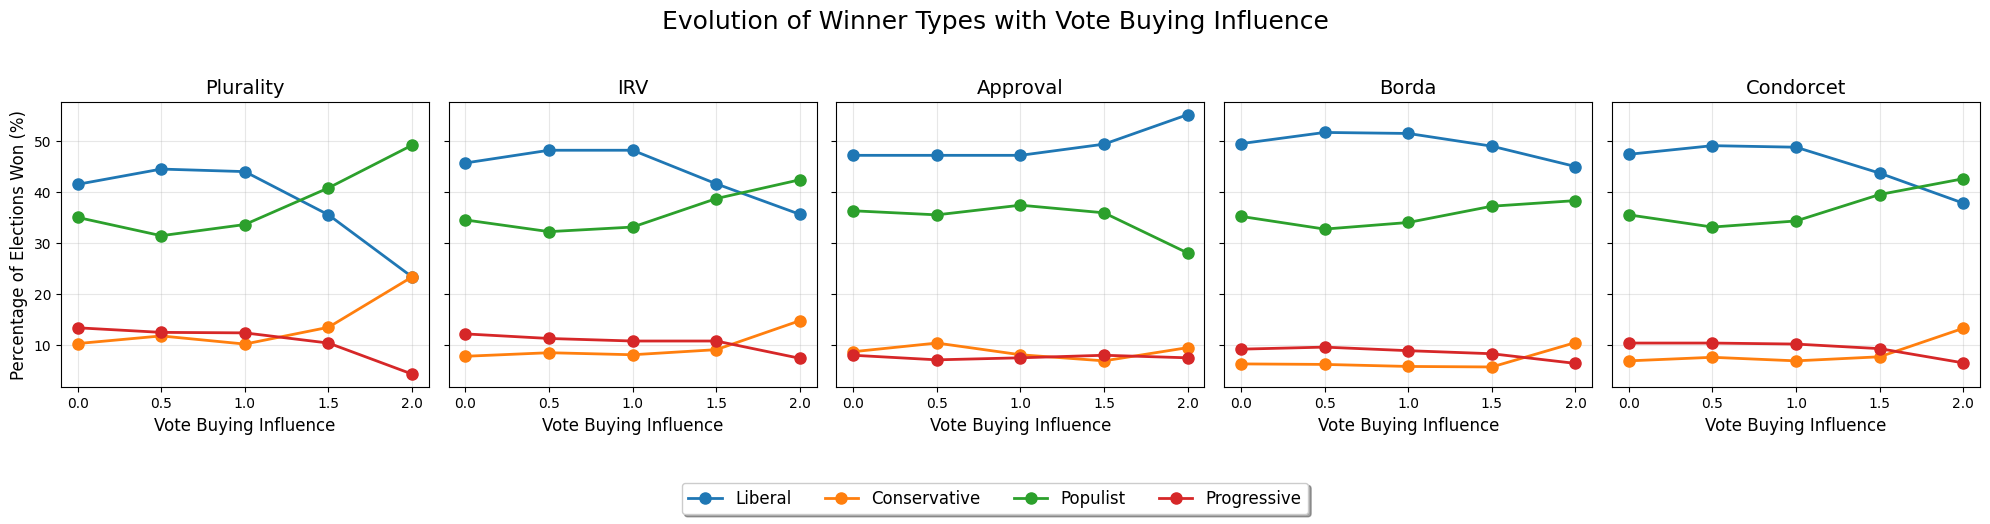

In [118]:
# Create a figure with a grid of subplots for evolution of winner types
fig, axs = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig.suptitle('Evolution of Winner Types with Vote Buying Influence', fontsize=18)

for i, system in enumerate(voting_systems):
    # Create a DataFrame for this voting system's evolution
    system_data = pd.DataFrame(index=influence_levels)
    
    # For each influence level, extract winner type distribution for this system
    for influence in influence_levels:
        subset = sim_df[sim_df['influence'] == influence]
        type_counts = subset[f'{system} Winner Type'].value_counts(normalize=True) * 100
        for winner_type in winner_types:
            if winner_type in type_counts.index:
                system_data.loc[influence, winner_type] = type_counts[winner_type]
            else:
                system_data.loc[influence, winner_type] = 0
    
    # Plot lines for each winner type
    for winner_type in winner_types:
        axs[i].plot(influence_levels, system_data[winner_type], 'o-', 
                    linewidth=2, markersize=8, label=winner_type)
    
    axs[i].set_title(system, fontsize=14)
    axs[i].set_xlabel('Vote Buying Influence', fontsize=12)
    if i == 0:
        axs[i].set_ylabel('Percentage of Elections Won (%)', fontsize=12)
    axs[i].grid(True, alpha=0.3)
    axs[i].set_xticks(influence_levels)

# Create a single legend for the entire figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           fancybox=True, shadow=True, ncol=len(winner_types), fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

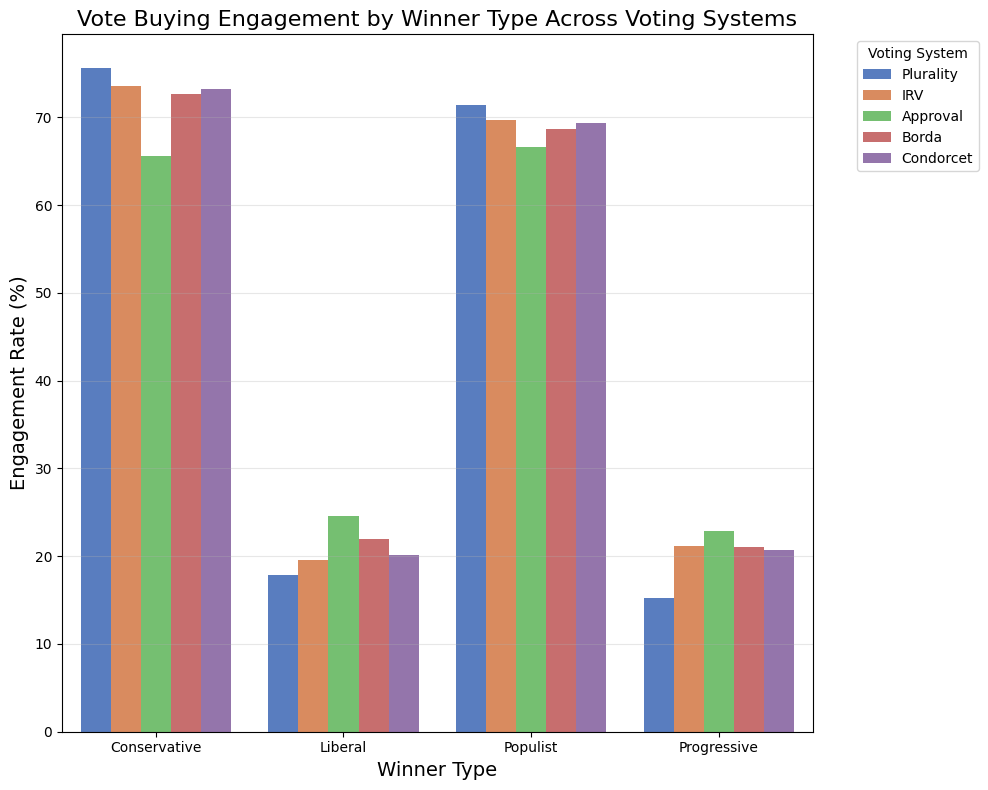

In [ ]:
# Create a bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=winner_vb_long, x='Winner Type', y='Engagement Rate', hue='Voting System', palette='muted')

# Customize the plot
plt.title('Vote Buying Engagement by Winner Type Across Voting Systems', fontsize=16)
plt.xlabel('Winner Type', fontsize=14)
plt.ylabel('Engagement Rate (%)', fontsize=14)
plt.legend(title='Voting System', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()


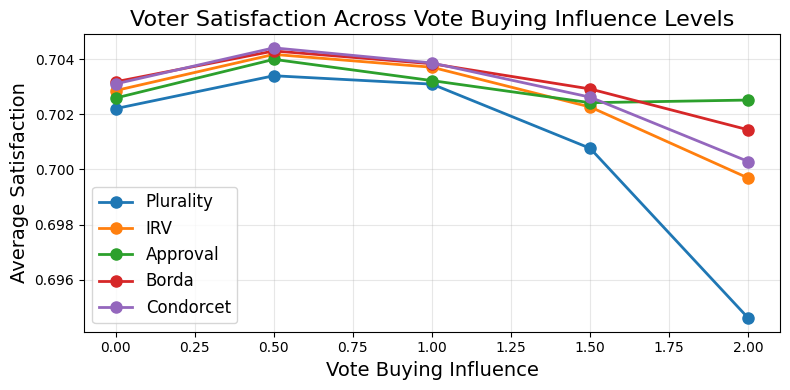

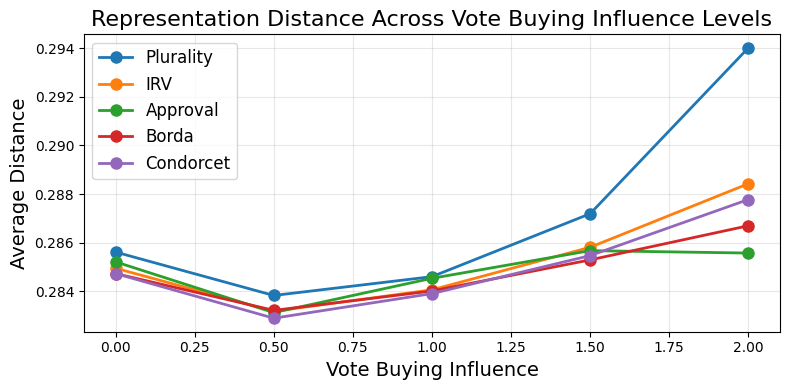

In [49]:
# 4. Plot how satisfaction changes with vote buying influence
plt.figure(figsize=(8, 4))
influence_levels = sorted(sim_df['influence'].unique())
satisfaction_by_influence = {system: [] for system in voting_systems}

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence]
    for system in voting_systems:
        satisfaction_by_influence[system].append(subset[f'{system} Satisfaction'].mean())

# Plot satisfaction trends
for system in voting_systems:
    plt.plot(influence_levels, satisfaction_by_influence[system], 'o-', 
             linewidth=2, markersize=8, label=system)

plt.title('Voter Satisfaction Across Vote Buying Influence Levels', fontsize=16)
plt.xlabel('Vote Buying Influence', fontsize=14)
plt.ylabel('Average Satisfaction', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 5. Plot how distance changes with vote buying influence
plt.figure(figsize=(8, 4))
distance_by_influence = {system: [] for system in voting_systems}

for influence in influence_levels:
    subset = sim_df[sim_df['influence'] == influence]
    for system in voting_systems:
        distance_by_influence[system].append(subset[f'{system} Distance'].mean())

# Plot distance trends
for system in voting_systems:
    plt.plot(influence_levels, distance_by_influence[system], 'o-', 
             linewidth=2, markersize=8, label=system)

plt.title('Representation Distance Across Vote Buying Influence Levels', fontsize=16)
plt.xlabel('Vote Buying Influence', fontsize=14)
plt.ylabel('Average Distance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



<Figure size 1500x1000 with 0 Axes>

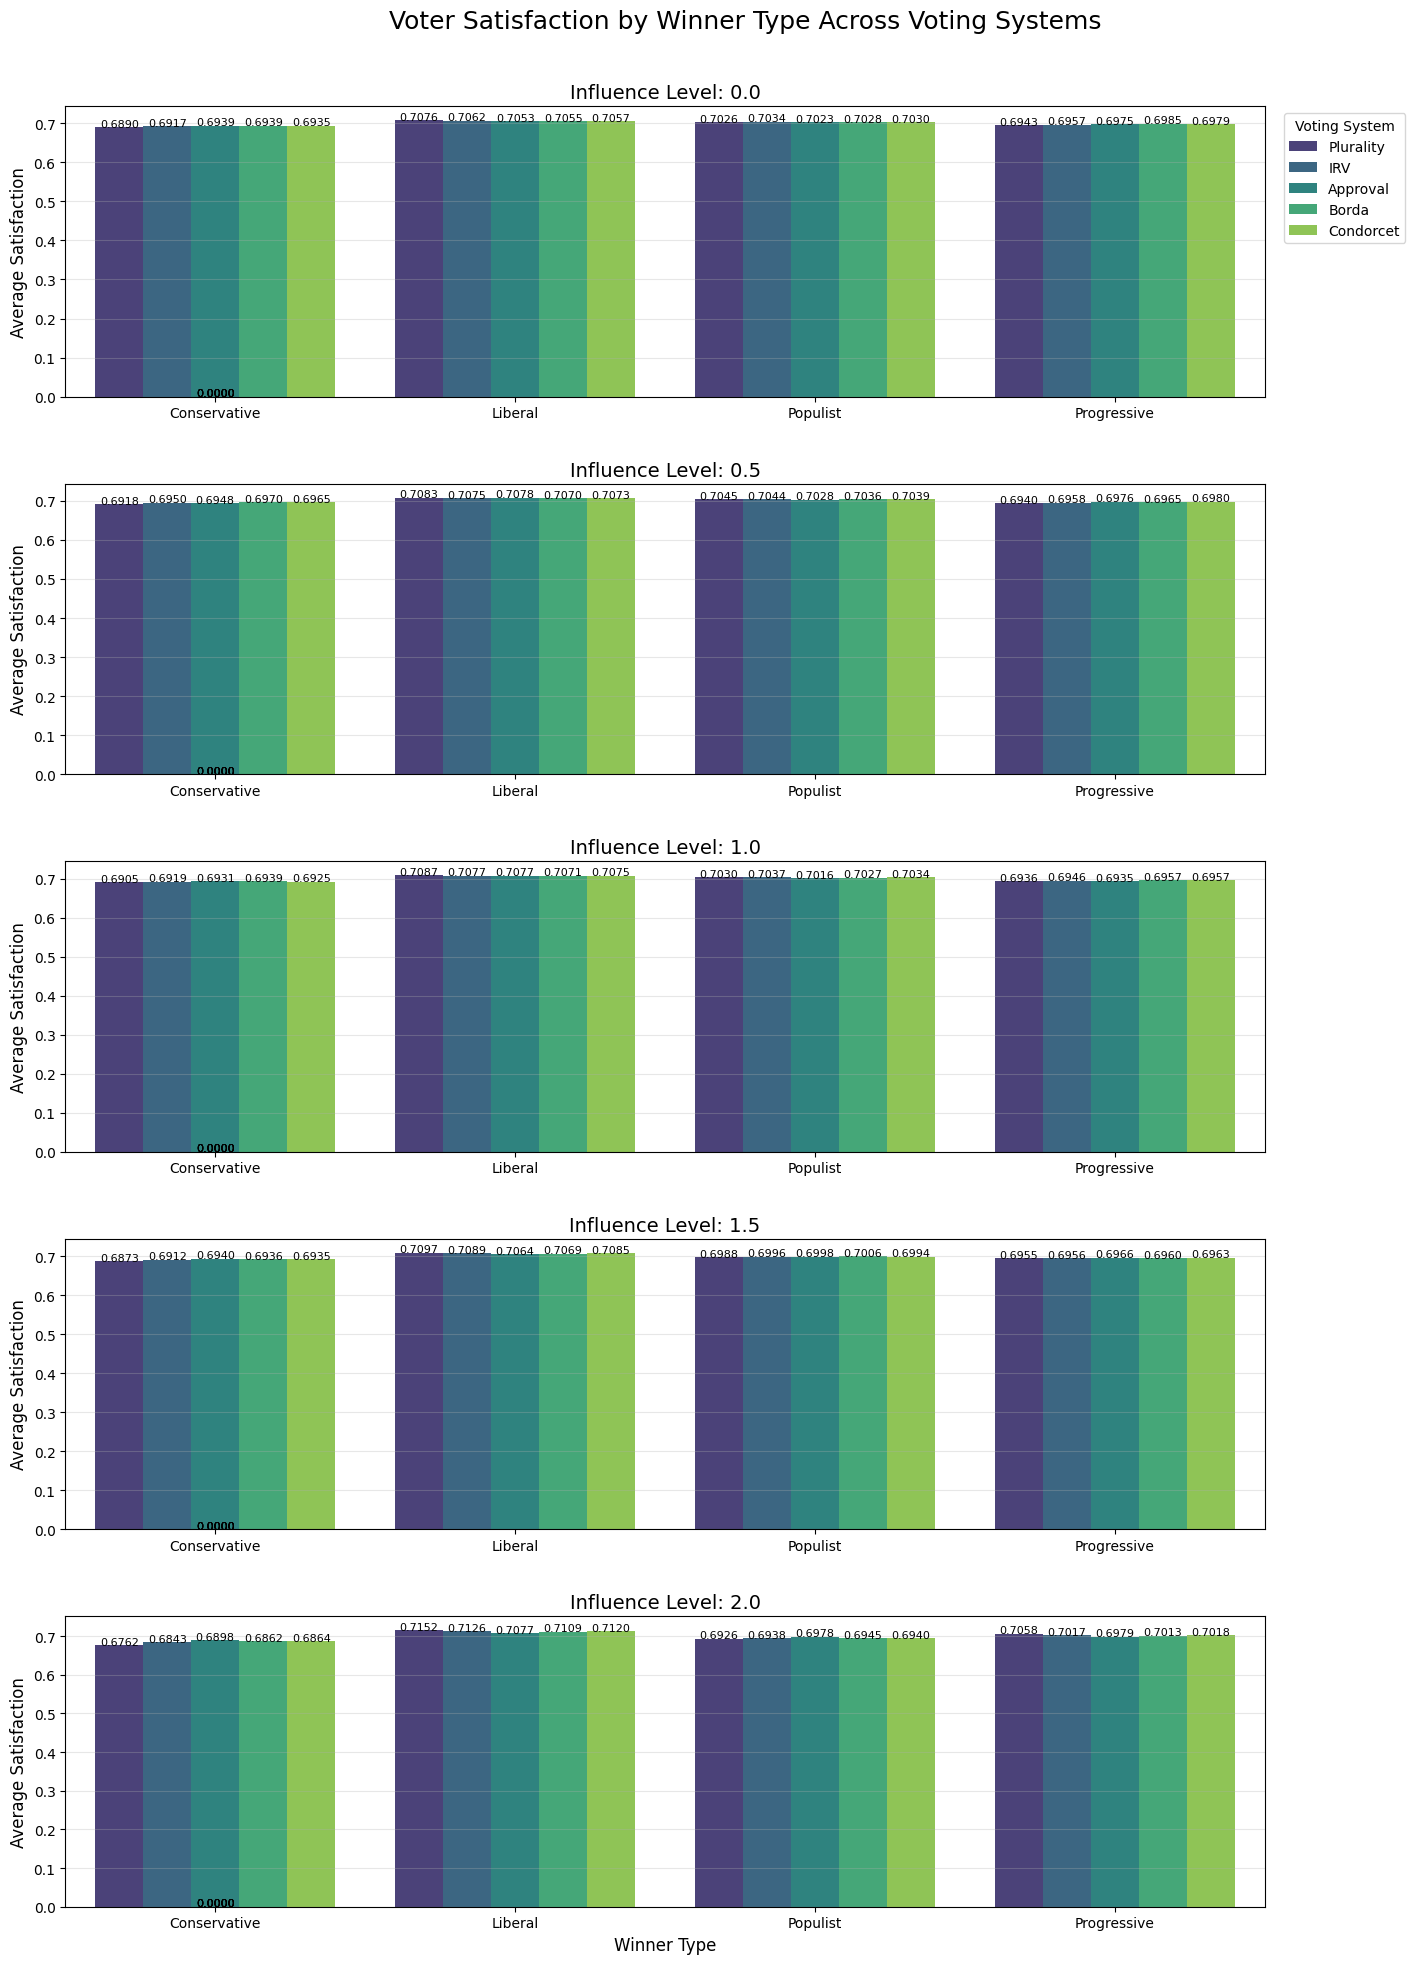

In [122]:
# Create a visualization of voter satisfaction by winner type across all influences

# Set up figure
plt.figure(figsize=(15, 10))

# Process data for all influence levels
satisfaction_by_type = []

for influence in sorted(sim_df['influence'].unique()):
    data_at_influence = sim_df[sim_df['influence'] == influence]
    
    # Go through each voting system
    for system in voting_systems:
        # Group by winner type and calculate average satisfaction
        grouped = data_at_influence.groupby(f'{system} Winner Type')[f'{system} Satisfaction'].mean().reset_index()
        grouped['Voting System'] = system
        grouped['Influence'] = influence
        grouped.rename(columns={f'{system} Winner Type': 'Winner Type', 
                               f'{system} Satisfaction': 'Satisfaction'}, inplace=True)
        satisfaction_by_type.append(grouped)

# Combine all data
satisfaction_df = pd.concat(satisfaction_by_type)

# Create subplot grid - one row per influence level
influence_levels = sorted(sim_df['influence'].unique())
fig, axes = plt.subplots(len(influence_levels), 1, figsize=(15, 4*len(influence_levels)))
fig.suptitle('Voter Satisfaction by Winner Type Across Voting Systems', fontsize=18)

# For each influence level, create a bar chart
for i, influence in enumerate(influence_levels):
    data = satisfaction_df[satisfaction_df['Influence'] == influence]
    
    # Create grouped bar chart
    sns.barplot(x='Winner Type', y='Satisfaction', hue='Voting System', 
                data=data, ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Influence Level: {influence}', fontsize=14)
    axes[i].set_xlabel('Winner Type' if i == len(influence_levels)-1 else '', fontsize=12)
    axes[i].set_ylabel('Average Satisfaction', fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Add value labels to bars
    for p in axes[i].patches:
        axes[i].text(p.get_x() + p.get_width()/2., p.get_height() + 0.001,
                    f'{p.get_height():.4f}', ha='center', fontsize=8)
    
    # Improve legend placement
    if i == 0:
        axes[i].legend(title='Voting System', bbox_to_anchor=(1.01, 1), loc='upper left')
    else:
        axes[i].legend().set_visible(False)

plt.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.subplots_adjust(hspace=0.3)
plt.show()